---
title: "بخش پنجم: ساختارهای داده پایه"
authors:
  - name: دکتر محمود امین طوسی
    affiliations:
      - institution: دانشگاه فردوسی مشهد
        department: گروه علوم کامپیوتر
        country: ایران
    email: m.amintoosi@gmail.com
    github: https://github.com/mamintoosi
    url: https://mamintoosi.github.io/
    roles: [supervision]
  - name: علیرضا زارع بیدکی
    affiliations:
      - institution: دانشگاه فردوسی مشهد
        department: گروه علوم کامپیوتر
    email: alireza.zarebidoki@mail.um.ac.ir
    github: alireza-zarebidoki
    roles: [methodology, writing, editing]
  - name: سجاد باقریون
    affiliations:
      - institution: دانشگاه فردوسی مشهد
        department: گروه علوم کامپیوتر
    email: sajjad.bagheriyoun@mail.um.ac.ir
    github: Goodgirbaay
    roles: [conceptualization, methodology]
  - name: علیرضا سالاری
    affiliations:
      - institution: دانشگاه فردوسی مشهد
        department: گروه علوم کامپیوتر
    email: salari.alireza@mail.um.ac.ir
    github: AlirezaSlriw
    roles: [validation, editing]
---

In [155]:
# ============================================================
# جعبه‌ابزار تصویرسازی (Visualization Toolkit) - فقط اجرا کنید و رد شوید
# ============================================================
try:
    import matplotlib
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
    import matplotlib

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display

plt.rcParams["font.size"] = 11

COLOR_DEFAULT   = "#EEF2FF"
COLOR_CURRENT   = "#FDE68A"
COLOR_FOUND     = "#86EFAC"
COLOR_DISCARDED = "#F3F4F6"
COLOR_SORTED    = "#93C5FD"
COLOR_MIN       = "#FCA5A5"
COLOR_COMPARE_B = "#FBCFE8"


def draw_array(ax, values, colors=None, index_labels=True, title="", note="", box=1.0):
    ax.clear()
    n = len(values)
    colors = colors or [COLOR_DEFAULT] * n
    for i, v in enumerate(values):
        rect = plt.Rectangle((i * box, 0), box, box, facecolor=colors[i],
                              edgecolor="#374151", linewidth=1.6)
        ax.add_patch(rect)
        ax.text(i * box + box / 2, box / 2, str(v), ha="center", va="center",
                 fontsize=14, fontweight="bold", color="#111827")
        if index_labels:
            ax.text(i * box + box / 2, -0.30, str(i), ha="center", va="center",
                     fontsize=10, color="#6B7280")
    ax.set_xlim(-0.4, n * box + 0.4)
    ax.set_ylim(-0.75, box + 0.65)
    ax.axis("off")
    if title:
        ax.text(n * box / 2, box + 0.42, title, ha="center", va="center",
                 fontsize=12, fontweight="bold", color="#111827")
    if note:
        ax.text(n * box / 2, -0.58, note, ha="center", va="center",
                 fontsize=11, color="#1D4ED8")


def run_animation(frame_fn, n_frames, figsize=(8.5, 2.9), interval=1000):
    fig, ax = plt.subplots(figsize=figsize)
    def update(i):
        frame_fn(ax, i)
        return []
    anim = animation.FuncAnimation(fig, update, frames=n_frames,
                                    interval=interval, repeat=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())


def draw_matrix(ax, mat, highlight_cell=None, highlight_row=None, highlight_col=None,
                 title="", box=1.05):
    ax.clear()
    rows = len(mat)
    cols = len(mat[0])
    for i in range(rows):
        for j in range(cols):
            color = COLOR_DEFAULT
            if highlight_row is not None and i == highlight_row:
                color = "#DBEAFE"
            if highlight_col is not None and j == highlight_col:
                color = "#FDE68A" if color == COLOR_DEFAULT else "#FDBA74"
            if highlight_cell is not None and (i, j) == highlight_cell:
                color = COLOR_FOUND
            x, y = j * box, (rows - 1 - i) * box
            rect = plt.Rectangle((x, y), box, box, facecolor=color,
                                  edgecolor="#374151", linewidth=1.4)
            ax.add_patch(rect)
            ax.text(x + box / 2, y + box / 2, str(mat[i][j]), ha="center", va="center",
                     fontsize=13, fontweight="bold")
    for j in range(cols):
        ax.text(j * box + box / 2, rows * box + 0.25, f"col {j}",
                 ha="center", va="center", fontsize=9, color="#6B7280")
    for i in range(rows):
        ax.text(-0.55, (rows - 1 - i) * box + box / 2, f"row {i}",
                 ha="center", va="center", fontsize=9, color="#6B7280")
    ax.set_xlim(-1.1, cols * box + 0.4)
    ax.set_ylim(-0.4, rows * box + 0.7)
    ax.axis("off")
    if title:
        ax.text((cols * box) / 2, rows * box + 0.62, title, ha="center", va="center",
                 fontsize=12, fontweight="bold")


def draw_string(ax, s, title="", box=0.9):
    ax.clear()
    chars = list(s) + ["\\0"]
    n = len(chars)
    for i, ch in enumerate(chars):
        color = "#FCA5A5" if ch == "\\0" else COLOR_DEFAULT
        rect = plt.Rectangle((i * box, 0), box, box, facecolor=color,
                              edgecolor="#374151", linewidth=1.6)
        ax.add_patch(rect)
        ax.text(i * box + box / 2, box / 2, ch, ha="center", va="center",
                 fontsize=14, fontweight="bold")
        ax.text(i * box + box / 2, -0.30, str(i), ha="center", va="center",
                 fontsize=10, color="#6B7280")
    ax.set_xlim(-0.4, n * box + 0.4)
    ax.set_ylim(-0.6, box + 0.55)
    ax.axis("off")
    if title:
        ax.text(n * box / 2, box + 0.35, title, ha="center", va="center",
                 fontsize=12, fontweight="bold")

print("Visualization toolkit ready.")


# ============================================================
# پخش‌کننده‌ی تعاملی الگوریتم‌ها (Algorithm Player)
# ============================================================
import json, re, hashlib, html as _html, uuid
from IPython.display import HTML

_AP_CSS = r''':host{all:initial;display:block;max-width:900px;margin:8px auto 18px}
*{box-sizing:border-box}
.card{--card:#fff;--panel:#f6f8fb;--bd:#e2e7ef;--tx:#182230;--mut:#6a7688;--acc:#4f46e5;--acc-soft:rgba(79,70,229,.10);
--stage:#fbfcfe;--dot:#dfe4ee;--code-bg:#fafbfd;--hl:rgba(79,70,229,.12);--ln:#a3adbd;--sh:0 1px 2px rgba(16,24,40,.06),0 14px 30px -18px rgba(16,24,40,.28);
--sb:rgba(100,116,139,.45);--sb-h:rgba(79,70,229,.65);color-scheme:light;--i-bg:#eef2ff;--i-bd:#98a6cf;--i-tx:#182230;--out-bg:#f6f8fa;--out-fg:#116329;--out-bd:#d0d7de;
--cur-bg:#fde68a;--cur-bd:#d9a20a;--cur-tx:#4a3200;--cur-gl:rgba(250,204,21,.38);
--cmp-bg:#fbcfe8;--cmp-bd:#e07bb0;--cmp-tx:#4a1230;--cmp-gl:rgba(236,72,153,.28);
--ok-bg:#bbf7d0;--ok-bd:#2fa863;--ok-tx:#0a3d1f;--ok-gl:rgba(34,197,94,.30);
--sorted-bg:#bfdbfe;--sorted-bd:#4f8ad9;--sorted-tx:#0f2a52;
--min-bg:#fecaca;--min-bd:#e05a5a;--min-tx:#501414;--min-gl:rgba(239,68,68,.28);
--key-bg:#ddd6fe;--key-bd:#7c5be0;--key-tx:#26155a;--key-gl:rgba(139,92,246,.30);
--dim-bg:#f0f2f6;--dim-bd:#d3d9e3;--dim-tx:#9aa4b3;
--vis-bg:#e0f2fe;--vis-bd:#7db9de;--vis-tx:#123a55;
--row-bg:#dbeafe;--row-bd:#8fb4ea;--col-bg:#fef3c7;--col-bd:#e6c66a;--rc-bg:#fdba74;--rc-bd:#e08a2c;
--k-kw:#cf222e;--k-ty:#0550ae;--k-num:#0550ae;--k-str:#0a3069;--k-cm:#6e7781;--k-fn:#8250df;--k-pp:#953800;--k-tx:#1f2328;
position:relative;font:14px/1.5 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;color:var(--tx);background:var(--card);
border:1px solid var(--bd);border-radius:16px;box-shadow:var(--sh);overflow:hidden;direction:ltr;text-align:left;outline:none;transition:background .3s,border-color .3s,color .3s}
.card[data-theme=dark]{--card:#0f1522;--panel:#141b2b;--bd:#242e45;--tx:#e5eaf4;--mut:#8b97ae;--acc:#8b93ff;--acc-soft:rgba(139,147,255,.14);
--stage:#0c111d;--dot:#1a2236;--code-bg:#0c111c;--hl:rgba(139,147,255,.16);--ln:#4a5670;--sh:0 1px 2px rgba(0,0,0,.4),0 18px 36px -18px rgba(0,0,0,.7);
--sb:rgba(148,163,184,.32);--sb-h:rgba(139,147,255,.7);color-scheme:dark;--i-bg:#1a2238;--i-bd:#3c4b74;--i-tx:#e5eaf4;--out-bg:#0a0f1a;--out-fg:#7ee787;--out-bd:#1d2740;
--cur-bg:#6b4c06;--cur-bd:#f0b429;--cur-tx:#ffe9a8;--cur-gl:rgba(240,180,41,.30);
--cmp-bg:#5a1d42;--cmp-bd:#e879b9;--cmp-tx:#ffd6ec;--cmp-gl:rgba(232,121,185,.28);
--ok-bg:#14532d;--ok-bd:#4ade80;--ok-tx:#d9fbe4;--ok-gl:rgba(74,222,128,.26);
--sorted-bg:#1e3a6e;--sorted-bd:#60a5fa;--sorted-tx:#dbeafe;
--min-bg:#6b1d1d;--min-bd:#f87171;--min-tx:#fee2e2;--min-gl:rgba(248,113,113,.28);
--key-bg:#43307a;--key-bd:#a78bfa;--key-tx:#ede9fe;--key-gl:rgba(167,139,250,.30);
--dim-bg:#121826;--dim-bd:#252f45;--dim-tx:#566178;
--vis-bg:#10324a;--vis-bd:#38a9d8;--vis-tx:#d3f0ff;
--row-bg:#16305a;--row-bd:#3d68a8;--col-bg:#4a3a0c;--col-bd:#a9852a;--rc-bg:#6b430f;--rc-bd:#d18a2e;
--k-kw:#ff7b72;--k-ty:#79c0ff;--k-num:#79c0ff;--k-str:#a5d6ff;--k-cm:#8b949e;--k-fn:#d2a8ff;--k-pp:#ffa657;--k-tx:#e6edf3}
.card:focus-visible{box-shadow:0 0 0 3px var(--acc-soft),var(--sh);border-color:var(--acc)}
.hr{display:flex;align-items:center;gap:10px;flex:none}
.btn.fsb{width:30px;height:30px;border-radius:9px}
.btn.fsb svg{width:15px;height:15px}
:host(.ap-full){max-width:none;margin:0;width:100%;height:100%;background:var(--fs-bg,#fff)}
:host(.ap-pseudo){position:fixed;inset:0;z-index:2147483000;width:100vw;height:100vh}
.card.full{height:100%;border-radius:0;border:0;display:flex;flex-direction:column}
.card.full .stage{flex:none;display:flex;align-items:center;justify-content:center}
.card.full .split{flex:1;min-height:0}
.card.full .codep{display:flex;flex-direction:column;min-height:0}
.card.full .cwrap{flex:1;min-height:0}
.card.full .cbody{max-height:none;height:100%}
.card.full .info{overflow:auto;min-height:0}
.hd{display:flex;align-items:center;justify-content:space-between;gap:12px;padding:12px 16px;border-bottom:1px solid var(--bd);
background:linear-gradient(180deg,var(--panel),var(--card))}
.ttl{display:flex;align-items:center;gap:10px;min-width:0}
.dot{flex:none;width:10px;height:10px;border-radius:50%;background:var(--acc);box-shadow:0 0 0 4px var(--acc-soft)}
.tt{font-weight:700;font-size:15px;letter-spacing:.01em;overflow:hidden;text-overflow:ellipsis;white-space:nowrap}
.bdg{flex:none;font:600 10.5px/1 'JetBrains Mono',ui-monospace,Consolas,monospace;letter-spacing:.08em;color:var(--acc);
background:var(--acc-soft);padding:6px 10px;border-radius:999px;text-transform:uppercase}
.stage{position:relative;overflow:hidden;background-color:var(--stage);background-image:radial-gradient(var(--dot) 1px,transparent 1.3px);background-size:18px 18px;border-bottom:1px solid var(--bd)}
.it{position:absolute;left:0;top:0;display:flex;align-items:center;justify-content:center;border:2px solid var(--i-bd);background:var(--i-bg);color:var(--i-tx);
border-radius:12px;font-family:'JetBrains Mono',ui-monospace,Consolas,monospace;font-weight:700;line-height:1;z-index:2;
box-shadow:0 1px 0 rgba(0,0,0,.05),0 8px 14px -10px rgba(15,23,42,.45);transition:background-color .28s,border-color .28s,color .28s,box-shadow .28s;will-change:transform}
.it[data-c=cur]{background:var(--cur-bg);border-color:var(--cur-bd);color:var(--cur-tx);box-shadow:0 0 0 5px var(--cur-gl);z-index:4}
.it[data-c=cmp]{background:var(--cmp-bg);border-color:var(--cmp-bd);color:var(--cmp-tx);box-shadow:0 0 0 5px var(--cmp-gl);z-index:4}
.it[data-c=ok]{background:var(--ok-bg);border-color:var(--ok-bd);color:var(--ok-tx);box-shadow:0 0 0 5px var(--ok-gl);z-index:4}
.it[data-c=min]{background:var(--min-bg);border-color:var(--min-bd);color:var(--min-tx);box-shadow:0 0 0 5px var(--min-gl);z-index:3}
.it[data-c=key]{background:var(--key-bg);border-color:var(--key-bd);color:var(--key-tx);box-shadow:0 0 0 5px var(--key-gl),0 14px 18px -10px rgba(76,29,149,.5);z-index:5}
.it[data-c=sorted]{background:var(--sorted-bg);border-color:var(--sorted-bd);color:var(--sorted-tx)}
.it[data-c=vis]{background:var(--vis-bg);border-color:var(--vis-bd);color:var(--vis-tx)}
.it[data-c=dim]{background:var(--dim-bg);border-color:var(--dim-bd);color:var(--dim-tx);box-shadow:none}
.it[data-c=row]{background:var(--row-bg);border-color:var(--row-bd)}
.it[data-c=col]{background:var(--col-bg);border-color:var(--col-bd);color:var(--cur-tx)}
.card[data-theme=dark] .it[data-c=col]{color:#ffeaa7}
.it[data-c=rc]{background:var(--rc-bg);border-color:var(--rc-bd);color:#3a1d00}
.card[data-theme=dark] .it[data-c=rc]{color:#ffe1bd}
.it.nul{border-style:dashed}
.ix{position:absolute;left:0;top:0;text-align:center;font:500 12px/16px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--mut);z-index:1}
.hdr{position:absolute;left:0;top:0;display:flex;align-items:center;justify-content:center;font:600 11.5px/1 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--mut);
border-radius:8px;transition:background-color .28s,color .28s;z-index:1}
.hdr.on{background:var(--acc-soft);color:var(--acc)}
.win{position:absolute;left:0;top:0;border:2px dashed var(--acc);border-radius:16px;background:var(--acc-soft);opacity:0;z-index:1;
transition:transform .5s cubic-bezier(.4,0,.2,1),width .5s cubic-bezier(.4,0,.2,1),opacity .3s}
.pt{position:absolute;left:0;top:0;width:0;height:0;z-index:6;pointer-events:none;transition:transform .5s cubic-bezier(.4,0,.2,1),opacity .28s;--pc:#6366f1}
.pt.off{opacity:0}
.pin{position:absolute;left:0;top:0;transform:translateX(-50%);display:flex;flex-direction:column;align-items:center}
.ar{width:0;height:0;border-left:6px solid transparent;border-right:6px solid transparent;border-bottom:8px solid var(--pc)}
.lb{margin-top:1px;padding:0 9px;border-radius:999px;background:var(--pc);color:#fff;font:700 12px/20px 'JetBrains Mono',ui-monospace,Consolas,monospace;white-space:nowrap;box-shadow:0 4px 10px -4px var(--pc)}
.pt[data-t=i],.pt[data-t=count]{--pc:#6366f1}.pt[data-t=j]{--pc:#0ea5a4}.pt[data-t=low]{--pc:#16a34a}.pt[data-t=mid]{--pc:#d98a06}
.pt[data-t=high],.pt[data-t=min]{--pc:#e5484d}.pt[data-t=key]{--pc:#8b5cf6}
.card[data-theme=dark] .pt[data-t=i],.card[data-theme=dark] .pt[data-t=count]{--pc:#7c83ff}.card[data-theme=dark] .pt[data-t=j]{--pc:#2dd4bf}
.card[data-theme=dark] .pt[data-t=low]{--pc:#22c55e}.card[data-theme=dark] .pt[data-t=mid]{--pc:#f59e0b}
.card[data-theme=dark] .pt[data-t=high],.card[data-theme=dark] .pt[data-t=min]{--pc:#f87171}.card[data-theme=dark] .pt[data-t=key]{--pc:#a78bfa}
.lg{display:flex;flex-wrap:wrap;gap:6px 16px;padding:9px 16px;border-bottom:1px solid var(--bd);background:var(--card);direction:rtl;font:500 12.5px/1.2 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;color:var(--mut)}
.lg span{display:inline-flex;align-items:center;gap:6px}
.lg i{width:12px;height:12px;border-radius:4px;border:1.5px solid var(--i-bd);background:var(--i-bg)}
.split{display:grid;grid-template-columns:minmax(0,1.3fr) minmax(0,1fr)}
.card.narrow .split{grid-template-columns:minmax(0,1fr)}
.codep{min-width:0;background:var(--code-bg);border-right:1px solid var(--bd)}
.card.narrow .codep{border-right:0;border-bottom:1px solid var(--bd)}
.card.narrow .cbody{font-size:10.5px}
.chd{display:flex;align-items:center;gap:8px;padding:9px 14px;border-bottom:1px solid var(--bd);font:700 10.5px/1 'JetBrains Mono',ui-monospace,Consolas,monospace;letter-spacing:.1em;color:var(--mut)}
.chd s{width:8px;height:8px;border-radius:50%;background:#ff5f57;text-decoration:none;box-shadow:14px 0 0 #febc2e,28px 0 0 #28c840;margin-right:32px}
.cwrap{position:relative}
.sbt{position:absolute;top:0;right:3px;width:5px;height:100%;pointer-events:none;display:none}
.sbt i{display:block;width:5px;border-radius:99px;background:var(--sb);opacity:.9}
.cbody{position:relative;padding:8px 0 10px;overflow:auto;max-height:300px;overscroll-behavior:contain;font:500 13px/22px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--k-tx)}
.lines{position:relative;min-width:max-content}
.hl{position:absolute;left:0;right:0;top:0;height:22px;background:var(--hl);border-left:3px solid var(--acc);transition:transform .38s cubic-bezier(.4,0,.2,1),height .38s cubic-bezier(.4,0,.2,1);z-index:0}
.ln{position:relative;display:flex;height:22px;white-space:pre;z-index:1}
.no{flex:none;width:40px;padding-right:12px;text-align:right;color:var(--ln);user-select:none;transition:color .2s}
.tx{flex:1;padding-right:16px}
.ln.on .no{color:var(--acc);font-weight:700}
.k{color:var(--k-kw)}.t{color:var(--k-ty)}.n{color:var(--k-num)}.s{color:var(--k-str)}.c{color:var(--k-cm);font-style:italic}.f{color:var(--k-fn)}.p{color:var(--k-pp)}
.info{min-width:0;display:flex;flex-direction:column;gap:14px;padding:14px 16px;background:var(--card);direction:rtl;text-align:right}
.bt{margin-bottom:8px;font:700 12px/1 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;color:var(--mut)}
.vars{display:flex;flex-wrap:wrap;gap:8px;direction:rtl;min-height:32px}
.chip{direction:ltr;display:flex;align-items:baseline;gap:7px;padding:5px 11px;border-radius:10px;background:var(--panel);border:1px solid var(--bd);font:600 13px/1.25 'JetBrains Mono',ui-monospace,Consolas,monospace}
.chip b{color:var(--mut);font-weight:600}.chip span{color:var(--tx);font-weight:700;min-width:1ch}
.chip.na{opacity:.45}.chip.chg{animation:pop .7s ease-out}
@keyframes pop{0%{background:var(--acc-soft);border-color:var(--acc);transform:scale(1.07)}100%{transform:scale(1)}}
.note{direction:rtl;text-align:right;min-height:72px;padding:11px 13px;border-radius:12px;background:var(--panel);border:1px solid var(--bd);font:500 13.5px/1.65 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif}
.note.in{animation:rise .35s ease-out}
@keyframes rise{from{opacity:0;transform:translateY(5px)}to{opacity:1;transform:none}}
.note code{font:600 12.5px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--acc);background:var(--acc-soft);padding:1px 6px;border-radius:6px}
.out{direction:ltr;text-align:left}.out .bt{direction:rtl;text-align:right}.out pre{margin:0;min-height:58px;max-height:150px;overflow:hidden;white-space:pre-wrap;padding:10px 12px;border-radius:12px;background:var(--out-bg);color:var(--out-fg);border:1px solid var(--out-bd);font:500 12.5px/1.6 'JetBrains Mono',ui-monospace,Consolas,monospace;white-space:pre-wrap}
.out pre::after{content:"\2588";margin-left:2px;color:var(--out-fg);animation:blink 1s steps(1) infinite}
@keyframes blink{50%{opacity:0}}
.ctl{display:flex;align-items:center;gap:10px;flex-wrap:wrap;padding:11px 14px;border-top:1px solid var(--bd);background:var(--panel)}
.bts{display:flex;align-items:center;gap:6px}
.btn{display:grid;place-items:center;width:34px;height:34px;padding:0;border-radius:10px;border:1px solid var(--bd);background:var(--card);color:var(--tx);cursor:pointer;transition:background .15s,border-color .15s,color .15s,transform .1s}
.btn:hover{background:var(--acc-soft);border-color:var(--acc);color:var(--acc)}
.btn:active{transform:scale(.94)}.btn:disabled{opacity:.35;cursor:default}
.btn:focus-visible{outline:2px solid var(--acc);outline-offset:2px}
.btn svg{width:16px;height:16px;fill:currentColor}
.btn.play{width:42px;height:42px;border-radius:50%;background:var(--acc);border-color:var(--acc);color:#fff;box-shadow:0 8px 16px -8px var(--acc)}
.btn.play:hover{filter:brightness(1.08);color:#fff}
.btn.play svg{width:18px;height:18px}
.btn.on{background:var(--acc-soft);border-color:var(--acc);color:var(--acc)}
.sl{flex:1;min-width:120px;height:22px;margin:0;background:transparent;-webkit-appearance:none;appearance:none;cursor:pointer;--p:0%}
.sl::-webkit-slider-runnable-track{height:6px;border-radius:99px;background:linear-gradient(to right,var(--acc) var(--p),var(--bd) var(--p))}
.sl::-moz-range-track{height:6px;border-radius:99px;background:var(--bd)}
.sl::-moz-range-progress{height:6px;border-radius:99px;background:var(--acc)}
.sl::-webkit-slider-thumb{-webkit-appearance:none;width:16px;height:16px;margin-top:-5px;border-radius:50%;background:#fff;border:3px solid var(--acc);box-shadow:0 2px 6px rgba(0,0,0,.25)}
.sl::-moz-range-thumb{width:12px;height:12px;border-radius:50%;background:#fff;border:3px solid var(--acc)}
.sl:focus-visible{outline:2px solid var(--acc);outline-offset:3px;border-radius:6px}
.cnt{flex:none;min-width:58px;text-align:center;font:700 12px/1 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--mut)}
.spd{flex:none;height:34px;padding:0 8px;border-radius:10px;border:1px solid var(--bd);background:var(--card);color:var(--tx);font:600 12px 'JetBrains Mono',ui-monospace,Consolas,monospace;cursor:pointer}
.spd:focus-visible{outline:2px solid var(--acc);outline-offset:2px}
.card.narrow .sl{order:5;flex-basis:100%}
@media (prefers-reduced-motion:reduce){.it,.pt,.win,.hl{transition:none!important}.note.in,.chip.chg{animation:none}}

.world{position:relative}.stage{overflow:hidden}
.nt,.nt *{transition:none!important;animation:none!important}
.lg i[data-c=cur]{background:var(--cur-bg);border-color:var(--cur-bd)}.lg i[data-c=cmp]{background:var(--cmp-bg);border-color:var(--cmp-bd)}
.lg i[data-c=ok]{background:var(--ok-bg);border-color:var(--ok-bd)}.lg i[data-c=min]{background:var(--min-bg);border-color:var(--min-bd)}
.lg i[data-c=key]{background:var(--key-bg);border-color:var(--key-bd)}.lg i[data-c=sorted]{background:var(--sorted-bg);border-color:var(--sorted-bd)}
.lg i[data-c=vis]{background:var(--vis-bg);border-color:var(--vis-bd)}.lg i[data-c=dim]{background:var(--dim-bg);border-color:var(--dim-bd)}
.mc{position:absolute;left:0;top:0;display:flex;align-items:center;justify-content:center;border:1.5px solid var(--i-bd);background:var(--i-bg);color:var(--i-tx);border-radius:8px;
font:700 12px 'JetBrains Mono',ui-monospace,Consolas,monospace;transition:background-color .25s,border-color .25s,color .25s,box-shadow .25s}
.mc[data-c=cur]{background:var(--cur-bg);border-color:var(--cur-bd);color:var(--cur-tx);box-shadow:0 0 0 4px var(--cur-gl)}
.mc[data-c=vis]{background:var(--vis-bg);border-color:var(--vis-bd);color:var(--vis-tx)}
.mlab{position:absolute;left:0;top:0;font:600 12px/1 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;color:var(--mut);direction:rtl;white-space:nowrap}
.mlab code{font:600 11.5px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--acc)}
.mx{position:absolute;left:0;top:0;text-align:center;font:500 10.5px/14px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--mut)}
.corner{position:absolute;left:0;top:0;font:600 11px/1 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--mut);opacity:.8}

*{scrollbar-width:none;-ms-overflow-style:none}
*::-webkit-scrollbar{display:none;width:0;height:0}

.sub{position:absolute;left:0;top:0;text-align:center;font:600 11.5px/16px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--k-fn);z-index:1;white-space:nowrap;transition:color .25s,transform .25s}
.sub.on{color:var(--acc);font-weight:700}
.it[data-c=hid]{opacity:.18;box-shadow:none;border-style:dashed;background:transparent}
.hint{margin-inline-start:auto;font:500 12px 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;color:var(--mut);direction:rtl}
.cap{padding:13px 18px;border-top:1px solid var(--bd);direction:rtl;text-align:right;font:500 13.5px/1.95 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;background:var(--card)}
.cap code{font:600 12.5px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--acc);background:var(--acc-soft);padding:1px 6px;border-radius:6px;direction:ltr;unicode-bidi:isolate}

.chartw{background-color:var(--stage);background-image:radial-gradient(var(--dot) 1px,transparent 1.3px);background-size:18px 18px;padding:4px 0 0}
.chartw svg{display:block;max-width:100%;height:auto}
.gl{stroke:var(--bd);stroke-width:1;stroke-dasharray:3 5}
.ax{stroke:var(--mut);stroke-width:1.4}
.tk{fill:var(--mut);font:500 11.5px 'JetBrains Mono',ui-monospace,Consolas,monospace}
.axl{fill:var(--mut);font:600 12px 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif}
.cl-area{fill:url(#gf);opacity:0;transition:opacity 1s ease .9s}
.cl-line{fill:none;stroke:var(--acc);stroke-width:3.2;stroke-linecap:round;stroke-linejoin:round;stroke-dasharray:var(--len);stroke-dashoffset:var(--len);transition:stroke-dashoffset 1.5s cubic-bezier(.4,0,.2,1)}
.cl-pt{fill:var(--card);stroke:var(--acc);stroke-width:3;opacity:0;transform-box:fill-box;transform-origin:center;transform:scale(.3)}
.cl-lb{fill:var(--tx);font:700 12px 'JetBrains Mono',ui-monospace,Consolas,monospace;opacity:0}
.run .cl-area{opacity:1}
.run .cl-line{stroke-dashoffset:0}
.run .cl-pt{animation:ptin .42s cubic-bezier(.3,1.4,.5,1) forwards;animation-delay:calc(var(--i)*.13s + .15s)}
.run .cl-lb{animation:lbin .4s ease-out forwards;animation-delay:calc(var(--i)*.13s + .25s)}
@keyframes ptin{from{opacity:0;transform:scale(.3)}to{opacity:1;transform:scale(1)}}
@keyframes lbin{from{opacity:0;transform:translateY(5px)}to{opacity:1;transform:none}}

.sum{display:flex;flex-direction:column;direction:rtl;background:var(--card)}
.srow{display:grid;grid-template-columns:repeat(auto-fit,minmax(260px,1fr));gap:14px 22px;align-items:center;padding:16px 18px;border-bottom:1px solid var(--bd)}
.sname b{display:block;font:700 15px/1.4 'JetBrains Mono',ui-monospace,Consolas,monospace;direction:ltr;text-align:right}
.sname span{display:block;font:500 11.5px/1.5 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--mut);direction:ltr;text-align:right}
.sarr{display:flex;gap:6px;direction:ltr}
.sbx{flex:1 1 0;min-width:0;max-width:58px;aspect-ratio:1;display:grid;place-items:center;border-radius:11px;border:2px solid var(--sorted-bd);background:var(--sorted-bg);color:var(--sorted-tx);font:700 15px 'JetBrains Mono',ui-monospace,Consolas,monospace;opacity:0;transform:scale(.4)}
.run .sbx{animation:ptin .45s cubic-bezier(.3,1.4,.5,1) forwards;animation-delay:calc(var(--i)*80ms + .1s)}
.smet{display:flex;flex-direction:column;gap:9px}
.m{display:grid;grid-template-columns:4.8rem minmax(24px,1fr) auto auto;gap:8px;align-items:center;font:600 12.5px 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;color:var(--mut)}
.mt{height:10px;border-radius:99px;background:var(--bd);overflow:hidden;direction:ltr}
.mt i{display:block;height:100%;width:0;border-radius:inherit;transition:width .9s cubic-bezier(.4,0,.2,1) .45s}
.run .mt i{width:var(--w)}
.m[data-k="0"] .mt i{background:var(--cmp-bd)}.m[data-k="1"] .mt i{background:var(--ok-bd)}
.m b{font:700 14px 'JetBrains Mono',ui-monospace,Consolas,monospace;color:var(--tx);min-width:2ch;direction:ltr;text-align:left}
.m em{font-style:normal;font:600 11px 'Vazirmatn',system-ui,-apple-system,'Segoe UI',Roboto,sans-serif;color:var(--mut);background:var(--panel);border:1px solid var(--bd);padding:1px 7px;border-radius:99px;white-space:nowrap;font-size:10.5px}

.nt.run .cl-pt,.nt.run .cl-lb,.nt.run .sbx{opacity:1;transform:none}
.nt.run .cl-line{stroke-dashoffset:0;transition:none}
.nt.run .cl-area{opacity:1}
.nt.run .mt i{width:var(--w)}

.lg i[data-c=hid]{background:transparent;border-style:dashed;opacity:.6}
'''
_AP_JS = r'''(function(){
if(window.__AP&&window.__AP.v==="__VER__")return;
var CSS=__CSS__;
var IC={first:'M18.41 16.59 13.82 12l4.59-4.59L17 6l-6 6 6 6zM6 6h2v12H6z',prev:'M15.41 7.41 14 6l-6 6 6 6 1.41-1.41L10.83 12z',next:'M10 6 8.59 7.41 13.17 12l-4.58 4.59L10 18l6-6z',last:'M5.59 7.41 10.18 12l-4.59 4.59L7 18l6-6-6-6zM16 6h2v12h-2z',play:'M8 5v14l11-7z',pause:'M6 19h4V5H6v14zm8-14v14h4V5h-4z',replay:'M12 5V1L7 6l5 5V7c3.31 0 6 2.69 6 6s-2.69 6-6 6-6-2.69-6-6H4c0 4.42 3.58 8 8 8s8-3.58 8-8-3.58-8-8-8z',fs:'M7 14H5v5h5v-2H7v-3zm-2-4h2V7h3V5H5v5zm12 7h-3v2h5v-5h-2v3zM14 5v2h3v3h2V5h-5z',fsx:'M5 16h3v3h2v-5H5v2zm3-8H5v2h5V5H8v3zm6 11h2v-3h3v-2h-5v5zm2-11V5h-2v5h5V8h-3z',loop:'M7 7h10v3l4-4-4-4v3H5v6h2V7zm10 10H7v-3l-4 4 4 4v-3h12v-6h-2v4z'};
function svg(p){return '<svg viewBox="0 0 24 24" aria-hidden="true"><path d="'+p+'"/></svg>'}
function esc(s){return String(s).replace(/[&<>"]/g,function(c){return {'&':'&amp;','<':'&lt;','>':'&gt;','"':'&quot;'}[c]})}
function isDark(){
  var d=document.documentElement,b=document.body||d;
  if(d.classList.contains('dark'))return true;
  if(d.classList.contains('light'))return false;
  var th=(d.getAttribute('data-theme')||'')+' '+(b.getAttribute&&b.getAttribute('data-vscode-theme-kind')||'');
  if(/dark/i.test(th))return true; if(/light/i.test(th))return false;
  var bc=b.className||'';
  if(/vscode-high-contrast-light|vscode-light/.test(bc))return false;
  if(/vscode-dark|vscode-high-contrast/.test(bc))return true;
  if(/\bjp-mod-dark\b|theme-dark/.test(bc))return true;
  return !!(window.matchMedia&&matchMedia('(prefers-color-scheme: dark)').matches);
}
var PRI=['i','j','low','mid','high','min','key','count'];
function mount(host,S){
  if(host.__ap)return; host.__ap=1;
  var root=host.attachShadow?host.attachShadow({mode:'open'}):host;
  var F=S.frames,N=F.length,isGrid=!!S.grid,n=S.n,LH=22;
  var codeH='';for(var q=0;q<S.code.length;q++)codeH+='<div class="ln"><span class="no">'+(q+1)+'</span><span class="tx">'+S.code[q]+'</span></div>';
  var lg='';S.legend.forEach(function(l){lg+='<span><i data-c="'+l[0]+'"></i>'+l[1]+'</span>'});
  var btn=function(id,ic,label,cls){return '<button class="btn '+(cls||'')+'" data-a="'+id+'" aria-label="'+label+'" title="'+label+'">'+svg(ic)+'</button>'};
  root.innerHTML='<style>'+CSS+'</style><div class="card nt" tabindex="0" role="group" aria-label="'+esc(S.title)+'">'+
   '<div class="hd"><div class="ttl"><i class="dot"></i><span class="tt">'+esc(S.title)+'</span></div><div class="hr"><span class="bdg">'+esc(S.badge||'Interactive')+'</span>'+btn('fs',IC.fs,'تمام‌صفحه','fsb')+'</div></div>'+
   '<div class="stage"><div class="world"></div></div>'+
   '<div class="lg">'+lg+'</div>'+
   '<div class="split"><div class="codep"><div class="chd"><s></s>'+esc(S.codeTitle)+'</div><div class="cwrap"><div class="cbody"><div class="lines"><div class="hl"></div>'+codeH+'</div></div><div class="sbt"><i></i></div></div></div>'+
   '<div class="info"><div><div class="bt">متغیرها</div><div class="vars"></div></div>'+
   '<div><div class="bt">این مرحله چه می‌کند؟</div><div class="note" aria-live="polite"></div></div>'+
   (S.showOut?'<div class="out"><div class="bt">خروجی برنامه</div><pre></pre></div>':'')+'</div></div>'+
   '<div class="ctl"><div class="bts">'+btn('first',IC.first,'اول')+btn('prev',IC.prev,'قبلی')+btn('play',IC.play,'پخش','play')+btn('next',IC.next,'بعدی')+btn('last',IC.last,'آخر')+'</div>'+
   '<input class="sl" type="range" min="0" max="'+(N-1)+'" value="0" aria-label="مرحله">'+
   '<span class="cnt"></span>'+
   '<select class="spd" aria-label="سرعت"><option value="0.5">0.5×</option><option value="1" selected>1×</option><option value="1.5">1.5×</option><option value="2">2×</option><option value="3">3×</option></select>'+
   btn('loop',IC.loop,'تکرار خودکار')+'</div></div>';
  var $=function(s){return root.querySelector(s)};
  var card=$('.card'),stage=$('.stage'),world=$('.world'),hl=$('.hl'),cbody=$('.cbody'),sbt=$('.sbt'),sbi=$('.sbt i'),lines=root.querySelectorAll('.ln'),
      varsEl=$('.vars'),noteEl=$('.note'),outPre=$('.out pre'),sl=$('.sl'),cnt=$('.cnt'),bPlay=$('[data-a=play]'),bLoop=$('[data-a=loop]'),spd=$('.spd');
  function sb(){if(!sbt||!cbody)return;var h=cbody.clientHeight,t=cbody.scrollHeight;if(t<=h+1){sbt.style.display='none';return}sbt.style.display='block';var th=Math.max(26,h*h/t);sbi.style.height=th+'px';sbi.style.transform='translateY('+(4+(cbody.scrollTop/(t-h))*(h-th-8))+'px)'}
  if(cbody)cbody.addEventListener('scroll',sb);if(cbody&&window.ResizeObserver){try{new ResizeObserver(sb).observe(cbody)}catch(e){}}setTimeout(sb,60);setTimeout(sb,400);

  var its=[],ixs=[],subs=[],pts={},win=null,rowH=[],colH=[],mcs=[],mlab=null,mx=[],corner=null,G={};
  var st={k:0,vars:{},playing:false,timer:null,loop:false,speed:1,lastK:-1};
  var d,i,id;
  for(id=0;id<n;id++){d=document.createElement('div');d.className='it'+((S.nul&&S.nul.indexOf(id)>=0)?' nul':'');d.textContent=S.vals[id];world.appendChild(d);its.push(d)}
  if(S.win){win=document.createElement('div');win.className='win';world.appendChild(win)}
  if(!isGrid){for(i=0;i<n;i++){d=document.createElement('div');d.className='ix';d.textContent=i;world.appendChild(d);ixs.push(d);
    if(S.sub){var sd=document.createElement('div');sd.className='sub';sd.textContent=S.sub[i];world.appendChild(sd);subs.push(sd)}}}
  else{
    for(i=0;i<S.grid.r;i++){d=document.createElement('div');d.className='hdr';d.textContent=(S.grid.rl?S.grid.rl[i]:'i='+i);world.appendChild(d);rowH.push(d)}
    for(i=0;i<S.grid.c;i++){d=document.createElement('div');d.className='hdr';d.textContent=(S.grid.cl?S.grid.cl[i]:'j='+i);world.appendChild(d);colH.push(d)}
    if(S.mem){
      mlab=document.createElement('div');mlab.className='mlab';mlab.innerHTML='چیدمان واقعی در حافظه (Row-Major): خانه‌ی <code dir="ltr">scores[i][j]</code> در جایگاه <code dir="ltr">i × COLS + j</code>';world.appendChild(mlab);
      for(i=0;i<n;i++){d=document.createElement('div');d.className='mc';d.textContent=S.vals[i];world.appendChild(d);mcs.push(d);
        var e=document.createElement('div');e.className='mx';e.textContent=i;world.appendChild(e);mx.push(e)}
    }
  }
  function ensurePt(nm){
    if(pts[nm])return pts[nm];
    var p=document.createElement('div');p.className='pt off';p.setAttribute('data-t',nm);
    p.innerHTML='<div class="pin"><div class="ar"></div><div class="lb">'+esc(nm)+'</div></div>';world.appendChild(p);pts[nm]=p;return p;
  }
  function layout(){
    var W=stage.clientWidth;if(!W)return false;
    var padX=W<500?14:26,size,gap,tw,ww;
    if(!isGrid){
      size=Math.max(26,Math.min(card.classList.contains('full')?120:80,Math.floor((W-2*padX)/n/1.16)));gap=Math.round(size*.16);
      tw=n*size+(n-1)*gap;ww=Math.max(W,tw+2*padX);
      G={W:ww,size:size,gap:gap,padL:(ww-tw)/2,padT:40};
      G.ixY=G.padT+size+8;G.subY=G.ixY+19;G.ptrY=G.padT+size+(S.sub?54:32);G.H=G.ptrY+(S.lanes||1)*30+12;
    }else{
      var R=S.grid.r,C=S.grid.c,rh=52;
      size=Math.max(30,Math.min(card.classList.contains('full')?84:58,Math.floor((W-2*padX-rh)/C/1.16)));gap=Math.round(size*.16);
      tw=rh+C*size+(C-1)*gap;ww=Math.max(W,tw+2*padX);
      G={W:ww,size:size,gap:gap,padL:(ww-tw)/2+rh,padT:36,rh:rh};
      var gh=R*size+(R-1)*gap;
      if(S.mem){
        var tot=R*C,m=Math.max(22,Math.min(38,Math.floor((ww-2*padX-(R-1)*10)/tot)-5));
        G.m=m;G.mg=5;var mw=tot*m+(tot-1)*5+(R-1)*10;G.mx=(ww-mw)/2;G.ml=G.padT+gh+22;G.my=G.ml+24;G.H=G.my+m+34;
      }else G.H=G.padT+gh+18;
    }
    world.style.width=G.W+'px';world.style.height=G.H+'px';
    var fs=Math.max(11,Math.round(size*(isGrid?.36:.37)))+'px',br=Math.round(size*.2)+'px';
    its.forEach(function(el){el.style.width=el.style.height=size+'px';el.style.fontSize=fs;el.style.borderRadius=br});
    if(!isGrid){ixs.forEach(function(el,p){el.style.width=size+'px';el.style.transform='translate('+(G.padL+p*(size+gap))+'px,'+G.ixY+'px)'});
    subs.forEach(function(el,p){el.style.width=(size+gap)+'px';el.style.marginLeft=(-gap/2)+'px';el.style.transform='translate('+(G.padL+p*(size+gap))+'px,'+G.subY+'px)'})}
    else{
      rowH.forEach(function(el,r){el.style.width=(G.rh-12)+'px';el.style.height=size+'px';el.style.transform='translate('+(G.padL-G.rh+4)+'px,'+(G.padT+r*(size+gap))+'px)'});
      colH.forEach(function(el,c){el.style.width=size+'px';el.style.height='24px';el.style.transform='translate('+(G.padL+c*(size+gap))+'px,'+(G.padT-32)+'px)'});
      if(S.mem){
        mlab.style.transform='translate('+G.mx+'px,'+G.ml+'px)';
        mcs.forEach(function(el,k){var rr=Math.floor(k/S.grid.c);var x=G.mx+k*(G.m+G.mg)+rr*(10-0)-0;el.style.width=el.style.height=G.m+'px';el.style.transform='translate('+x+'px,'+G.my+'px)';
          mx[k].style.width=G.m+'px';mx[k].style.transform='translate('+x+'px,'+(G.my+G.m+4)+'px)'});
      }
    }
    return true;
  }
  function itemXY(id,f){
    if(isGrid){var r=Math.floor(id/S.grid.c),c=id%S.grid.c;return [G.padL+c*(G.size+G.gap),G.padT+r*(G.size+G.gap)]}
    var lift=f.lift&&f.lift.indexOf(id)>=0;
    return [G.padL+f.pos[id]*(G.size+G.gap),G.padT+(lift?-18:0)];
  }
  function setPtr(p,x,y,instant){
    if(instant||p.classList.contains('off')){p.style.transition='none';p.style.transform='translate('+x+'px,'+y+'px)';void p.offsetWidth;p.style.transition=''}
    else p.style.transform='translate('+x+'px,'+y+'px)';
  }
  function render(k){
    var f=F[k],pr=f.ptr||{};
    for(id=0;id<n;id++){var el=its[id];el.setAttribute('data-c',f.cls[id]);if(f.vals&&f.vals[id]!==undefined)el.textContent=f.vals[id];var xy=itemXY(id,f);el.style.transform='translate('+xy[0]+'px,'+xy[1]+'px)'}
    if(!isGrid){
      subs.forEach(function(el,p){el.classList.toggle('on',f.subOn===p)});
      var groups={};
      Object.keys(pr).forEach(function(nm){var v=pr[nm];if(v!=null&&v>=0&&v<n){(groups[v]=groups[v]||[]).push(nm)}});
      Object.keys(pts).forEach(function(nm){var v=pr[nm];if(!(v!=null&&v>=0&&v<n))pts[nm].classList.add('off')});
      Object.keys(groups).forEach(function(ix){
        groups[ix].sort(function(a,b){return PRI.indexOf(a)-PRI.indexOf(b)}).forEach(function(nm,r){
          var p=ensurePt(nm),x=G.padL+(+ix)*(G.size+G.gap)+G.size/2,y=G.ptrY+r*30;
          setPtr(p,x,y);p.classList.remove('off');
        });
      });
      if(win){
        if(f.win){var lo=f.win[0],hi=f.win[1];win.style.opacity=1;win.style.width=((hi-lo+1)*G.size+(hi-lo)*G.gap+18)+'px';win.style.height=(G.size+22)+'px';
          win.style.transform='translate('+(G.padL+lo*(G.size+G.gap)-9)+'px,'+(G.padT-11)+'px)'}
        else win.style.opacity=0;
      }
    }else{
      rowH.forEach(function(el,r){el.classList.toggle('on',f.row===r)});
      colH.forEach(function(el,c){el.classList.toggle('on',f.col===c)});
      if(S.mem){mcs.forEach(function(el,q){el.setAttribute('data-c',q===f.mem?'cur':(q<(f.memv||0)?'vis':'i'))})}
    }
    var a=f.ln[0],b=f.ln[1];
    hl.style.transform='translateY('+((a-1)*LH)+'px)';hl.style.height=((b-a+1)*LH)+'px';
    for(i=0;i<lines.length;i++)lines[i].classList.toggle('on',i+1>=a&&i+1<=b);
    var topY=(a-1)*LH,botY=b*LH+16;
    if(topY<cbody.scrollTop+8||botY>cbody.scrollTop+cbody.clientHeight-8){cbody.scrollTo({top:Math.max(0,topY-cbody.clientHeight/2+LH*1.5),behavior:card.classList.contains('nt')?'auto':'smooth'})}
    var h='',prev=st.vars,nv={};
    (f.vars||[]).forEach(function(v){nv[v[0]]=v[1];var ch=prev[v[0]]!==undefined&&prev[v[0]]!==v[1];h+='<div class="chip'+(v[1]==='—'?' na':'')+(ch?' chg':'')+'"><b>'+esc(v[0])+'</b><span>'+esc(v[1])+'</span></div>'});
    varsEl.innerHTML=h;st.vars=nv;
    if(st.lastK!==k){noteEl.innerHTML=f.note;noteEl.classList.remove('in');void noteEl.offsetWidth;noteEl.classList.add('in')}
    if(outPre){outPre.textContent=f.out||'';outPre.scrollTop=outPre.scrollHeight}
    sl.value=k;sl.style.setProperty('--p',(N>1?k/(N-1)*100:0)+'%');cnt.textContent=(k+1)+' / '+N;
    root.querySelector('[data-a=first]').disabled=root.querySelector('[data-a=prev]').disabled=(k===0);
    root.querySelector('[data-a=next]').disabled=root.querySelector('[data-a=last]').disabled=(k===N-1);
    bPlay.innerHTML=svg(st.playing?IC.pause:(k===N-1?IC.replay:IC.play));
    var pl=st.playing?'توقف':(k===N-1?'پخش دوباره':'پخش');bPlay.setAttribute('aria-label',pl);bPlay.title=pl;
    st.lastK=k;
  }
  function go(k){st.k=Math.max(0,Math.min(N-1,k));render(st.k)}
  function stop(){st.playing=false;clearTimeout(st.timer);render(st.k)}
  function tick(){
    if(!st.playing)return;
    if(st.k<N-1)go(st.k+1);else if(st.loop)go(0);else{stop();return}
    if(st.k===N-1&&!st.loop){stop();return}
    st.timer=setTimeout(tick,(S.interval||1200)/st.speed);
  }
  function play(){
    if(st.k===N-1)go(0);
    st.playing=true;render(st.k);clearTimeout(st.timer);st.timer=setTimeout(tick,(S.interval||1200)/st.speed);
  }
  root.querySelector('.ctl').addEventListener('click',function(e){
    var t=e.target.closest&&e.target.closest('[data-a]');if(!t)return;
    var a=t.getAttribute('data-a');
    if(a==='play'){st.playing?stop():play()}
    else if(a==='loop'){st.loop=!st.loop;bLoop.classList.toggle('on',st.loop)}
    else{if(st.playing)stop();go(a==='first'?0:a==='last'?N-1:a==='prev'?st.k-1:st.k+1)}
  });
  sl.addEventListener('input',function(){if(st.playing)stop();go(+sl.value)});
  spd.addEventListener('change',function(){st.speed=+spd.value;if(st.playing){clearTimeout(st.timer);st.timer=setTimeout(tick,(S.interval||1200)/st.speed)}});
  card.addEventListener('keydown',function(e){
    var k=e.key;if(e.target&&e.target.tagName==='INPUT'&&(k==='ArrowLeft'||k==='ArrowRight'))return;
    if(k===' '||k==='Spacebar'){if(e.target&&e.target.tagName==='BUTTON')return;e.preventDefault();st.playing?stop():play()}
    else if(k==='ArrowRight'){e.preventDefault();if(st.playing)stop();go(st.k+1)}
    else if(k==='ArrowLeft'){e.preventDefault();if(st.playing)stop();go(st.k-1)}
    else if(k==='Home'){e.preventDefault();go(0)}else if(k==='End'){e.preventDefault();go(N-1)}
  });
  function theme(){card.setAttribute('data-theme',isDark()?'dark':'light')}
  function quiet(fn){card.classList.add('nt');fn();requestAnimationFrame(function(){requestAnimationFrame(function(){card.classList.remove('nt')})})}
  function relayout(){
    card.classList.toggle('narrow',card.clientWidth<640);
    quiet(function(){if(layout()){Object.keys(pts).forEach(function(nm){pts[nm].classList.add('off')});st.lastK=-1;render(st.k)}});
  }
  var bFs=$('[data-a=fs]'),pseudo=false;
  function fsOn(){return document.fullscreenElement===host||pseudo}
  function syncFs(){var on=fsOn();card.classList.toggle('full',on);host.classList.toggle('ap-full',on);host.classList.toggle('ap-pseudo',pseudo);
    if(bFs){bFs.innerHTML=svg(on?IC.fsx:IC.fs);bFs.title=bFs.ariaLabel=on?'خروج از تمام‌صفحه':'تمام‌صفحه'}
    setTimeout(function(){if(host.isConnected)relayout()},60);setTimeout(function(){if(host.isConnected)relayout()},300)}
  function toggleFs(){
    if(fsOn()){if(pseudo){pseudo=false;syncFs()}else if(document.exitFullscreen)document.exitFullscreen();return}
    var go2=function(){pseudo=true;syncFs()};
    try{if(host.requestFullscreen){var pr=host.requestFullscreen();if(pr&&pr.catch)pr.catch(go2)}else go2()}catch(_){go2()}
  }
  if(bFs)bFs.addEventListener('click',toggleFs);
  document.addEventListener('fullscreenchange',function(){if(host.isConnected)syncFs()});
  document.addEventListener('keydown',function(e){if(e.key==='Escape'&&pseudo){pseudo=false;syncFs()}});
  card.addEventListener('keydown',function(e){if((e.key==='f'||e.key==='F')&&!(e.target&&e.target.tagName==='INPUT')){toggleFs()}});
  theme();
  try{
    new MutationObserver(function(){if(!host.isConnected)return;theme()}).observe(document.documentElement,{attributes:true,attributeFilter:['class','data-theme']});
    if(document.body)new MutationObserver(function(){theme()}).observe(document.body,{attributes:true,attributeFilter:['class','data-vscode-theme-kind']});
    if(window.matchMedia)matchMedia('(prefers-color-scheme: dark)').addEventListener('change',theme);
  }catch(_){}
  if(window.ResizeObserver){new ResizeObserver(function(){if(host.isConnected)relayout()}).observe(card)}
  else window.addEventListener('resize',relayout);
  relayout();
}
function watchTheme(host,card){
  function theme(){card.setAttribute('data-theme',isDark()?'dark':'light')}
  theme();
  try{
    new MutationObserver(function(){if(host.isConnected)theme()}).observe(document.documentElement,{attributes:true,attributeFilter:['class','data-theme']});
    if(document.body)new MutationObserver(function(){theme()}).observe(document.body,{attributes:true,attributeFilter:['class','data-vscode-theme-kind']});
    if(window.matchMedia)matchMedia('(prefers-color-scheme: dark)').addEventListener('change',theme);
  }catch(_){}
}
function shell(host,S,inner,withReplay){
  var root=host.attachShadow?host.attachShadow({mode:'open'}):host;
  root.innerHTML='<style>'+CSS+'</style><div class="card nt" tabindex="0" role="group" aria-label="'+esc(S.title)+'">'+
    '<div class="hd"><div class="ttl"><i class="dot"></i><span class="tt">'+esc(S.title)+'</span></div><span class="bdg">'+esc(S.badge||'Interactive')+'</span></div>'+inner+
    '<div class="ctl"><div class="bts"><button class="btn" data-a="replay" aria-label="پخش دوباره" title="پخش دوباره">'+svg(IC.replay)+'</button></div><span class="hint">برای دیدن دوباره‌ی انیمیشن، دکمه‌ی پخش دوباره را بزنید</span></div></div>';
  return root;
}
function runAnim(card){card.classList.remove('run');void card.offsetWidth;card.classList.add('run')}
function startAnim(card){card.classList.remove('run');requestAnimationFrame(function(){requestAnimationFrame(function(){card.classList.remove('nt');runAnim(card)})})}

function mountChart(host,S){
  if(host.__ap)return; host.__ap=1;
  var root=shell(host,S,'<div class="chartw"></div><div class="cap">'+S.caption+'</div>');
  var card=root.querySelector('.card'),wrap=root.querySelector('.chartw'),W0=0;
  function draw(){
    var W=wrap.clientWidth;if(!W)return false;
    var H=Math.round(Math.max(230,Math.min(340,W*.46))),m={l:58,r:22,t:34,b:52},iw=W-m.l-m.r,ih=H-m.t-m.b;
    var P=S.points,xmax=P[P.length-1][0],ymax=S.ymax;
    function X(x){return m.l+x/xmax*iw} function Y(y){return m.t+ih-y/ymax*ih}
    var h='<svg viewBox="0 0 '+W+' '+H+'" width="'+W+'" height="'+H+'" role="img" aria-label="'+esc(S.title)+'">'+
      '<defs><linearGradient id="gf" x1="0" y1="0" x2="0" y2="1"><stop offset="0" style="stop-color:var(--acc);stop-opacity:.28"/><stop offset="1" style="stop-color:var(--acc);stop-opacity:0"/></linearGradient></defs>';
    S.yticks.forEach(function(t){h+='<line class="gl" x1="'+m.l+'" x2="'+(W-m.r)+'" y1="'+Y(t)+'" y2="'+Y(t)+'"/><text class="tk" x="'+(m.l-10)+'" y="'+(Y(t)+4)+'" text-anchor="end">'+t+'</text>'});
    P.forEach(function(p){h+='<text class="tk" x="'+X(p[0])+'" y="'+(H-m.b+20)+'" text-anchor="middle">'+p[0]+'</text>'});
    h+='<line class="ax" x1="'+m.l+'" x2="'+(W-m.r)+'" y1="'+Y(0)+'" y2="'+Y(0)+'"/>';
    var d='',len=0,px=null,py=null;
    P.forEach(function(p,k){var x=X(p[0]),y=Y(p[1]);d+=(k?'L':'M')+x.toFixed(1)+' '+y.toFixed(1);if(k)len+=Math.hypot(x-px,y-py);px=x;py=y});
    h+='<path class="cl-area" d="'+d+' L'+X(xmax).toFixed(1)+' '+Y(0)+' L'+X(0).toFixed(1)+' '+Y(0)+'Z"/>';
    h+='<path class="cl-line" d="'+d+'" style="--len:'+Math.ceil(len)+'"/>';
    P.forEach(function(p,k){var x=X(p[0]),y=Y(p[1]);
      h+='<text class="cl-lb" style="--i:'+k+'" x="'+x+'" y="'+(y-12)+'" text-anchor="middle">'+p[1]+'</text>'+
         '<circle class="cl-pt" style="--i:'+k+'" cx="'+x+'" cy="'+y+'" r="5.5"><title>'+esc((S.tip||'گام')+' '+p[0]+': '+p[1])+'</title></circle>'});
    h+='<text class="axl" x="'+(m.l+iw/2)+'" y="'+(H-8)+'" text-anchor="middle">'+esc(S.xlabel)+'</text>';
    h+='<text class="axl" transform="translate(14 '+(m.t+ih/2)+') rotate(-90)" text-anchor="middle">'+esc(S.ylabel)+'</text></svg>';
    wrap.innerHTML=h;return true;
  }
  watchTheme(host,card);
  function full(){if(draw())startAnim(card)}
  root.querySelector('[data-a=replay]').addEventListener('click',function(){if(draw()){card.classList.add('nt');startAnim(card)}});
  if(window.ResizeObserver){new ResizeObserver(function(){if(!host.isConnected)return;var w=wrap.clientWidth;if(w&&w!==W0){var first=!W0;W0=w;if(first)full();else{card.classList.add('nt');if(draw()){card.classList.add('run')}}}}).observe(wrap)}
  else full();
}

function mountSummary(host,S){
  if(host.__ap)return; host.__ap=1;
  var h='<div class="sum">';
  S.rows.forEach(function(r){
    h+='<div class="srow"><div class="sname"><b>'+esc(r.name)+'</b><span>'+esc(r.sub||'')+'</span></div><div class="sarr">';
    r.final.forEach(function(v,k){h+='<div class="sbx" style="--i:'+k+'">'+esc(v)+'</div>'});
    h+='</div><div class="smet">';
    r.metrics.forEach(function(m,k){
      h+='<div class="m" data-k="'+k+'"><span class="ml">'+esc(m.label)+'</span><div class="mt"><i style="--w:'+(m.max?Math.max(m.val/m.max*100,m.val?4:0):0)+'%"></i></div><b>'+m.val+'</b>'+(m.tag?'<em>'+esc(m.tag)+'</em>':'')+'</div>'});
    h+='</div></div>';
  });
  h+='</div><div class="lg">'+S.legend.map(function(l){return '<span><i data-c="'+l[0]+'"></i>'+l[1]+'</span>'}).join('')+'</div><div class="cap">'+S.caption+'</div>';
  var root=shell(host,S,h);
  var card=root.querySelector('.card');
  watchTheme(host,card);
  root.querySelector('[data-a=replay]').addEventListener('click',function(){card.classList.add('nt');startAnim(card)});
  startAnim(card);
}
function mountAny(host,S){
  if(S.kind==='chart')return mountChart(host,S);
  if(S.kind==='summary')return mountSummary(host,S);
  return mount(host,S);
}
window.__AP={mount:mountAny,v:"__VER__"};
})();
'''

_KW = {"if","else","for","while","do","return","break","continue","switch","case","default","sizeof","struct","typedef","const","static"}
_TY = {"int","char","void","float","double","long","short","unsigned","signed","size_t"}
_TOK = re.compile(r'(//.*$)|("(?:\\.|[^"\\])*")|(\'(?:\\.|[^\'\\])*\')|(#\s*\w+)|(\b\d+(?:\.\d+)?\b)|(\b[A-Za-z_]\w*\b)')


def _c_hl(line):
    out, pos = [], 0
    for m in _TOK.finditer(line):
        out.append(_html.escape(line[pos:m.start()]))
        t = m.group(0)
        if m.group(1): cls = "c"
        elif m.group(2) or m.group(3): cls = "s"
        elif m.group(4): cls = "p"
        elif m.group(5): cls = "n"
        else:
            w = t
            after = line[m.end():].lstrip()[:1]
            if w in _KW: cls = "k"
            elif w in _TY: cls = "t"
            elif after == "(" : cls = "f"
            elif len(w) > 1 and w.upper() == w and w.isalpha() or "_" in w and w.upper() == w: cls = "p"
            else: cls = None
        e = _html.escape(t)
        out.append(f'<span class="{cls}">{e}</span>' if cls else e)
        pos = m.end()
    out.append(_html.escape(line[pos:]))
    s = "".join(out)
    if line.lstrip().startswith("#include"):
        s = re.sub(r'(&lt;[^&]*&gt;)', r'<span class="s">\1</span>', s)
    return s


def _c(x):
    return f'<code dir="ltr">{_html.escape(str(x))}</code>'


def _widget(scene):
    sid = "ap" + uuid.uuid4().hex[:8]
    _ver = hashlib.md5((_AP_CSS + _AP_JS).encode("utf8")).hexdigest()[:10]
    js_lib = _AP_JS.replace("__CSS__", json.dumps(_AP_CSS)).replace("__VER__", _ver)
    data = json.dumps(scene, ensure_ascii=False, separators=(",", ":")).replace("</", "<\\/")
    return HTML(
        f'<div class="ap-root" data-ap="1" id="{sid}" style="display:block"></div>'
        f'<script>{js_lib}\n(function(){{var S={data};var id="{sid}";var tries=0;'
        f'var host=(document.currentScript&&document.currentScript.previousElementSibling)||document.getElementById(id);'
        f'(function go(){{host=document.getElementById(id)||host;if(host&&host.isConnected){{window.__AP.mount(host,S)}}'
        f'else if(tries++<200){{setTimeout(go,50)}}}})();}})();</script>'
    )


def _scene(title, code, code_title, vals, frames, legend, **kw):
    s = dict(title=title, code=[_c_hl(l) for l in code], codeTitle=code_title, vals=[str(v) for v in vals],
             n=len(vals), frames=frames, legend=legend, badge="Step by step")
    s.update(kw)
    return s


_LG_ARR = [["cur", "عنصر جاری"], ["vis", "پیمایش‌شده"], ["i", "هنوز دیده نشده"]]
_LG_SORT_B = [["cur", "عنصر جاری (j)"], ["cmp", "عنصر مقایسه‌شونده"], ["ok", "جابه‌جا شد"], ["sorted", "در جای نهایی"]]


def _pos_of(order):
    pos = [0] * len(order)
    for p, i in enumerate(order): pos[i] = p
    return pos


# ------------------------------------------------------------------ پیمایش آرایه
_CODE_TRAV = [
    '#include <stdio.h>', '#define STUDENT_COUNT 5', '', 'int main(void)', '{',
    '    int scores[STUDENT_COUNT] = {18, 15, 20, 12, 17};', '',
    '    for (int i = 0; i < STUDENT_COUNT; i++) {',
    '        printf("Student %d: %d\\n", i, scores[i]);', '    }', '', '    return 0;', '}']


def scene_traversal(arr=(18, 15, 20, 12, 17), title="Traversal of array scores"):
    arr = list(arr); n = len(arr); fr = []; out = ""

    def add(ln, cls, note, vs, ptr=None):
        fr.append(dict(ln=ln, pos=list(range(n)), cls=cls, ptr=ptr or {}, vars=vs, note=note, out=out))

    add([6, 6], ['i'] * n, f"آرایه‌ی {_c('scores')} با {n} عنصر در حافظه ساخته شد. اندیس‌ها از {_c(0)} شروع می‌شوند و تا {_c(n-1)} ادامه دارند.", [("i", "—"), ("scores[i]", "—")])
    for i in range(n):
        cls = ['vis'] * i + ['cur'] + ['i'] * (n - i - 1)
        first = f"{_c('i = 0')} مقداردهی شد. " if i == 0 else ""
        add([8, 8], cls, f"{first}شرط {_c(f'i < {n}')} با {_c(f'i = {i}')} درست است، پس وارد بدنه‌ی حلقه می‌شویم.", [("i", i), ("scores[i]", "—")], {'i': i})
        out += f"Student {i}: {arr[i]}\n"
        add([9, 9], cls, f"{_c(f'scores[{i}]')} برابر {_c(arr[i])} است و چاپ می‌شود. سپس {_c('i++')} اجرا می‌شود.", [("i", i), ("scores[i]", arr[i])], {'i': i})
    add([8, 8], ['vis'] * n, f"{_c(f'i = {n}')}: شرط {_c(f'i < {n}')} نادرست شد، پس حلقه تمام می‌شود. هر عنصر دقیقاً یک بار دیده شد.", [("i", n), ("scores[i]", "—")])
    add([12, 12], ['vis'] * n, f"{_c('return 0')}: برنامه با موفقیت پایان یافت.", [("i", "—"), ("scores[i]", "—")])
    return _scene(title, _CODE_TRAV, "C · array_traversal.c", arr, fr, _LG_ARR, lanes=1, showOut=True, interval=1000)


# ------------------------------------------------------------------ پیمایش ماتریس
_CODE_MAT = [
    '#include <stdio.h>', '#define ROWS 3', '#define COLS 4', '', 'int main(void)', '{',
    '    int scores[ROWS][COLS] = {', '        {18, 15, 20, 17},', '        {12, 14, 16, 18},', '        {20, 19, 18, 20}',
    '    };', '', '    for (int i = 0; i < ROWS; i++) {', '        for (int j = 0; j < COLS; j++) {',
    '            printf("%d ", scores[i][j]);', '        }', '        printf("\\n");', '    }', '', '    return 0;', '}']


def scene_matrix(m=((18, 15, 20, 17), (12, 14, 16, 18), (20, 19, 18, 20)), title="Matrix Traversal (Row-Major)"):
    R, C = len(m), len(m[0]); flat = [v for row in m for v in row]; n = R * C; fr = []; out = ""

    def add(ln, cur, visited, note, vs, row=None, col=None, mem=-1):
        cls = ['i'] * n
        for k in range(visited): cls[k] = 'vis'
        if cur is not None: cls[cur] = 'cur'
        fr.append(dict(ln=ln, cls=cls, vars=vs, note=note, out=out, row=row, col=col, mem=mem, memv=visited, ptr={}))

    add([7, 11], None, 0, f"ماتریس {_c(f'{R}×{C}')} ساخته شد: {R} سطر و {C} ستون. در حافظه، سطرها پشت سر هم ذخیره می‌شوند (Row-Major).", [("i", "—"), ("j", "—"), ("scores[i][j]", "—")])
    for i in range(R):
        add([13, 13], None, i * C, f"حلقه‌ی بیرونی: {_c(f'i = {i}')} و شرط {_c(f'i < {R}')} درست است. سطر {i} انتخاب شد.", [("i", i), ("j", "—"), ("scores[i][j]", "—")], row=i)
        for j in range(C):
            k = i * C + j
            add([14, 14], k, k, f"حلقه‌ی داخلی: {_c(f'j = {j}')} و شرط {_c(f'j < {C}')} درست است. به خانه‌ی سطر {i}، ستون {j} می‌رویم.", [("i", i), ("j", j), ("scores[i][j]", "—")], row=i, col=j, mem=k)
            out += f"{flat[k]} "
            add([15, 15], k, k, f"{_c(f'scores[{i}][{j}]')} برابر {_c(flat[k])} است و چاپ می‌شود. جایگاه آن در حافظه: {_c(f'{i} × {C} + {j} = {k}')}.", [("i", i), ("j", j), ("scores[i][j]", flat[k])], row=i, col=j, mem=k)
        add([14, 14], None, (i + 1) * C, f"{_c(f'j = {C}')}: شرط {_c(f'j < {C}')} نادرست شد، پس حلقه‌ی داخلی برای این سطر تمام می‌شود.", [("i", i), ("j", C), ("scores[i][j]", "—")], row=i)
        out += "\n"
        add([17, 17], None, (i + 1) * C, f"{_c('printf(\"\\n\")')} خط جدید چاپ می‌کند تا سطر بعدی در خط بعد بیاید.", [("i", i), ("j", "—"), ("scores[i][j]", "—")], row=i)
    add([13, 13], None, n, f"{_c(f'i = {R}')}: شرط {_c(f'i < {R}')} نادرست شد. همه‌ی {n} خانه سطر به سطر دیده شدند.", [("i", R), ("j", "—"), ("scores[i][j]", "—")])
    add([20, 20], None, n, f"{_c('return 0')}: برنامه پایان یافت.", [("i", "—"), ("j", "—"), ("scores[i][j]", "—")])
    legend = [["cur", "خانه‌ی جاری"], ["vis", "پیمایش‌شده"], ["i", "هنوز دیده نشده"]]
    return _scene(title, _CODE_MAT, "C · matrix_traversal.c", flat, fr, legend, grid=dict(r=R, c=C), mem=True, showOut=True, interval=700)


# ------------------------------------------------------------------ جست‌وجوی خطی
_CODE_LIN = ['int linearSearch(int arr[], int n, int target)', '{', '    for (int i = 0; i < n; i++) {', '        if (arr[i] == target) {',
             '            return i;', '        }', '    }', '    return -1;', '}']


def scene_linear(arr, target, title):
    arr = list(arr); n = len(arr); fr = []

    def add(ln, cls, note, vs, ptr=None):
        fr.append(dict(ln=ln, pos=list(range(n)), cls=cls, ptr=ptr or {}, vars=vs, note=note))

    add([1, 1], ['i'] * n, f"می‌خواهیم {_c(f'target = {target}')} را در آرایه‌ی {n} عنصری پیدا کنیم. جست‌وجوی خطی از اولین خانه شروع می‌کند و خانه‌ها را یکی‌یکی بررسی می‌کند.", [("n", n), ("target", target), ("i", "—")])
    found = None
    for i in range(n):
        base = ['dim'] * i + ['cur'] + ['i'] * (n - i - 1)
        first = f"{_c('i = 0')} مقداردهی شد. " if i == 0 else ""
        add([3, 3], base, f"{first}شرط {_c(f'i < {n}')} با {_c(f'i = {i}')} درست است، پس خانه‌ی بعدی را بررسی می‌کنیم.", [("n", n), ("target", target), ("i", i)], {'i': i})
        eq = arr[i] == target
        add([4, 4], base, f"مقایسه: {_c(f'arr[{i}] == target')} یعنی {_c(f'{arr[i]} == {target}')} ← " + ("<b>درست</b>" if eq else "نادرست؛ این خانه کنار گذاشته می‌شود."), [("n", n), ("target", target), ("i", i), ("arr[i]", arr[i])], {'i': i})
        if eq:
            found = i
            cls = ['dim'] * i + ['ok'] + ['i'] * (n - i - 1)
            add([5, 5], cls, f"پیدا شد! {_c(f'return {i}')} — مقدار {target} در اندیس {i} است، بعد از {i + 1} مقایسه.", [("n", n), ("target", target), ("i", i), ("arr[i]", arr[i])], {'i': i})
            break
    if found is None:
        add([3, 3], ['dim'] * n, f"{_c(f'i = {n}')}: شرط {_c(f'i < {n}')} نادرست شد؛ همه‌ی خانه‌ها بررسی شدند.", [("n", n), ("target", target), ("i", n)])
        add([8, 8], ['dim'] * n, f"{_c('return -1')} یعنی «پیدا نشد». {target} در آرایه وجود ندارد (بعد از {n} مقایسه).", [("n", n), ("target", target), ("i", "—")])
    legend = [["cur", "خانه‌ی در حال بررسی"], ["dim", "بررسی شد (نبود)"], ["ok", "پیدا شد"], ["i", "هنوز بررسی نشده"]]
    return _scene(title, _CODE_LIN, "C · linearSearch()", arr, fr, legend, lanes=1, interval=1100)


# ------------------------------------------------------------------ جست‌وجوی دودویی
_CODE_BIN = ['int binarySearch(int arr[], int n, int target)', '{', '    int low = 0;', '    int high = n - 1;', '',
             '    while (low <= high) {', '        int mid = low + (high - low) / 2;', '',
             '        if (arr[mid] == target) {', '            return mid;', '        } else if (arr[mid] < target) {',
             '            low = mid + 1;', '        } else {', '            high = mid - 1;', '        }', '    }', '', '    return -1;', '}']


def scene_binary(arr, target, title=None):
    arr = list(arr); n = len(arr); fr = []
    title = title or f"Binary Search — target = {target}"

    def add(ln, lo, hi, mid, note, vs, found=None, win=True):
        cls = []
        for p in range(n):
            c = 'i' if lo <= p <= hi else 'dim'
            if mid is not None and p == mid: c = 'cur'
            if found is not None and p == found: c = 'ok'
            cls.append(c)
        ptr = {}
        if lo <= n - 1 and lo >= 0: ptr['low'] = lo
        if hi >= 0 and hi <= n - 1: ptr['high'] = hi
        if mid is not None: ptr['mid'] = mid
        fr.append(dict(ln=ln, pos=list(range(n)), cls=cls, ptr=ptr, vars=vs,
                       win=[lo, hi] if (win and lo <= hi) else None, note=note))

    def V(lo, hi, mid="—"):
        return [("low", lo), ("high", hi), ("mid", mid), ("target", target)]

    lo, hi = 0, n - 1
    add([3, 4], lo, hi, None, f"آرایه باید <b>مرتب</b> باشد. بازه‌ی جست‌وجو در شروع کل آرایه است: {_c('low = 0')} و {_c(f'high = {hi}')}.", V(lo, hi))
    while lo <= hi:
        add([6, 6], lo, hi, None, f"شرط {_c('low <= high')} یعنی {_c(f'{lo} <= {hi}')} درست است؛ هنوز بازه‌ای برای جست‌وجو داریم.", V(lo, hi))
        mid = lo + (hi - lo) // 2
        add([7, 7], lo, hi, mid, f"{_c(f'mid = {lo} + ({hi} - {lo}) / 2 = {mid}')}؛ خانه‌ی وسط بازه، {_c(f'arr[{mid}] = {arr[mid]}')}.", V(lo, hi, mid))
        if arr[mid] == target:
            add([9, 9], lo, hi, mid, f"مقایسه: {_c(f'arr[mid] == target')} یعنی {_c(f'{arr[mid]} == {target}')} ← <b>درست</b>.", V(lo, hi, mid))
            add([10, 10], lo, hi, mid, f"پیدا شد! {_c(f'return {mid}')}: مقدار {target} در اندیس {mid} است.", V(lo, hi, mid), found=mid)
            break
        add([9, 9], lo, hi, mid, f"مقایسه: {_c('arr[mid] == target')} یعنی {_c(f'{arr[mid]} == {target}')} ← نادرست.", V(lo, hi, mid))
        less = arr[mid] < target
        add([11, 11], lo, hi, mid, f"{_c('arr[mid] < target')} یعنی {_c(f'{arr[mid]} < {target}')} ← " + ("درست؛ پس target در <b>نیمه‌ی راست</b> است." if less else "نادرست؛ پس target در <b>نیمه‌ی چپ</b> است."), V(lo, hi, mid))
        if less:
            lo = mid + 1
            add([12, 12], lo, hi, mid, f"{_c(f'low = mid + 1 = {lo}')}: نیمه‌ی چپ (تا اندیس {mid}) کنار گذاشته شد.", V(lo, hi, mid))
        else:
            hi = mid - 1
            add([13, 14], lo, hi, mid, f"{_c(f'high = mid - 1 = {hi}')}: نیمه‌ی راست (از اندیس {mid}) کنار گذاشته شد.", V(lo, hi, mid))
    else:
        add([6, 6], lo, hi, None, f"شرط {_c('low <= high')} یعنی {_c(f'{lo} <= {hi}')} نادرست شد؛ بازه خالی است.", V(lo, hi), win=False)
        add([18, 18], lo, hi, None, f"{_c('return -1')} یعنی «پیدا نشد». {target} در آرایه وجود ندارد.", V(lo, hi), win=False)
    legend = [["cur", "mid (خانه‌ی وسط)"], ["i", "داخل بازه‌ی جست‌وجو"], ["dim", "کنار گذاشته شد"], ["ok", "پیدا شد"]]
    return _scene(title, _CODE_BIN, "C · binarySearch()", arr, fr, legend, lanes=3, win=True, interval=1400)


# ------------------------------------------------------------------ مرتب‌سازی حبابی
_CODE_BUB = ['void bubbleSort(int arr[], int n)', '{', '    for (int i = 0; i < n - 1; i++) {', '        for (int j = 0; j < n - 1 - i; j++) {',
             '            if (arr[j] > arr[j + 1]) {', '                int temp = arr[j];', '                arr[j] = arr[j + 1];',
             '                arr[j + 1] = temp;', '            }', '        }', '    }', '}']


def scene_bubble(arr, title):
    vals = list(arr); n = len(vals); order = list(range(n)); fr = []; srt = set()

    def cur(): return [vals[i] for i in order]

    def add(ln, over, note, vs, ptr=None):
        cls = ['i'] * n
        for p in srt: cls[order[p]] = 'sorted'
        for p, c in over.items(): cls[order[p]] = c
        fr.append(dict(ln=ln, pos=_pos_of(order), cls=cls, ptr=ptr or {}, vars=vs, note=note))

    for i in range(n - 1):
        add([3, 3], {}, f"<b>دور {i + 1}</b> ({_c(f'i = {i}')}): بزرگ‌ترین عنصرِ بخش مرتب‌نشده با جابه‌جایی‌های متوالی به انتها «بالا می‌آید» (مثل حباب).", [("i", i), ("j", "—")])
        for j in range(n - 1 - i):
            add([4, 4], {}, f"{_c(f'j = {j}')}: شرط {_c(f'j < {n - 1 - i}')} درست است؛ دو خانه‌ی کنار هم را بررسی می‌کنیم.", [("i", i), ("j", j)], {'j': j})
            a, b = cur()[j], cur()[j + 1]
            ov = {j: 'cur', j + 1: 'cmp'}
            vs = [("i", i), ("j", j), ("arr[j]", a), ("arr[j+1]", b)]
            if a > b:
                add([5, 5], ov, f"مقایسه: {_c(f'arr[{j}] > arr[{j + 1}]')} یعنی {_c(f'{a} > {b}')} ← <b>درست</b>؛ ترتیب اشتباه است و باید جابه‌جا شوند.", vs, {'j': j})
                order[j], order[j + 1] = order[j + 1], order[j]
                add([6, 8], {j: 'ok', j + 1: 'ok'}, f"جابه‌جایی با متغیر کمکی {_c('temp')}: مقدار {a} یک خانه به راست رفت و {b} یک خانه به چپ. حالا: {_c(cur())}", [("i", i), ("j", j), ("arr[j]", b), ("arr[j+1]", a)], {'j': j})
            else:
                add([5, 5], ov, f"مقایسه: {_c(f'arr[{j}] > arr[{j + 1}]')} یعنی {_c(f'{a} > {b}')} ← نادرست؛ ترتیب درست است و جابه‌جایی لازم نیست.", vs, {'j': j})
        srt.add(n - 1 - i)
        add([4, 4], {}, f"{_c(f'j = {n - 1 - i}')}: شرط نادرست شد؛ دور تمام شد. عنصر {_c(cur()[n - 1 - i])} در جای نهایی خود (اندیس {n - 1 - i}) قرار گرفت.", [("i", i), ("j", n - 1 - i)], {'j': n - 1 - i})
    srt.update(range(n))
    add([3, 3], {}, f"{_c(f'i = {n - 1}')}: شرط {_c(f'i < {n - 1}')} نادرست شد. آرایه مرتب است: {_c(cur())}", [("i", n - 1), ("j", "—")])
    return _scene(title, _CODE_BUB, "C · bubbleSort()", vals, fr, _LG_SORT_B, lanes=1, interval=1300)


# ------------------------------------------------------------------ مرتب‌سازی انتخابی
_CODE_SEL = ['void selectionSort(int arr[], int n)', '{', '    for (int i = 0; i < n - 1; i++) {', '        int min_index = i;', '',
             '        for (int j = i + 1; j < n; j++) {', '            if (arr[j] < arr[min_index]) {', '                min_index = j;',
             '            }', '        }', '', '        int temp = arr[i];', '        arr[i] = arr[min_index];', '        arr[min_index] = temp;', '    }', '}']


def scene_selection(arr, title):
    vals = list(arr); n = len(vals); order = list(range(n)); fr = []; srt = set()

    def cur(): return [vals[i] for i in order]

    def add(ln, over, note, vs, ptr=None):
        cls = ['i'] * n
        for p in srt: cls[order[p]] = 'sorted'
        for p, c in over.items(): cls[order[p]] = c
        fr.append(dict(ln=ln, pos=_pos_of(order), cls=cls, ptr=ptr or {}, vars=vs, note=note))

    for i in range(n - 1):
        add([3, 3], {}, f"<b>دور {i + 1}</b> ({_c(f'i = {i}')}): کوچک‌ترین عنصرِ بخش مرتب‌نشده را پیدا می‌کنیم تا در اندیس {i} بنشیند.", [("i", i), ("j", "—"), ("min_index", "—")], {'i': i})
        mn = i
        add([4, 4], {mn: 'min'}, f"فرض می‌کنیم کوچک‌ترین عنصر همان اندیس {i} است: {_c(f'min_index = {i}')} (مقدار {cur()[i]}).", [("i", i), ("j", "—"), ("min_index", mn)], {'i': i, 'min': mn})
        for j in range(i + 1, n):
            add([6, 6], {mn: 'min', j: 'cmp'}, f"{_c(f'j = {j}')}: شرط {_c(f'j < {n}')} درست است؛ خانه‌ی {j} را با کوچک‌ترینِ تا اینجا مقایسه می‌کنیم.", [("i", i), ("j", j), ("min_index", mn)], {'i': i, 'min': mn, 'j': j})
            lt = cur()[j] < cur()[mn]
            add([7, 7], {mn: 'min', j: 'cmp'}, f"مقایسه: {_c(f'arr[{j}] < arr[min_index]')} یعنی {_c(f'{cur()[j]} < {cur()[mn]}')} ← " + ("<b>درست</b>؛ کوچک‌تر پیدا شد." if lt else "نادرست؛ کوچک‌ترین عوض نمی‌شود."), [("i", i), ("j", j), ("min_index", mn)], {'i': i, 'min': mn, 'j': j})
            if lt:
                mn = j
                add([8, 8], {mn: 'min'}, f"{_c(f'min_index = {j}')}: کوچک‌ترین جدید، مقدار {cur()[j]} در اندیس {j}.", [("i", i), ("j", j), ("min_index", mn)], {'i': i, 'min': mn, 'j': j})
        add([6, 6], {mn: 'min'}, f"{_c(f'j = {n}')}: شرط نادرست شد؛ همه‌ی خانه‌های باقی‌مانده دیده شدند. کوچک‌ترین مقدار {_c(cur()[mn])} در اندیس {mn} است.", [("i", i), ("j", n), ("min_index", mn)], {'i': i, 'min': mn})
        if mn != i:
            a, b = cur()[i], cur()[mn]
            order[i], order[mn] = order[mn], order[i]
            srt.add(i)
            add([12, 14], {i: 'ok', mn: 'ok'}, f"جابه‌جایی {_c(f'arr[{i}]')} و {_c(f'arr[{mn}]')}: مقدار {b} به اندیس {i} آمد و {a} به اندیس {mn} رفت. حالا: {_c(cur())}", [("i", i), ("j", "—"), ("min_index", mn)], {'i': i, 'min': mn})
        else:
            srt.add(i)
            add([12, 14], {i: 'ok'}, f"{_c(f'min_index == i == {i}')}: عنصر از قبل در جای درست خود است؛ جابه‌جایی عملاً چیزی را عوض نمی‌کند.", [("i", i), ("j", "—"), ("min_index", mn)], {'i': i})
    srt.update(range(n))
    add([3, 3], {}, f"{_c(f'i = {n - 1}')}: شرط {_c(f'i < {n - 1}')} نادرست شد. آرایه مرتب است: {_c(cur())}", [("i", n - 1), ("j", "—"), ("min_index", "—")])
    legend = [["min", "کوچک‌ترینِ تا اینجا"], ["cmp", "در حال مقایسه (j)"], ["ok", "جابه‌جا شد"], ["sorted", "در جای نهایی"]]
    return _scene(title, _CODE_SEL, "C · selectionSort()", vals, fr, legend, lanes=3, interval=1300)


# ------------------------------------------------------------------ مرتب‌سازی درجی
_CODE_INS = ['void insertionSort(int arr[], int n)', '{', '    for (int i = 1; i < n; i++) {', '        int key = arr[i];', '        int j = i - 1;', '',
             '        while (j >= 0 && arr[j] > key) {', '            arr[j + 1] = arr[j];', '            j--;', '        }', '', '        arr[j + 1] = key;', '    }', '}']


def scene_insertion(arr, title):
    vals = list(arr); n = len(vals); order = list(range(n)); fr = []

    def cur(): return [vals[i] for i in order]

    def add(ln, i, hole, cmpj, key_id, lifted, note, vs, ptr=None, placed=False):
        cls = ['i'] * n
        for p in range(i + 1):
            cls[order[p]] = 'sorted'
        for p in range(i + 1, n): cls[order[p]] = 'i'
        if cmpj is not None and cmpj >= 0: cls[order[cmpj]] = 'cmp'
        if key_id is not None: cls[key_id] = 'ok' if placed else 'key'
        fr.append(dict(ln=ln, pos=_pos_of(order), cls=cls, ptr=ptr or {}, vars=vs, note=note, lift=[key_id] if (lifted and key_id is not None) else []))

    for i in range(1, n):
        kid = order[i]; kv = vals[kid]
        add([3, 3], i - 1, i, None, None, False, f"<b>دور {i}</b> ({_c(f'i = {i}')}): عنصر {_c(cur()[i])} را در جای درست بخش مرتب‌شده‌ی چپ (اندیس‌های 0 تا {i - 1}) وارد می‌کنیم.", [("i", i), ("key", "—"), ("j", "—")], {'i': i})
        add([4, 4], i - 1, i, None, kid, True, f"{_c(f'key = arr[{i}] = {kv}')}: عنصر را برمی‌داریم (بالا آمده) تا بتوانیم جایی برایش باز کنیم.", [("i", i), ("key", kv), ("j", "—")], {'i': i})
        j = i - 1; hole = i
        add([5, 5], i - 1, hole, None, kid, True, f"{_c(f'j = i - 1 = {j}')}: از آخرین عنصر بخش مرتب‌شده شروع به مقایسه می‌کنیم.", [("i", i), ("key", kv), ("j", j)], {'j': j})
        while True:
            cond = j >= 0 and vals[order[j]] > kv
            if j >= 0:
                note = f"شرط حلقه: {_c('j >= 0')} درست و {_c(f'arr[{j}] > key')} یعنی {_c(f'{vals[order[j]]} > {kv}')} ← " + ("<b>درست</b>؛ باید این عنصر را یک خانه به راست ببریم." if cond else "نادرست؛ جای key پیدا شد.")
            else:
                note = f"{_c(f'j = {j}')}: شرط {_c('j >= 0')} نادرست شد؛ به ابتدای آرایه رسیدیم."
            add([7, 7], (i if hole < i else i - 1), hole, j if j >= 0 else None, kid, True, note, [("i", i), ("key", kv), ("j", j)], {'j': j} if j >= 0 else {})
            if not cond: break
            moved = vals[order[j]]
            order[j], order[j + 1] = order[j + 1], order[j]
            hole = j; j -= 1
            add([8, 9], i, hole, None, kid, True, f"{_c(f'arr[j + 1] = arr[j]')}: مقدار {moved} یک خانه به راست رفت. سپس {_c('j--')} ← {_c(f'j = {j}')}.", [("i", i), ("key", kv), ("j", j)], {'j': j} if j >= 0 else {})
        add([12, 12], i, hole, None, kid, False, f"{_c(f'arr[j + 1] = key')}: مقدار {kv} در اندیس {hole} قرار گرفت. بخش مرتب‌شده حالا {i + 1} عنصر دارد: {_c(cur()[:i + 1])}", [("i", i), ("key", kv), ("j", j)], {'j': hole}, placed=True)
    add([3, 3], n - 1, n - 1, None, None, False, f"{_c(f'i = {n}')}: شرط {_c(f'i < {n}')} نادرست شد. آرایه مرتب است: {_c(cur())}", [("i", n), ("key", "—"), ("j", "—")])
    legend = [["key", "key (برداشته‌شده)"], ["cmp", "در حال مقایسه"], ["ok", "جای key"], ["sorted", "بخش مرتب‌شده"]]
    return _scene(title, _CODE_INS, "C · insertionSort()", vals, fr, legend, lanes=1, interval=1300)


# ------------------------------------------------------------------ طول رشته
_CODE_STR = ['size_t my_strlen(char s[])', '{', '    size_t count = 0;', "    while (s[count] != '\\0') {", '        count++;', '    }', '    return count;', '}']


def scene_strlen(s, title=None):
    chars = list(s) + ["\\0"]; n = len(chars); fr = []
    title = title or f'strlen("{s}")'

    def add(ln, cls, note, vs, ptr):
        fr.append(dict(ln=ln, pos=list(range(n)), cls=cls, ptr=ptr, vars=vs, note=note))

    add([3, 3], ['i'] * n, f"رشته در C آرایه‌ای از کاراکترهاست که با {_c(chr(39) + chr(92) + '0' + chr(39))} تمام می‌شود. {_c('strlen')} از ابتدا می‌شمارد تا به همین نشانه برسد (این نسخه‌ی ساده‌ی همان کار است).", [("count", 0), ("s[count]", "—")], {'count': 0})
    for k in range(len(s)):
        cls = ['vis'] * k + ['cur'] + ['i'] * (n - k - 1)
        add([4, 4], cls, f"{_c(f's[{k}]')} برابر {_c(repr(chars[k]))} است و با {_c(chr(39) + chr(92) + '0' + chr(39))} برابر نیست؛ پس حلقه ادامه دارد.", [("count", k), ("s[count]", chars[k])], {'count': k})
        add([5, 5], cls, f"{_c('count++')}: یک کاراکتر واقعی شمرده شد ← {_c(f'count = {k + 1}')}.", [("count", k + 1), ("s[count]", chars[k])], {'count': k})
    add([4, 4], ['vis'] * len(s) + ['ok'], f"{_c(f's[{len(s)}]')} برابر {_c(chr(39) + chr(92) + '0' + chr(39))} است؛ شرط حلقه نادرست شد و به پایان رشته رسیدیم.", [("count", len(s)), ("s[count]", "\\0")], {'count': len(s)})
    add([7, 7], ['vis'] * len(s) + ['ok'], f"{_c(f'return {len(s)}')}: طول رشته {len(s)} است. خود {_c(chr(39) + chr(92) + '0' + chr(39))} شمرده نمی‌شود چون فقط نشانه‌ی پایان است.", [("count", len(s)), ("s[count]", "\\0")], {'count': len(s)})
    legend = [["cur", "کاراکتر جاری"], ["vis", "شمرده‌شده"], ["ok", "نشانه‌ی پایان"], ["i", "هنوز دیده نشده"]]
    return _scene(title, _CODE_STR, "C · نسخه‌ی ساده‌ی strlen", chars, fr, legend, nul=[n - 1], lanes=1, interval=1000)



# ------------------------------------------------------------------ توابع نمایش
def show_traversal(arr=(18, 15, 20, 12, 17), title="Traversal of array scores"): return _widget(scene_traversal(arr, title))
def show_matrix(m=((18, 15, 20, 17), (12, 14, 16, 18), (20, 19, 18, 20)), title="Matrix Traversal (Row-Major)"): return _widget(scene_matrix(m, title))
def show_linear(arr, target, title): return _widget(scene_linear(arr, target, title))
def show_binary(arr, target, title=None): return _widget(scene_binary(arr, target, title))
def show_bubble(arr, title): return _widget(scene_bubble(arr, title))
def show_selection(arr, title): return _widget(scene_selection(arr, title))
def show_insertion(arr, title): return _widget(scene_insertion(arr, title))
def show_strlen_player(s, title=None): return _widget(scene_strlen(s, title))


_F_FILL = {"def": "rgba(99,102,241,.16)", "nul": "rgba(244,63,94,.24)", "srt": "rgba(59,130,246,.24)",
           "ok": "rgba(34,197,94,.28)", "cur": "rgba(245,158,11,.30)", "cmp": "rgba(236,72,153,.24)"}
_F_FONT = "ui-monospace,'JetBrains Mono',Consolas,monospace"


def _svg_fig(w, h, body):
    return HTML(
        f'<div class="ap-fig" dir="ltr" style="text-align:center;margin:6px 0 10px"><svg viewBox="0 0 {w} {h}" '
        f'style="width:100%;max-width:{w}px;height:auto;display:inline-block;overflow:visible" '
        f'role="img" font-family="{_F_FONT}" fill="currentColor">{body}</svg></div>')


def _t(x, y, s, size=14, weight=500, op=1, anchor="middle", fill=None):
    f = f' fill="{fill}"' if fill else ""
    return (f'<text x="{x}" y="{y}" font-size="{size}" font-weight="{weight}" opacity="{op}" '
            f'text-anchor="{anchor}" dominant-baseline="middle"{f}>{_html.escape(str(s))}</text>')


def _box(x, y, w, h, kind="def", r=8):
    return (f'<rect x="{x}" y="{y}" width="{w}" height="{h}" rx="{r}" fill="{_F_FILL[kind]}" '
            f'stroke="currentColor" stroke-opacity=".55" stroke-width="1.6"/>')


def fig_array_row(rows, width=640, box=64, gap=8):
    n = max(len(r[1]) for r in rows)
    tw = n * box + (n - 1) * gap
    x0 = (width - tw) / 2
    y = 14; parts = []
    for title, vals, kinds, bottom in rows:
        parts.append(_t(width / 2, y + 12, title, 15, 700)); y += 36
        for i, v in enumerate(vals):
            x = x0 + i * (box + gap)
            parts.append(_box(x, y, box, box, kinds[i]))
            parts.append(_t(x + box / 2, y + box / 2 + 1, v, 20, 700))
            parts.append(_t(x + box / 2, y + box + 16, i, 12, 500, .6))
            if bottom and bottom[i] is not None:
                parts.append(_t(x + box / 2, y + box + 36, bottom[i], 12, 600, 1, fill="#8b5cf6"))
        y += box + (52 if rows[0][3] else 34)
    return _svg_fig(width, y, "".join(parts))


def fig_memory(arr, addr_start=1000, elem=4, title="scores in memory (Contiguous Block)"):
    return fig_array_row([(title, list(arr), ["def"] * len(arr),
                           [f"addr {addr_start + i * elem}" for i in range(len(arr))])], width=620, box=84, gap=14)


def fig_string(s, title=""):
    chars = list(s) + ["\\0"]
    return fig_array_row([(title, chars, ["def"] * len(s) + ["nul"], None)], width=420)


def fig_sort_final(items):
    rows = [(f"{name} - final result, over {len(sn) - 1} array-state changes", sn[-1], ["srt"] * len(sn[-1]), None)
            for name, sn in items]
    return fig_array_row(rows, width=560)


def fig_strcmp(pairs):
    w, h, gap = 200, 74, 16
    tw = len(pairs) * w + (len(pairs) - 1) * gap
    parts = []
    for k, (a, b) in enumerate(pairs):
        if a == b: res, kind = "== 0", "ok"
        elif a < b: res, kind = "< 0", "cur"
        else: res, kind = "> 0", "cmp"
        x = k * (w + gap)
        parts.append(_box(x, 4, w, h, kind, 6))
        parts.append(_t(x + w / 2, 30, f'strcmp("{a}", "{b}")', 14, 600))
        parts.append(_t(x + w / 2, 56, res, 18, 700))
    return _svg_fig(tw, h + 8, "".join(parts))


def fig_halving(n0=1024, title=None):
    sizes = [n0]
    while sizes[-1] > 1:
        sizes.append(sizes[-1] // 2)
    K = len(sizes) - 1
    W, H, pl, pr, pt, pb = 640, 320, 64, 20, 56, 50
    ymax = 1100 if n0 == 1024 else n0 * 1.08
    X = lambda i: pl + i * (W - pl - pr) / K
    Y = lambda v: pt + (1 - v / ymax) * (H - pt - pb)
    p = []
    title = title or f"n = {n0}  →  reaches 1 element after only {K} halvings"
    p.append(_t(W / 2, 18, title, 15, 700))
    step = 200 if n0 >= 1000 else max(1, int(n0 // 5))
    for v in range(0, int(ymax) + 1, step):
        p.append(f'<line x1="{pl}" x2="{W - pr}" y1="{Y(v)}" y2="{Y(v)}" stroke="currentColor" stroke-opacity=".14"/>')
        p.append(_t(pl - 10, Y(v), v, 12, 500, .65, "end"))
    for i in range(0, K + 1, 2):
        p.append(_t(X(i), H - pb + 18, i, 12, 500, .65))
    p.append(f'<line x1="{pl}" x2="{W - pr}" y1="{Y(0)}" y2="{Y(0)}" stroke="currentColor" stroke-opacity=".5"/>')
    pts = " ".join(f"{X(i):.1f},{Y(s):.1f}" for i, s in enumerate(sizes))
    p.append(f'<polyline points="{pts}" fill="none" stroke="#3b82f6" stroke-width="2.5" stroke-linejoin="round"/>')
    for i, s in enumerate(sizes):
        p.append(f'<circle cx="{X(i):.1f}" cy="{Y(s):.1f}" r="4.5" fill="#3b82f6"/>')
        p.append(_t(X(i) + (14 if i == 0 else 0), Y(s) - 14, s, 12, 600))
    p.append(_t(W / 2, H - 8, "Step (halving)", 13, 500, .75))
    p.append(f'<text transform="translate(16 {(pt + H - pb) / 2}) rotate(-90)" font-size="13" opacity=".75" text-anchor="middle">Remaining range size</text>')
    return _svg_fig(W, H, "".join(p))

Visualization toolkit ready.


In [156]:
import os
os.makedirs("src", exist_ok=True)
os.makedirs("bin", exist_ok=True)

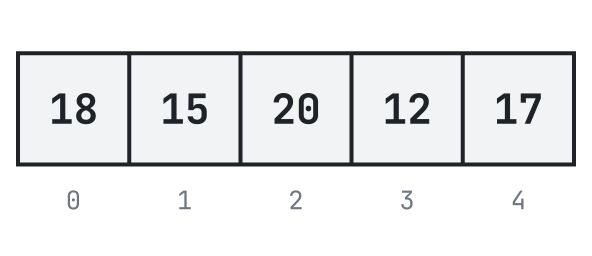

In [157]:
# ============================================================
# انیمیشن هدر Bubble Sort
# فقط اجرا کنید و رد شوید
# ============================================================
import base64, bisect, io, math, os, zlib
from PIL import Image as PILImage, ImageChops, ImageDraw, ImageFont
from IPython.display import HTML, Image, display

# ---------------- تنظیمات ----------------
HERO_VALUES     = [18, 15, 20, 12, 17]   # data-v ها در HTML
HERO_THEME      = "ink"                  # "ink" = سیاه‌وسفید | "light" = سبز فایل HTML | "dark" = سبز تم تیره
HERO_BG         = None                   # None = سفید (ink/light) / رنگ paper (dark)؛ یا مثلاً "#F5F7F4"
HERO_SCALE      = 2                      # کیفیت (۲ = ریتینا)
HERO_PAD        = 8                      # حاشیه‌ی اطراف (px)
HERO_LOOP       = True                   # True: تکرار بی‌نهایت | False: فقط یک بار (مثل خود HTML)
HERO_FINAL_HOLD = 3000                   # مکث روی حالت نهایی قبل از تکرار (ms)
HERO_ALIGN      = "right"                # فقط برای HERO_DISPLAY="html": "right" | "left" | "center"
HERO_DISPLAY    = "image"                # "image" = display(Image(...)) مثل کد اولِ خودت | "html" = تگ img داخل HTML
HERO_FRAME_MS   = 20                     # طول هر فریم GIF (ms)

_PALETTES = {
    "ink":   dict(accent="#1F2328", soft="#F3F4F5", ink="#1F2328", muted="#6E7781",
                  surface="#FFFFFF", paper="#FFFFFF"),
    "light": dict(accent="#0F766E", soft="#E3F3F0", ink="#16202B", muted="#5B6B7A",
                  surface="#FFFFFF", paper="#F5F7F4"),
    "dark":  dict(accent="#2DD4BF", soft="#12302E", ink="#E6EDF3", muted="#9AA9B8",
                  surface="#131E2A", paper="#0D1620"),
}

_FONT_B64 = {
    700: "eNptVFtsFFUY/s/sdrYshHZhdwuNtHvr9kJZtjOzM3stbdl2u7RJDa0UChaWsnRb9tIbUDAFH4zxQrylJAi+YMQQQ4wvJiQqEh+IGjVReTBg8BK8G5/UB0Nn/WZ2gUo8mznn/Oe/ff939vzEiGg1PU4G2pd4eGAwfqT/MBH/Ak4dicFHui7/c/lPyG9BbhkY3CxY3xz+nohlIO8bHOoc+q3xk2bov4bcP5ZLTdEqOgX9t5Cl8dTsFNZq6J/CWjmePXbwo8OWYSKulchwJZNOHWjduPtp6H7HJ2dwwD/KRuHvgezJ5ObmDc+z85A/hLwuWxhLGT+oOAt/qybnUvNTVEVB6Hs1vPlULm1WamWiCi3e8anC7FwxQyLya3gdpNXKycbucxcm91ZF/6o0GH7GCd384vWz2vrjdxEfKcW/uSbuNkSeOCoN+BnuqNfhvJMU8nNNeqTlg+knK6E13PV4YBi5ndy7VIEYzyAKUV9pRbUC6yAt1Ypl0ZaNbV2YrpKfQiUMhjus9a4N5+Vu6JVVINYIxWmQIvh1Ug+QRKkDsx5aR2XFzPTVCA8gwk+TQ8UiZn+xWPz8XuZa2k0FOkPX6BZbwxJshL3BvoH/CBKryGkAO8A7a3FaGpwWxpwj7DX1VdaqXsV3nbux5BW4iEpcBJZxMGoFoxaqp41E3S6vN2CRZFkU7HabxcrzjYKMA6/bxUO0Ky5vQNKUNivPWhOZUCiT6B3XZqm9XdK+DQ2eujqPxyzv72Lhrv0yVvUa1mxUYGEhGhXUa0L0Y69mU1fnRU2DIKEJqM1AHBAtpoAiWkTb0JX3Ly6+nGdLzz1xbGkxD7sI7GqAtFazU2Q5UALlbud0rFbeZHLaBm77fUF/ILrAItne7oPB7v4zTDj2Q9tAixiKyT3poDTaufVk8vS0dkcR1F6NzPXlukWrXUS1WmB3QHEGnDZTAJUiNM8aEhPhEyFJCgal7efVn9iZz7InwpNmabSjTQn6Q23K9OlD0+81zaRCHaMSYncCrQGxVxKlAs4AE5lNRHXsSfUdtv6U+uWnCy++zRbVPu8FdY+GpQdY1sDepWNpFO33oLh4k3ut0+Y0iSYwL+t42Mb0cX7BGNiMm5IcvlXHK9g59Sa3oS7ZvmvsMXN62NustCWEQG0Ne2n6+npfgOVSibEZ/Nu0F+REHhs5y1VLsrJWNNSUr7x84yVurXbWmizE3PWXnv2Kt8ZbIjv8sVyfEo8r+MyxQlKaEViNeslY7wge2JqYjEwmQpFEIhJKoKIoGHAgUyXui7ltbtBpOMcqf11gt4vcwclbR5ZeAZ4O4Fmn36p8H8/927Xaa2p0VCVQjY26gXzvxvkSyN7J8LbklKdZ9vmUFndhoOdkToq1NByNJ+R0d/eY0hOf97TEzG0j0a5Rp2gJe5rbhGZ3uFp07+3Yc+iQssm9xaI4drUHd/j9O4JbdjqC1e3uTUGNL1ThBD6dr9m1jTzvdv0Xg8GwjK+LOk/hYX8sn+zLx1yOS6YyXWyoxFLvRCSW3ybOCuovbF6jSqOs9K4rqEvrAsYVyLta7wvY49GvglTa82CztryvwrmrvK/G6/HRdkrTOB2mLKVohoYhTUDO0BziFnB6gJLYp7CboDFYFygHKV/uQBjFNAn/2x/RQdGHqnSNmR6iOmLxnv4hoDHqfsVlvdFMXmoiTtevzqbm8rTuAav7XblS739WffYQd3Q8M6eFmJhLZZmWzQhfvc8zHv1Z6/DE/VFihjhUXc75L/9LWM4=",
    400: "eNptVF1sG0UQnr2zz6nbJjGxnZJaDeckdn7c2vh85ySOfY5zsR3SpJaTqIkbXF+dNHaUNCFJf6ASquCloCL6UCRU8YAqQEgICaEC5VcRlQpvCKhUKBL/rRAqAonSB9ScmT2bJFTsaW9vZmdnvvlmb4AAQDWcAhZyidS+EeXY3qMA3GnUPpAYGYtd+vvSbZRfRbl934jXX/fE/h8BSAHl3Mho7+jN/JeNuH8V5Wx+Xl2EbXAG979HOTCjLi/iWov7p3Ctmpl79PCvq889C8B4ANjVwrQ65fEceAr3buGUCqjgsmQWzzej3FyYXznBXiU/ofwpyjvmFvKq4bLxBTxvpfK8emIRaqAT95MU7xF1fnrLw/cXAYzU39LiwvJKqQACxs/RfaC5MpKhtups88Ganr+qWPYX1MA3X7xynq43fwjtBqV0h3EwN1DkgIHywHPsXQ1zZMZBgR7GoXvaPIiu2QpB5LFy4p5hYMbJWTCij6fRC8BgeSVZ8JMo0FBbNnnbNB6K4WsVfNBVxsDeJZ5/bRgXc13PzIi+MpDCmYQ4rmOIM4WPArprHZUV30RfDXgCEeFD5a5SCd++Uqn0+XrkBjgAC/A8XIFvyX0kQQ6Q17CmLPoHomFMFtlBvMsW3tLCWwjhM+Ql7QLxaKs4rzLX11x+JqQBE0LLFDJaxfwMFmiEDoB+p8slWgKSJPjtdpvFynFuv4QKV5OTQ9EedLrEAN20WTni6ctLUr5POUTfPQMDPXTu5PmdOM2i2kuisZwo5mLaaq8qDg2FSTSMb201PPS700HtHE7MCVFjTa+DGRGLgsUkBgWLYMtcufLyyQtpJnxu6uTaiTTa4S1iqhFpA7ULSpJYBtUUYXSsVs5k4m2T33UF+rqjAxmma7ovpgZigxfJ0ORv4YOecDwpo0LI9kYeG34vTWsUL93R+Wqs5C1Y7QJmSx03iUFe5G0mETNF1xzhY3kp0x+OKEpk8C3tK/Lk5aljwSmzmJXD/cnuQETJvJHOfLh1KReQsyL6TmGA2+h7K4Aq8iIRiE3A7Mh57W3CH9Ku/ZF58RnyuhZtfVObpFjGsA4s2jt1LG7Bvg7FyZma6ngbbxJMyLyk4yHtE0vmjDEalGU54u7enjGSU9o11uEYlCfyS+bJ4Q6vEklElDYnOZf+s8ErkYV8Qn0Ebxv9g6wYxwZ8JeuAFKwT2PpKySsVL3NrtZPd8WJ3Y+M7U58Z6mJtPeO+7plEdHg4itMcmo0HZx8kbu0i69jVeTgenw2lxuLxMTrLDDD1GKkK60V4WxPSyb5LjNqtDPlkjTk999H42uP0/pdv4A2sq7SBaKO+Vnt9vY6rDMvt1g2k9ZpzOkx6FRNDqscnS5LsbVNTyePT4cSejlwq6Z+U5Ul/ciTXtjth9o6HerMtXpvS5uvs8rUq1j0tB2MTxZQsdsRtXndG7kx7POlOeaLNa+1vl6KUMdrR8N7pjC3XuTmuyflfDGzdJsbe15kKTfi6C/1l7rZXCCN7KU8z/YliKFRMIHXa1yS7ThgOI8RoFzBswajVel/Ab/zpt6FU/jZs0tegvqHyXYt/jwvSMA0zcBTmQIUl2I9SEeUCrMAAThX1Rcij1QLMo3Sk0nlwlKbB/799ETsn9p8afccMDtgFRInvHcWaGvRzpU09kSJoBUbfr55TV47AjnusNrpxld73rHr8ZmCOzxRWqIviijpHaDQOM2vXbRhiwM5MOzGQjyuIKzrmgzIXKNdudOZ/AMM/XMo=",
}
_UPM, _ASC, _DESC = 1000, 1020, 300

# ---------------- ثابت‌های CSS (rem = 16px) ----------------
REM   = 16.0
W     = 3.6 * REM                # --w
S     = W - 2                    # --s
TOP   = 1.1 * REM                # .hb { top }
LIFT  = -1.0 * REM               # --y هنگام بالا رفتن
STAGE_W = len(HERO_VALUES) * S + 2
STAGE_H = W + 3.4 * REM
HB_FONT, HI_FONT = 1.3 * REM, 0.8 * REM
LH = 2                           # body { line-height: 2 }
HB_BASE = 2 + (W - 4 - LH * HB_FONT) / 2 + (LH * HB_FONT - (_ASC + _DESC) / _UPM * HB_FONT) / 2 + _ASC / _UPM * HB_FONT
HI_TOP  = TOP + W + 0.25 * REM
HI_BASE = HI_TOP + (LH * HI_FONT - (_ASC + _DESC) / _UPM * HI_FONT) / 2 + _ASC / _UPM * HI_FONT


def _rgb(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _bezier(x1, y1, x2, y2):
    def f(t, a, b):
        return 3 * a * t * (1 - t) ** 2 + 3 * b * t ** 2 * (1 - t) + t ** 3
    def ease(x):
        if x <= 0: return 0.0
        if x >= 1: return 1.0
        lo, hi = 0.0, 1.0
        for _ in range(40):
            mid = (lo + hi) / 2
            if f(mid, x1, x2) < x: lo = mid
            else: hi = mid
        return f((lo + hi) / 2, y1, y2)
    return ease


EASE_MOVE  = _bezier(.4, 0, .2, 1)
EASE_COLOR = _bezier(.25, .1, .25, 1)


class _Tween:
    def __init__(self, v, dur, ease):
        self.dur, self.ease = dur, ease
        self.segs = [(-1e9, tuple(v), tuple(v))]
        self.times = [-1e9]

    def val(self, t):
        i = bisect.bisect_right(self.times, t) - 1
        t0, a, b = self.segs[i]
        if t >= t0 + self.dur: return b
        if t <= t0: return a
        e = self.ease((t - t0) / self.dur)
        return tuple(x + (y - x) * e for x, y in zip(a, b))

    def set(self, v, now):
        v = tuple(v)
        if v != self.segs[-1][2]:
            self.segs.append((now, self.val(now), v))
            self.times.append(now)


def _simulate(values, pal):
    accent, soft, ink, surface = (_rgb(pal[k]) for k in ("accent", "soft", "ink", "surface"))
    done_c = tuple(0.26 * a + 0.74 * s for a, s in zip(accent, surface))
    n = len(values)
    boxes = [dict(v=v, dom=i, p=i, y=0.0, cmp=False, done=False) for i, v in enumerate(values)]
    for b in boxes:
        b["xf"] = _Tween((b["p"] * S, 0.0), 400, EASE_MOVE)
        b["bg"] = _Tween(soft, 250, EASE_COLOR)
        b["fg"] = _Tween(ink, 250, EASE_COLOR)
        b["z"] = [(-1e9, 0)]
    order = list(boxes)
    clock = [0]

    def commit():
        t = clock[0]
        for b in boxes:
            b["xf"].set((b["p"] * S, b["y"]), t)
            b["bg"].set(accent if b["cmp"] else done_c if b["done"] else soft, t)
            b["fg"].set(surface if b["cmp"] else ink, t)
            z = 2 if b["cmp"] else 0
            if z != b["z"][-1][1]: b["z"].append((t, z))

    def sleep(ms):
        commit(); clock[0] += ms

    def place():
        for p, b in enumerate(order): b["p"] = p

    sleep(550)
    for pas in range(n - 1):
        swapped = False
        for j in range(n - 1 - pas):
            a, b = order[j], order[j + 1]
            a["cmp"] = b["cmp"] = True
            sleep(340)
            if a["v"] > b["v"]:
                a["y"] = LIFT; sleep(150)
                order[j], order[j + 1] = b, a; place(); sleep(420)
                a["y"] = 0.0; sleep(160)
                swapped = True
            a["cmp"] = b["cmp"] = False
        order[n - 1 - pas]["done"] = True
        if not swapped: break
    for o in order: o["done"] = True
    commit()
    return boxes, clock[0]


# ---------------- رسم یک فریم ----------------
_SS = 4
_K = HERO_SCALE * _SS
_fonts = {}
def _font(weight, css_px):
    key = (weight, css_px)
    if key not in _fonts:
        data = zlib.decompress(base64.b64decode(_FONT_B64[weight]))
        _fonts[key] = ImageFont.truetype(io.BytesIO(data), size=round(css_px * _K))
    return _fonts[key]


def _draw(boxes, t, pal, bg, size):
    accent, muted = _rgb(pal["accent"]), _rgb(pal["muted"])
    im = PILImage.new("RGB", (size[0] * _K, size[1] * _K), bg)
    d = ImageDraw.Draw(im)
    K = _K
    ox, oy = HERO_PAD, HERO_PAD
    r = lambda v: int(round(v * K))

    for i in range(len(boxes)):
        cx = ox + i * S + W / 2
        d.text((r(cx), r(oy + HI_BASE)), str(i), font=_font(400, HI_FONT), fill=muted, anchor="ms")

    def z_at(b):
        zs = b["z"]; return [z for tt, z in zs if tt <= t][-1]
    for b in sorted(boxes, key=lambda b: (z_at(b), b["dom"])):
        x, y = b["xf"].val(t)
        fill = tuple(int(round(c)) for c in b["bg"].val(t))
        txt = tuple(int(round(c)) for c in b["fg"].val(t))
        x0, y0 = r(ox + x), r(oy + TOP + y)
        x1, y1 = x0 + r(W), y0 + r(W)
        bw = r(2)
        d.rectangle([x0, y0, x1 - 1, y1 - 1], fill=accent)
        d.rectangle([x0 + bw, y0 + bw, x1 - bw - 1, y1 - bw - 1], fill=fill)
        d.text((x0 + (x1 - x0) / 2, y0 + r(HB_BASE)), str(b["v"]),
               font=_font(700, HB_FONT), fill=txt, anchor="ms")
    return im.resize((size[0] * HERO_SCALE, size[1] * HERO_SCALE), PILImage.BOX)


def build_hero_gif():
    pal = _PALETTES[HERO_THEME]
    bg = _rgb(HERO_BG or ("#FFFFFF" if HERO_THEME in ("light", "ink") else pal["paper"]))
    size = (int(math.ceil(STAGE_W)) + 2 * HERO_PAD, int(math.ceil(STAGE_H)) + 2 * HERO_PAD)
    boxes, t_end = _simulate(HERO_VALUES, pal)

    frames, durs, last_key, cache = [], [], None, {}
    t, t_stop = 0, t_end + 450
    while t <= t_stop:
        key = tuple((tuple(round(c, 2) for c in b["xf"].val(t)), tuple(round(c) for c in b["bg"].val(t)),
                     tuple(round(c) for c in b["fg"].val(t)), b["z"][-1][1] if b["z"][-1][0] <= t else 0)
                    for b in boxes)
        if key == last_key:
            durs[-1] += HERO_FRAME_MS
        else:
            if key not in cache: cache[key] = _draw(boxes, t, pal, bg, size)
            frames.append(cache[key]); durs.append(HERO_FRAME_MS); last_key = key
        t += HERO_FRAME_MS
    durs[-1] += HERO_FINAL_HOLD

    step = max(1, len(frames) // 16)
    sample = frames[::step]
    mosaic = PILImage.new("RGB", (frames[0].width * len(sample), frames[0].height))
    for i, fr in enumerate(sample): mosaic.paste(fr, (i * fr.width, 0))
    pal_img = mosaic.quantize(colors=256, method=PILImage.Quantize.MEDIANCUT, dither=PILImage.Dither.NONE)
    plt_ = pal_img.getpalette()[:768]
    bg_idx = min(range(len(plt_) // 3), key=lambda i: sum((plt_[i * 3 + k] - bg[k]) ** 2 for k in range(3)))
    plt_[bg_idx * 3:bg_idx * 3 + 3] = list(bg)
    pal_img = PILImage.new("P", (1, 1))
    pal_img.putpalette(plt_)
    solid = PILImage.new("RGB", frames[0].size, bg)
    q = []
    for fr in frames:
        qf = fr.quantize(palette=pal_img, dither=PILImage.Dither.NONE)
        same = ImageChops.difference(fr, solid).convert("L").point(lambda v: 255 if v == 0 else 0)
        qf.paste(bg_idx, mask=same)
        q.append(qf)

    buf = io.BytesIO()
    kw = dict(loop=0) if HERO_LOOP else {}
    q[0].save(buf, format="GIF", save_all=True, append_images=q[1:], duration=durs,
              disposal=1, optimize=False, **kw)
    return buf.getvalue(), size


hero_gif_bytes, hero_size = build_hero_gif()

os.makedirs("bin", exist_ok=True)
hero_gif_path = "bin/p05_hero_bubble_sort.gif"
with open(hero_gif_path, "wb") as f:
    f.write(hero_gif_bytes)

if HERO_DISPLAY == "image":
    display(Image(data=hero_gif_bytes, format="gif"))
else:
    _just = {"right": "flex-end", "left": "flex-start", "center": "center"}[HERO_ALIGN]
    display(HTML(
        f'<div style="display:flex;direction:ltr;justify-content:{_just}">'
        f'<img src="data:image/gif;base64,{base64.b64encode(hero_gif_bytes).decode()}" '
        f'width="{hero_size[0]}" height="{hero_size[1]}" alt="" style="max-width:100%;height:auto"></div>'
    ))

```{image} bin/p05_hero_bubble_sort.gif
:alt: انیمیشن Bubble Sort
:width: 296px
:align: right
:class: hero-anim
```

<div dir="rtl">

# بخش پنجم : ساختارهای داده پایه

</div>

<div dir="rtl">

## مقدمه

تا اینجای درس، با متغیرهای ساده کار کرده‌ایم: یک عدد صحیح، یک عدد اعشاری، یک کاراکتر. اما دنیای واقعی این‌طور نیست. وقتی می‌خواهیم نمرات ۵۰۰ دانشجو را ذخیره کنیم، دمای هوا را در ۳۶۵ روز سال نگه داریم، یا نام صد کاربر یک سیستم را در حافظه داشته باشیم، تعریف ۵۰۰ متغیر جداگانه به نام‌های `score1، score2، ...، score500` نه‌تنها خسته‌کننده بلکه عملاً غیرممکن است. مشکل تکنیکی مشخص است: ما به راهی نیاز داریم که مجموعه‌ای از داده‌های هم‌نوع را زیر یک نام واحد نگه داریم و بتوانیم با استفاده از یک عدد (نه یک نام جدید) به هرکدام از آن‌ها دسترسی پیدا کنیم.

این بخش دقیقاً همین مسئله و راه‌حل آن را دنبال می‌کند. مسیر حرکت ما این‌طور است: ابتدا **آرایه‌ها (Arrays)** را معرفی می‌کنیم تا بتوانیم مجموعه‌ای از داده‌ها را نگه داریم و پیمایش کنیم. سپس با داشتن این مجموعه داده، دو سؤال طبیعی پیش می‌آید: «چطور یک مقدار خاص را در این مجموعه پیدا کنیم؟» که به **جستجو (Searching)** می‌رسیم، و «چطور این مجموعه را مرتب کنیم؟» که به **مرتب‌سازی (Sorting)** می‌رسیم. در نهایت متوجه می‌شویم که رشته‌های متنی (**Strings**) در زبان C چیزی نیستند جز یک نوع خاص از آرایه، آرایه‌ای از کاراکترها با یک قانون پایانی خاص.

در طول این بخش، از یک سناریوی واحد استفاده می‌کنیم تا مفاهیم پراکنده نمانند: **سیستم مدیریت نمرات دانشجویان**. نمرات را در آرایه ذخیره می‌کنیم، در آن‌ها جستجو می‌کنیم، آن‌ها را مرتب می‌کنیم، و در نهایت نام دانشجویان را به‌عنوان رشته مدیریت می‌کنیم.

</div>

<div dir="rtl">

#### نقشه کلی بخش:
</div>

```text
متغیر معمولی → Array → Index → Traversal → Operations
                                              │
                              ┌───────────────┴──────────────────┐
		                    Search                              Sort
                              │                                  │
                        Linear Search                Bubble /Selection / Insertion
                              │                                  │
                              └────────► Binary Search ◄─────────┘
                                        (نیازمند آرایه مرتب)

Character Array → '\0' → String → strlen / strcpy / strcmp / strcat
```
<br>

---


<div dir="rtl">

## فصل ۱۱ : Arrays

</div>

<div dir="rtl">

### 11.1 چرا به آرایه نیاز داریم؟

فرض کنید استاد درس «مبانی کامپیوتر» می‌خواهد میانگین نمرات ۵ دانشجو را در یک کوییز محاسبه کند. با دانش فعلی‌مان می‌نویسیم:

</div>

In [158]:
%%writefile src/p05_c11_01_array_naive_avg.c

#include <stdio.h>

int main(void)
{
    int score1 = 18, score2 = 15, score3 = 20, score4 = 12, score5 = 17;
    double average = (score1 + score2 + score3 + score4 + score5) / 5.0;

    printf("Average: %.2f\n", average);
    return 0;
}

Overwriting src/p05_c11_01_array_naive_avg.c


In [159]:
!gcc -Wall -o bin/p05_c11_01_array_naive_avg src/p05_c11_01_array_naive_avg.c && ./bin/p05_c11_01_array_naive_avg

Average: 16.40


<div dir="rtl">

برای ۵ دانشجو این کد قابل تحمل است. اما چند سؤال را از خودتان بپرسید:

- اگر تعداد دانشجویان ۵۰۰ نفر بود، باید ۵۰۰ متغیر تعریف می‌کردیم؟
- اگر بخواهیم نمره دانشجوی شماره ۲۳۷ را پیدا کنیم، چطور با نام متغیر به آن دسترسی پیدا کنیم وقتی این عدد از ورودی کاربر می‌آید و در زمان نوشتن برنامه معلوم نیست؟
- اگر بخواهیم روی همه نمرات یک حلقه بزنیم (مثلاً همه را چاپ کنیم)، با ۵۰۰ متغیر مجزا اصلاً حلقه‌زدن معنا ندارد؛ حلقه روی چه چیزی تکرار می‌شود؟

<br>
مشکل اصلی این است: متغیرهای معمولی هرکدام یک «نام» مستقل دارند و هیچ ارتباط ساختاریافته‌ای بین آن‌ها وجود ندارد که برنامه بتواند به‌صورت برنامه‌نویسی‌شده (نه دستی) بین آن‌ها حرکت کند. ما به سازه‌ای نیاز داریم که:

1. مجموعه‌ای از مقادیر هم‌نوع را زیر یک نام واحد نگه دارد.
2. به هر عضو این مجموعه با یک **عدد** (نه یک نام جدید) دسترسی داده شود.
3. بتوان با یک حلقه، روی تمام اعضای آن حرکت کرد.

این دقیقاً همان چیزی است که **آرایه (Array)** فراهم می‌کند.

</div>

<div dir="rtl">

### 11.2 مفهوم آرایه و Index

آرایه را می‌توان مثل یک ردیف از جعبه‌های هم‌اندازه و چسبیده‌به‌هم تصور کرد که همه زیر یک برچسب واحد قرار دارند. هر جعبه یک مقدار نگه می‌دارد، و برای رسیدن به جعبه‌ی مورد نظر، به‌جای نام، از **شماره جعبه** استفاده می‌کنیم. این شماره را **اندیس (Index)** می‌نامیم.

نکته‌ای که در همین ابتدا باید کاملاً جا بیفتد: **در زبان C، شماره‌گذاری جعبه‌ها از صفر شروع می‌شود، نه از یک.** یعنی اگر آرایه‌ای ۵ عنصر داشته باشد، اندیس‌های معتبر آن `0، 1، 2، 3، 4` هستند، نه `1` تا `5`. این یکی از رایج‌ترین منابع خطا برای دانشجویان تازه‌کار است و در ادامه به آن بازمی‌گردیم. توجه کنید تشبیه «ردیف جعبه‌ها» فقط یک **مدل ذهنی** است برای کمک به تصور اولیه؛ در بخش «آرایه و حافظه» دقیقاً می‌بینیم این تشبیه در سطح حافظه واقعی به چه معناست.

</div>

<div dir="rtl">

### 11.3 تعریف و مقداردهی در C

برای تعریف یک آرایه در C، باید سه چیز را مشخص کنیم: نوع داده‌ی عناصر، نام آرایه، و تعداد عناصر (اندازه آرایه):

<div dir="ltr">

```c
int scores[5];
```
</div>
<br>

این خط می‌گوید: «۵ عدد صحیح پشت‌سرهم در حافظه رزرو کن و نام این مجموعه را `scores` بگذار.»
توجه کنید در این حالت، مقادیر داخل `scores` **مقداردهی نشده‌اند**؛ یعنی مقادیر آن نامشخص (Indeterminate) هستند، نه لزوماً صفر. اگر آرایه در سطح تابع (Local) تعریف شود و مقداردهی اولیه نگیرد، نباید انتظار داشته باشیم مقدار خاصی مثل صفر در آن باشد؛ این یکی از جاهایی است که نباید رفتار Undefined را با رفتاری «قابل پیش‌بینی» اشتباه گرفت.

برای مقداردهی اولیه هم‌زمان با تعریف:

<div dir="ltr">

```c
int scores[5] = {18, 15, 20, 12, 17};
```
</div>
<br>

اگر تعداد مقادیر داده‌شده کمتر از اندازه آرایه باشد:

<div dir="ltr">

```c
int scores[5] = {18, 15};
```
</div>
<br>

در این حالت سه عنصر باقی‌مانده (اندیس‌های ۲، ۳ و ۴) به‌صورت خودکار با صفر مقداردهی می‌شوند. این رفتار فقط مخصوص مقداردهی اولیه (Initialization) با آکولاد است، نه رفتار عمومی آرایه‌ها.

<br>

یک نکته Clean Code:
>به‌جای نوشتن عدد `5` به‌صورت مستقیم (Magic Number) در چند جای برنامه، بهتر است از یک ثابت نام‌گذاری‌شده استفاده کنیم:

<div dir="ltr">

```c
#define STUDENT_COUNT 5

int scores[STUDENT_COUNT];
```
</div>

چرا این بهتر از نوشتن مستقیم `5` است؟<br>
	چون اگر بعداً تعداد دانشجویان تغییر کند، فقط کافی‌ست یک عدد را در یک خط عوض کنیم؛ در غیر این صورت باید در تمام برنامه دنبال عدد `5` بگردیم و ریسک فراموش کردن یک مورد وجود دارد. همچنین `STUDENT_COUNT` برای خواننده کد معنادارتر از یک عدد تنها است.


</div>

<div dir="rtl">

### 11.4 دسترسی و تغییر عناصر

برای خواندن یا نوشتن یک عنصر خاص، از نام آرایه به همراه اندیس داخل کروشه استفاده می‌کنیم:

<div dir="ltr">

```c
printf("%d\n", scores[0]);   // چاپ اولین عنصر
scores[2] = 19;              // تغییر سومین عنصر
```
</div>
<br>

اینجا `scores[0]` یعنی «اولین جعبه»، و `scores[2]` یعنی «سومین جعبه»؛ چون شمارش از صفر شروع می‌شود. اگر آرایه‌ای `n` عنصر داشته باشد، آخرین اندیس معتبر آن همیشه `n - 1` است، نه `n`. این نکته آن‌قدر مهم است که دوباره در بخش خطاهای رایج به آن بازم

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۱.۱

**نوع تمرین: Predict the Output**

<div dir="ltr">

```c
int arr[4] = {5, 10, 15};
printf("%d\n", arr[3]);
```
</div>

بدون اجرای کد، خروجی را پیش‌بینی کنید و دلیل بیاورید.

</div>

In [160]:
%%writefile src/p05_c11_02_array_traversal.c

#include <stdio.h>
#define STUDENT_COUNT 5

int main(void)
{
    int scores[STUDENT_COUNT] = {18, 15, 20, 12, 17};

    for (int i = 0; i < STUDENT_COUNT; i++) {
        printf("Student %d: %d\n", i, scores[i]);
    }

    return 0;
}

Overwriting src/p05_c11_02_array_traversal.c


In [161]:
!gcc -Wall -o bin/p05_c11_02_array_traversal src/p05_c11_02_array_traversal.c && ./bin/p05_c11_02_array_traversal

Student 0: 18
Student 1: 15
Student 2: 20
Student 3: 12
Student 4: 17


<div dir="rtl">

چرا حلقه از `i = 0` شروع می‌شود؟
<br>چون اگر بعداً تعداد دانشجویان تغییر کند، فقط کافی‌ست یک عدد را در یک خط عوض کنیم؛ در غیر این صورت باید در تمام برنامه دنبال عدد `5` بگردیم و ریسک فراموش کردن یک مورد وجود دارد. همچنین `STUDENT_COUNT` برای خواننده کد معنادارتر از یک عدد تنها است.

>این خطا را **Out-of-Bounds Access** می‌نامند و در C به‌صورت خودکار تشخیص داده نمی‌شود؛ کامپایلر معمولاً هیچ خطایی نمی‌دهد، اما برنامه ممکن است رفتار نامشخص (Undefined Behavior) از خود نشان دهد: گاهی یک مقدار بی‌معنی چاپ می‌شود، گاهی برنامه کرش می‌کند، و گاهی به‌ظاهر کار می‌کند ولی حافظه‌ای را که متعلق به داده دیگری است دستکاری می‌کند. همین غیرقابل‌پیش‌بینی بودن است که این خطا را خطرناک می‌کند.

</div>

In [162]:
scores_demo = [18, 15, 20, 12, 17]

show_traversal(scores_demo)


<div dir="rtl">

#### جریان اجرای Traversal

مسیر تصمیم‌گیری حلقه‌ی بالا (بررسی شرط، انجام کار، افزایش `i`، و بازگشت به بررسی شرط) یک الگوی تکرارشونده است که در تقریباً تمام الگوریتم‌های این بخش (جستجو، مرتب‌سازی، پیمایش رشته) دوباره دیده می‌شود. دیدن آن به‌صورت Flowchart از همین‌جا به فهم بهتر آن‌ها کمک می‌کند:

```mermaid
flowchart TD
    A([شروع]) --> B["i ← 0"]
    B --> C{"i < n ?"}
    C -- خیر --> E([پایان])
    C -- بله --> D["پردازش array[i]"]
    D --> F["i ← i + 1"]
    F --> C
```

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۱.۲: چرا خطای مرزی خطرناک است؟

**نوع تمرین: Quick Reasoning**

<div dir="ltr">

```c
int arr[5] = {1, 2, 3, 4, 5};
printf("%d\n", arr[5]);
```
</div>

این کد را کامپایل و اجرا کنید (یا در ذهن تحلیل کنید). آیا کامپایلر خطایی می‌دهد؟ چرا با وجود این‌که `arr[5]` خارج از محدوده‌ی معتبر آرایه است (اندیس‌های معتبر فقط `0` تا `4` هستند)، ممکن است برنامه بدون هیچ پیام خطایی یک عدد بی‌معنی چاپ کند؟ توضیح دهید چرا این سکوت کامپایلر و اجرای برنامه، خطای Out-of-Bounds را خطرناک‌تر از یک خطای کامپایل می‌کند.

</div>

<div dir="rtl">

### 11.6 عملیات پایه روی آرایه

با پیمایش، حالا می‌توانیم محاسبات معناداری روی مجموعه داده انجام دهیم.

</div>

<div dir="ltr">

#### Example A - Simple: جمع و میانگین

</div>

In [163]:
%%writefile src/p05_c11_03_array_sum_avg.c

#include <stdio.h>
#define STUDENT_COUNT 5

int main(void)
{
    int scores[STUDENT_COUNT] = {18, 15, 20, 12, 17};
    int sum = 0;

    for (int i = 0; i < STUDENT_COUNT; i++) {
        sum += scores[i];
    }

    double average = sum / (double)STUDENT_COUNT;
    printf("Sum: %d, Average: %.2f\n", sum, average);

    return 0;
}

Overwriting src/p05_c11_03_array_sum_avg.c


In [164]:
!gcc -Wall -o bin/p05_c11_03_array_sum_avg src/p05_c11_03_array_sum_avg.c && ./bin/p05_c11_03_array_sum_avg

Sum: 82, Average: 16.40


<div dir="rtl">

چرا `sum / (double)STUDENT_COUNT` و نه `sum / STUDENT_COUNT`؟
<br>
	چون هر دو `sum` و `STUDENT_COUNT` از نوع `int` هستند، و تقسیم دو عدد صحیح در C به‌صورت **تقسیم صحیح** انجام می‌شود (قسمت اعشاری دور ریخته می‌شود). با تبدیل صریح (`Cast`) یکی از آن‌ها به `double`، کل عبارت به‌صورت اعشاری محاسبه می‌شود.


</div>

<div dir="ltr">

#### Example B — Real: پیدا کردن بیشترین نمره

</div>

In [165]:
%%writefile src/p05_c11_04_array_max.c

#include <stdio.h>
#define STUDENT_COUNT 5

int main(void)
{
    int scores[STUDENT_COUNT] = {18, 15, 20, 12, 17};
    int max = scores[0];

    for (int i = 1; i < STUDENT_COUNT; i++) {
        if (scores[i] > max) {
            max = scores[i];
        }
    }

    printf("Max grade: %d\n", max);
    return 0;
}

Overwriting src/p05_c11_04_array_max.c


In [166]:
!gcc -Wall -o bin/p05_c11_04_array_max src/p05_c11_04_array_max.c && ./bin/p05_c11_04_array_max

Max grade: 20


<div dir="rtl">

چرا `max` را با `scores[0]` مقداردهی اولیه می‌کنیم، نه با `0`؟
<br>
	اگر همه نمرات منفی بودند (مثلاً در یک مسئله دیگر با اعداد منفی)، مقداردهی اولیه با `0` باعث می‌شد `max` هرگز به‌درستی به‌روزرسانی نشود، چون هیچ عددی از `0` بزرگ‌تر نمی‌شد در حالی که همه اعداد واقعی منفی هستند. با شروع از `scores[0]`، همیشه یک مقدار واقعی از خود آرایه را به‌عنوان نقطه شروع داریم. به همین دلیل هم حلقه از `i = 1` شروع می‌شود، نه `i = 0`؛ چون عنصر صفرم را از قبل در `max` قرار داده‌ایم و بررسی دوباره‌ی آن ضروری نیست (هرچند اگر از `i = 0` هم شروع می‌شد، نتیجه اشتباه نمی‌شد، فقط یک مقایسه اضافه انجام می‌شد).


</div>

<div dir="rtl">
<div dir="ltr">

#### Example C - Tricky: آرایه تک‌عنصری
</div>

اگر `STUDENT_COUNT` برابر ۱ باشد چه اتفاقی می‌افتد؟
<br>
	در کد Max بالا، `max = scores[0]` مقداردهی می‌شود و حلقه `for (i = 1; i < 1; ...)` اصلاً اجرا نمی‌شود؛ که کاملاً درست است، چون تنها عنصر موجود همان مقدار ماکزیمم است. این مثال نشان می‌دهد چرا الگوی «مقداردهی اولیه با عنصر صفرم، سپس حلقه از یک» در برابر حالت‌های مرزی (Edge Case) هم درست عمل می‌کند؛ نکته‌ای که در طراحی الگوریتم‌های بعدی هم بارها می‌بینیم.

</div>

<div dir="rtl">

### 11.7 آرایه و حافظه

حالا وقت آن است که تشبیه «ردیف جعبه‌ها» را با واقعیت فنی‌تری جایگزین کنیم. وقتی می‌نویسیم:

<div dir="ltr">

```c
int scores[5];
```
</div>

کامپایلر یک بلوک پیوسته (Contiguous) از حافظه به اندازه‌ی «۵ برابر اندازه یک `int`» رزرو می‌کند. روی اکثر سیستم‌های رایج امروزی، اندازه‌ی `int` برابر ۴ بایت است (این مقدار طبق استاندارد C ثابت نیست و به Implementation بستگی دارد؛ برای اطمینان از اندازه واقعی روی یک سیستم مشخص از عملگر `sizeof` استفاده می‌شود). یعنی حافظه‌ای شبیه این تخصیص می‌یابد:

<div dir="ltr">

```text
Index:     0      1      2      3      4
        ┌──────┬──────┬──────┬──────┬──────┐
Value:  │  18  │  15  │  20  │  12  │  17  │
        └──────┴──────┴──────┴──────┴──────┘
Address: 1000    1004   1008   1012   1016   (فرضی، وابسته به سیستم)
```
</div>
<br>

نکته کلیدی: چون عناصر پشت‌سرهم و بدون فاصله در حافظه قرار دارند، کامپایلر می‌تواند آدرس هر عنصر را فقط با یک محاسبه ساده پیدا کند: `آدرس شروع + (اندیس × اندازه هر عنصر)`. این دقیقاً همان چیزی است که دسترسی به `scores[i]` را در زمان ثابت (بدون وابستگی به اندازه آرایه) ممکن می‌کند؛ نکته‌ای که بعداً هنگام بحث درباره Complexity به آن اشاره می‌کنیم.

برای گرفتن اندازه‌ی واقعی یک آرایه بر حسب بایت، از `sizeof` استفاده می‌شود:

<div dir="ltr">

```c
int scores[5] = {18, 15, 20, 12, 17};
printf("%zu\n", sizeof(scores));          // اندازه کل آرایه بر حسب بایت
printf("%zu\n", sizeof(scores) / sizeof(scores[0]));  // تعداد عناصر
```
</div>
<br>

الگوی `sizeof(array) / sizeof(array[0])` برای محاسبه‌ی «تعداد عناصر» رایج است، اما فقط در محدوده‌ای معتبر است که `scores` واقعاً یک آرایه باشد (نه یک اشاره‌گر که از تابع دیگری دریافت شده). این تفاوت در بخش بعد روشن می‌شود.


</div>

In [167]:
display(fig_memory(scores_demo, 1000, 4))
print("فاصله‌ی هر دو خانه‌ی متوالی همواره برابر sizeof(int) = 4 بایت است.")
print("دقیقاً به همین دلیل، آدرس هر عنصر با یک محاسبه‌ی ساده از آدرس شروع به‌دست می‌آید:")
print("address(scores[i]) = address(scores[0]) + i * sizeof(int)")


فاصله‌ی هر دو خانه‌ی متوالی همواره برابر sizeof(int) = 4 بایت است.
دقیقاً به همین دلیل، آدرس هر عنصر با یک محاسبه‌ی ساده از آدرس شروع به‌دست می‌آید:
address(scores[i]) = address(scores[0]) + i * sizeof(int)


<div dir="rtl">

### 11.8 آرایه و توابع

فرض کنید می‌خواهیم محاسبه‌ی جمع را در یک تابع جدا قرار دهیم:

</div>

In [168]:
%%writefile src/p05_c11_05_array_func_param.c

#include <stdio.h>
#define STUDENT_COUNT 5

int sumArray(int arr[], int size)
{
    int sum = 0;
    for (int i = 0; i < size; i++) {
        sum += arr[i];
    }
    return sum;
}

int main(void)
{
    int scores[STUDENT_COUNT] = {18, 15, 20, 12, 17};
    printf("Sum: %d\n", sumArray(scores, STUDENT_COUNT));
    return 0;
}

Overwriting src/p05_c11_05_array_func_param.c


In [169]:
!gcc -Wall -o bin/p05_c11_05_array_func_param src/p05_c11_05_array_func_param.c && ./bin/p05_c11_05_array_func_param

Sum: 82


<div dir="rtl">

نکته بسیار مهم اینجاست: چرا `size` را به‌عنوان یک پارامتر جداگانه به تابع پاس می‌دهیم؟ چرا تابع خودش نمی‌تواند اندازه‌ی آرایه را بفهمد؟<br>
	دلیل این است که وقتی یک آرایه به‌عنوان آرگومان به تابعی پاس داده می‌شود، در عمل فقط **آدرس اولین عنصر** آن منتقل می‌شود، نه خودِ آرایه (به این رفتار **Array Decay** گفته می‌شود؛ جزئیات دقیق‌تر آن را در فصل اشاره‌گرها خواهیم دید). به همین دلیل، تابع دیگر نمی‌داند آرایه‌ی ورودی اصلاً چند عنصر دارد. برای همین اگر داخل `sumArray` بنویسیم `sizeof(arr)`، نتیجه اندازه‌ی یک اشاره‌گر خواهد بود (مثلاً ۸ بایت روی بسیاری از سیستم‌های ۶۴ بیتی)، نه اندازه‌ی کل آرایه؛ یک اشتباه بسیار رایج. به همین دلیل، همیشه باید اندازه‌ی آرایه را به‌صورت جداگانه و صریح به تابع پاس بدهیم.


</div>

<div dir="rtl">

### 11.9 خطاهای رایج در آرایه یک‌بعدی

**❌ اشتباه ۱: شروع اندیس از یک**

<div dir="ltr">

```c
for (int i = 1; i <= STUDENT_COUNT; i++) {
    printf("%d\n", scores[i]);
}
```
</div>

چرا اشتباه است؟<br>
	این حلقه از `scores[1]` شروع می‌شود (که در واقع دومین عنصر است، نه اولین) و تا `scores[STUDENT_COUNT]` پیش می‌رود که یک اندیس خارج از محدوده است. چه اتفاقی ممکن است بیفتد؟ اولین عنصر واقعی (`scores[0]`) هرگز چاپ نمی‌شود، و در انتها یک دسترسی خارج از محدوده رخ می‌دهد که رفتار آن نامشخص است.

**✅ نسخه صحیح**

<div dir="ltr">

```c
for (int i = 0; i < STUDENT_COUNT; i++) {
    printf("%d\n", scores[i]);
}
```
</div>

چرا صحیح است؟<br>
	حلقه دقیقاً از اولین اندیس معتبر (`0`) شروع شده و درست قبل از رسیدن به اولین اندیس نامعتبر (`STUDENT_COUNT`) متوقف می‌شود.
<br>

**❌ اشتباه ۲: فرض کردن مقداردهی خودکار به صفر**

<div dir="ltr">

```c
int arr[10];
printf("%d\n", arr[3]);   // انتظار چاپ 0
```
</div>

چرا اشتباه است؟<br>
	اگر `arr` یک آرایه محلی (Local) در یک تابع باشد و به‌صورت صریح مقداردهی نشده باشد، محتوای آن نامشخص است؛ ممکن است هر عددی چاپ شود.

**✅ نسخه صحیح**

<div dir="ltr">

```c
int arr[10] = {0};   // تمام عناصر با صفر مقداردهی می‌شوند
printf("%d\n", arr[3]);
```
</div>

چرا صحیح است؟<br>
	نوشتن `{0}` در مقداردهی اولیه باعث می‌شود اولین عنصر صفر شود و طبق قانونی که در بخش ۱۱.۳ دیدیم، بقیه عناصر هم به‌صورت خودکار صفر می‌شوند.

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش: آرایه یک‌بعدی

★ **سطح پایه**

1. **Complete the Code:**<br>
 آرایه‌ای ۶ عنصری از نمرات تعریف کنید و تابعی بنویسید که مجموع تمام عناصر را برگرداند.

2. **Predict the Output:**

<div dir="ltr">

```c
int arr[3] = {7};
printf("%d %d %d\n", arr[0], arr[1], arr[2]);
```
</div>

خروجی را پیش‌بینی کرده و دلیل آن را با استناد به قانون مقداردهی جزئی توضیح دهید.
<br>

★★ **سطح متوسط**

3. **Find the Bug:**
<div dir="ltr">

```c
int arr[5] = {3, 7, 1, 9, 4};
int max = 0;
for (int i = 0; i < 5; i++) {
    if (arr[i] > max) max = arr[i];
}
```
</div>

اگر تمام مقادیر آرایه منفی باشند، این کد چه نتیجه‌ی اشتباهی تولید می‌کند؟ چرا؟ (راهنمایی: به بخش ۱۱.۶، Example B بازگردید.)

4. **Small Implementation:**<br>
 تابعی بنویسید که یک آرایه‌ی عددی و اندازه‌ی آن را دریافت کند و **کوچک‌ترین** عنصر آرایه را برگرداند. سپس آن را برای آرایه‌ای با یک عنصر و آرایه‌ای با عناصر تکراری تست کنید.

5. **Trace:**<br>
 برای آرایه‌ی `arr = {2, 4, 6, 8}`، مقدار `sum` را بعد از هر iteration حلقه‌ی جمع‌کننده مشخص کنید.
<br>

★★★ **سطح چالشی**

6. **Explain Why:**<br>
 توضیح دهید چرا در تابع زیر، آخرین اندیس معتبر همیشه `size - 1` است، نه `size`:

<div dir="ltr">

```c
void printLast(int arr[], int size)
{
    printf("%d\n", arr[size - 1]);
}
```
</div>

اگر کسی به‌اشتباه از `arr[size]` استفاده کند، چه نوع خطایی رخ می‌دهد و چرا ممکن است این خطا بلافاصله خودش را نشان ندهد؟

7. **Design:**<br>
 تابعی طراحی و پیاده‌سازی کنید که یک آرایه از نمرات را دریافت کند و تعداد نمراتی که **بالای میانگین کل** هستند را برگرداند. دقت کنید ابتدا باید میانگین را محاسبه کنید، سپس در یک پیمایش دوم مقایسه انجام دهید.

</div>

<div dir="rtl">

### 11.10 آرایه چندبعدی و Matrix

</div>

<div dir="rtl">

#### چرا به آرایه چندبعدی نیاز داریم؟

فرض کنید حالا می‌خواهیم نه فقط نمره‌ی یک کوییز، بلکه نمرات ۴ کوییز مختلف را برای ۳ دانشجو ذخیره کنیم. می‌توانیم برای هر کوییز یک آرایه یک‌بعدی جدا تعریف کنیم، اما این کار داده‌ای که ذاتاً دوبعدی است (دانشجو × کوییز) را به‌صورت مصنوعی تکه‌تکه می‌کند. راه‌حل طبیعی‌تر، یک **آرایه دوبعدی** است: نوعی «جدول» با سطر (Row) و ستون (Column)، که سطر معمولاً نشان‌دهنده‌ی یک دانشجو و ستون نشان‌دهنده‌ی یک کوییز است.

</div>

<div dir="rtl">

#### تعریف و مقداردهی در C

<div dir="ltr">

```c
int scores[3][4] = {
    {18, 15, 20, 17},   // دانشجوی ۰
    {12, 14, 16, 18},   // دانشجوی ۱
    {20, 19, 18, 20}    // دانشجوی ۲
};
```
</div>
<br>

اینجا `scores` یک آرایه‌ی ۳ در ۴ است: ۳ سطر (دانشجو) و ۴ ستون (کوییز). دسترسی به یک خانه‌ی مشخص با دو اندیس انجام می‌شود:

<div dir="ltr">

```c
printf("%d\n", scores[1][2]);  // نمره کوییز شماره ۲ برای دانشجوی شماره ۱ → 16
```
</div>
<br>

</div>

<div dir="rtl">

#### پیمایش با حلقه‌های تودرتو

</div>

In [170]:
%%writefile src/p05_c11_06_matrix_traversal.c

#include <stdio.h>
#define ROWS 3
#define COLS 4

int main(void)
{
    int scores[ROWS][COLS] = {
        {18, 15, 20, 17},
        {12, 14, 16, 18},
        {20, 19, 18, 20}
    };

    for (int i = 0; i < ROWS; i++) {
        for (int j = 0; j < COLS; j++) {
            printf("%d ", scores[i][j]);
        }
        printf("\n");
    }

    return 0;
}

Overwriting src/p05_c11_06_matrix_traversal.c


In [171]:
!gcc -Wall -o bin/p05_c11_06_matrix_traversal src/p05_c11_06_matrix_traversal.c && ./bin/p05_c11_06_matrix_traversal

18 15 20 17 
12 14 16 18 
20 19 18 20 


<div dir="rtl">

حلقه‌ی بیرونی (`i`) روی سطرها حرکت می‌کند و حلقه‌ی داخلی (`j`) برای هر سطر روی تمام ستون‌ها حرکت می‌کند. این الگوی «حلقه در حلقه» را باید کاملاً بشناسید، چون دوباره در الگوریتم‌های مرتب‌سازی می‌بینیدش.

</div>

In [172]:
matrix_demo = [
    [18, 15, 20, 17],
    [12, 14, 16, 18],
    [20, 19, 18, 20],
]

show_matrix(matrix_demo)


<div dir="rtl">
<br>

#### مثال کاربردی: میانگین نمرات هر دانشجو

<div dir="ltr">

```c
for (int i = 0; i < ROWS; i++) {
    int sum = 0;
    for (int j = 0; j < COLS; j++) {
        sum += scores[i][j];
    }
    printf("Student %d average: %.2f\n", i, sum / (double)COLS);
}
```
</div>

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۱.۳

**نوع تمرین: Trace**

برای آرایه‌ی زیر، خروجی کد پیمایش دوبعدی را دستی روی کاغذ بنویسید:

<div dir="ltr">

```c
int arr[2][3] = {{1, 2, 3}, {4, 5, 6}};
```
</div>
<br>

</div>

<div dir="rtl">

<div dir="ltr">

#### Memory Layout: Row-Major Order
</div>

یک سؤال طبیعی این است: آرایه دوبعدی در حافظه چگونه ذخیره می‌شود، وقتی حافظه خودش یک‌بعدی (یک ردیف پیوسته از بایت‌ها) است؟<br>
پاسخ: کامپایلرهای C از روشی به نام **Row-Major Order** استفاده می‌کنند؛ یعنی تمام عناصر سطر اول، سپس تمام عناصر سطر دوم، و به همین ترتیب، پشت‌سرهم در حافظه چیده می‌شوند:

<div dir="ltr">

```text
Row 0: 18  15  20  17
Row 1: 12  14  16  18
Row 2: 20  19  18  20

در حافظه به ترتیب:
18 15 20 17 | 12 14 16 18 | 20 19 18 20
```
</div>
<br>

<div dir="rtl"> Row-Major به ترتیب ذخیره‌شدن عناصر در حافظه مربوط است، نه الزاماً به ترتیب اجرای حلقه‌های برنامه. </div>

عناصر یک آرایه‌ی دوبعدی `3×4` در حافظه به‌صورت پیوسته و در ترتیب Row-Major ذخیره می‌شوند؛ بنابراین در مجموع ۱۲ عنصر `int` در این آرایه وجود دارد. کامپایلر با محاسبه‌ی `آدرس شروع + (i × تعداد_ستون + j) × اندازه_عنصر` به خانه‌ی `[i][j]` دسترسی پیدا می‌کند. لازم نیست این فرمول را حفظ کنید، اما درک این‌که آرایه دوبعدی در سطح حافظه یک ساختار پیوسته‌ی یک‌بعدی است، به فهم بهتر مفاهیم پیشرفته‌تر در آینده کمک می‌کند.
</div>

<div dir="rtl">

#### تمرین درون فصل ۱۱.۴ : ترتیب دسترسی در Row-Major

**نوع تمرین: Trace**

برای ماتریس زیر:

<div dir="ltr">

```c
int m[2][3] = {{10, 20, 30}, {40, 50, 60}};
```
</div>
<br>

اگر دو حلقه‌ی تودرتوی زیر را اجرا کنیم:

<div dir="ltr">

```c
for (int j = 0; j < 3; j++) {
    for (int i = 0; i < 2; i++) {
        printf("%d ", m[i][j]);
    }
}
```
</div><br>

ترتیب دقیق چاپ مقادیر چیست؟ (دقت کنید این‌بار حلقه‌ی بیرونی روی **ستون** و حلقه‌ی داخلی روی **سطر** حرکت می‌کند؛ برخلاف الگوی معمول متن.) این ترتیب را با ترتیب Row-Major که در حافظه ذخیره شده مقایسه کنید.

</div>

<div dir="rtl">

#### خطاهای رایج در آرایه دوبعدی

**❌ اشتباه: جابه‌جا کردن اندیس سطر و ستون**

<div dir="ltr">

```c
printf("%d\n", scores[COLS][ROWS]);  // اشتباه در ترتیب و در مقدار
```
</div>

چرا اشتباه است؟<br>
	اندیس اول همیشه سطر و اندیس دوم همیشه ستون است؛ استفاده از `COLS` و `ROWS` به‌جای مقادیر واقعی اندیس، هم مفهوماً و هم از نظر محدوده (چون `COLS` و `ROWS` خودشان اندازه‌ی آرایه‌اند، نه یک اندیس معتبر) اشتباه است و منجر به دسترسی خارج از محدوده می‌شود.

</div>

<div dir="rtl">

#### پیچیدگی زمانی (Complexity) پیمایش دوبعدی

اگر آرایه `m` سطر و `n` ستون داشته باشد، پیمایش کامل آن با دو حلقه‌ی تودرتو نیازمند بررسی `m × n` خانه است؛یعنی زمان اجرا متناسب با حاصل‌ضرب تعداد سطرها در تعداد ستون‌هاست، نه فقط مجموع آن‌ها.

</div>

<div dir="rtl">

#### جستجو در Matrix

همان ایده‌ی Linear Search که در فصل بعد به‌طور کامل می‌بینیم، روی آرایه‌ی دوبعدی هم قابل استفاده است: کافی‌ست به‌جای پیمایش ساده، در هر خانه مقدار را با هدف مقایسه کنیم و در صورت برابری، هر دو اندیس (سطر و ستون) را گزارش دهیم.

> **نکته (Preview):** برای این‌که تابع بتواند هم‌زمان دو مقدار (سطر و ستون) را به تابع صدازننده گزارش دهد، از پارامترهایی مانند `int *found_row` استفاده شده است. این یک نگاه اجمالی و زودهنگام به مفهوم **اشاره‌گر (Pointer)** است که به‌طور کامل در بخش‌های بعدی آموزش داده می‌شود؛ فعلاً همین‌قدر کافی‌ست بدانید که `*found_row = i;` یعنی «مقدار `i` را در همان متغیری که تابع صدازننده به آدرسش اشاره کرده، بنویس»؛ راهی برای این‌که یک تابع بتواند بیش از یک مقدار را از طریق پارامترهایش برگرداند، نه فقط از طریق `return`.

<div dir="ltr">

```c
#include <stdbool.h>

bool searchMatrix(int mat[ROWS][COLS], int target, int *found_row, int *found_col)
{
    for (int i = 0; i < ROWS; i++) {
        for (int j = 0; j < COLS; j++) {
            if (mat[i][j] == target) {
                *found_row = i;
                *found_col = j;
                return true;
            }
        }
    }
    return false;
}
```
</div>

چرا به‌جای بازگرداندن یک اندیس تنها (مثل Linear Search روی آرایه یک‌بعدی)، اینجا دو مقدار خروجی (`found_row` و `found_col`) از طریق اشاره‌گر برگردانده می‌شوند؟<br>
	چون موقعیت یک عنصر در Matrix با **یک جفت اندیس** مشخص می‌شود، نه یک عدد تنها؛ تابعی که فقط یک `int` برمی‌گرداند نمی‌تواند هر دو مختصات را همزمان منتقل کند. از نظر Complexity، در بدترین حالت باید تمام `m × n` خانه بررسی شوند`O(m × n)` دقیقاً مشابه پیمایش کامل.


</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش: آرایه دوبعدی

★ **سطح پایه**

1. **Small Implementation:**<br>
 ماتریس `3×3` از نمرات کوییز تعریف کنید و مجموع تمام عناصر ماتریس را با یک حلقه‌ی تودرتو محاسبه کنید.

2. **Predict the Output:**


<div dir="ltr">

```c
int m[2][2] = {{1}};
printf("%d\n", m[1][0]);
```
</div>

خروجی را پیش‌بینی کرده و دلیل آن را با استناد به قانون مقداردهی جزئی توضیح دهید.
<br>

★★ **سطح متوسط**

3. **Small Implementation:**<br>
تابعی بنویسید که برای هر **سطر** یک ماتریس `m×n`، مجموع عناصر همان سطر را چاپ کند.

4. **Small Implementation:**<br>
 تابعی بنویسید که برای هر **ستون** یک ماتریس `m×n`، مجموع عناصر همان ستون را چاپ کند. (راهنمایی: این‌بار حلقه‌ی بیرونی باید روی ستون‌ها و حلقه‌ی داخلی روی سطرها حرکت کند.)

5. **Find the Bug:**


<div dir="ltr">

```c
int m[3][4];
for (int i = 0; i < 4; i++) {
    for (int j = 0; j < 3; j++) {
        m[i][j] = 0;
    }
}
```
</div>

این کد قرار است تمام عناصر ماتریس `3×4` را صفر کند، اما دچار خطای Out-of-Bounds می‌شود. خطا را پیدا کرده و اصلاح کنید.
<br>

★★★ **سطح چالشی**

6. **Small Implementation:**<br>
 در یک ماتریس `n×n`، مقدار روی **قطر اصلی** (یعنی خانه‌هایی که اندیس سطر برابر اندیس ستون است) را پیدا کرده و مجموع آن‌ها را چاپ کنید.

7. **Modify the Algorithm:**<br>
 تابع `searchMatrix` را طوری تغییر دهید که به‌جای توقف در اولین برخورد، **تعداد کل** وقوع‌های مقدار هدف را در کل ماتریس بشمارد و برگرداند (بدون این‌که موقعیت هیچ‌کدام را ذخیره کند).

8. **Explain Why:**<br>
 توضیح دهید چرا پیمایش کامل یک ماتریس `m×n` از نظر Complexity (پیچیدگی زمانی) برابر `O(m × n)` است و نه `O(m + n)`. یک مثال عددی بزنید تا تفاوت این دو را نشان دهید.

9. **Compare Approaches:**<br>
 تفاوت اصلی بین یک آرایه‌ی یک‌بعدی و یک آرایه‌ی دوبعدی را از سه جنبه توضیح دهید:
- نحوه‌ی دسترسی به یک عنصر
- نحوه‌ی پیمایش
- نحوه‌ی ذخیره‌سازی واقعی در حافظه

</div>

<div dir="rtl">

### 11.11 کاربردهای واقعی آرایه

- ذخیره‌ی خوانده‌شده‌های حسگرها (Sensor Readings) در بازه‌های زمانی منظم برای پردازش بعدی.
- نگهداری نمرات، حقوق‌ها، یا هر مجموعه داده‌ی عددی هم‌نوع.
- نمایش تصویر دیجیتال به‌صورت آرایه‌ی دوبعدی (یا سه‌بعدی برای رنگ) از مقادیر پیکسل.
- پیاده‌سازی جداول و ماتریس‌ها در محاسبات علمی و مهندسی.
- ...

</div>

<div dir="rtl">

### تمرین‌های پایانی فصل ۱۱

> توجه: این تمرین‌ها با آن‌چه در تمرین‌های زیربخش دیدید تفاوت دارند و آرایه‌ی یک‌بعدی، ماتریس، حافظه، پیمایش، و توابع را با هم ترکیب می‌کنند.
<br>

1. **Predict the Output:**

<div dir="ltr">

```c
int arr[5] = {3, 6};
printf("%d %d %d\n", arr[0], arr[2], arr[4]);
```
</div>

خروجی را پیش‌بینی کنید و توضیح دهید چرا سه عنصر آخر همگی صفر هستند.

2. **Trace:**<br>
 برای آرایه‌ی `int arr[4] = {7, 2, 9, 4};`، حلقه‌ی زیر را دستی دنبال کنید و مقدار `sum` را بعد از هر iteration بنویسید:

<div dir="ltr">

```c
int sum = 0;
for (int i = 0; i < 4; i++) {
    sum += arr[i];
}
```
</div>

3. **Find the Bug:**

<div dir="ltr">

```c
void fillZero(int arr[], int n)
{
    for (int i = 1; i <= n; i++) {
        arr[i] = 0;
    }
}
```
</div>

خطای این تابع را پیدا کنید و توضیح دهید برای چه مقدار `n` این خطا خودش را به‌صورت خرابی یا رفتار نامشخص نشان می‌دهد.

4. **Complexity Reasoning:**<br>
 توضیح دهید چرا دسترسی به `arr[i]` برای یک آرایه‌ی یک‌بعدی `O(1)` است، اما پیمایش کامل یک ماتریس `m×n` برای پیدا کردن یک مقدار خاص `O(m×n)` است.

5. **Design + Implementation:**<br>
 تابعی بنویسید که یک آرایه‌ی دوبعدی `n×n` (ماتریس مربعی) دریافت کند و بررسی کند آیا ماتریس **متقارن (Symmetric)** است یا نه؛ یعنی آیا برای همه‌ی `i` و `j`، مقدار `matrix[i][j]` برابر `matrix[j][i]` است.

6. **Explain Why:**<br>
 توضیح دهید چرا وقتی یک آرایه به یک تابع پاس داده می‌شود، تغییر عناصر آن داخل تابع در تابع صدازننده (Caller) هم دیده می‌شود، در حالی که تغییر یک متغیر عددی معمولی که به تابع پاس داده شده، این‌طور نیست.

7. **Edge Case Reasoning:**<br>
 برای هرکدام از موارد زیر توضیح دهید تابع پیمایش چه رفتاری از خود نشان می‌دهد:
- آرایه‌ای با فقط یک عنصر
- ماتریسی با فقط یک سطر
- ماتریسی با فقط یک ستون.

7. **Refactoring:**<br>
 کد زیر را با استفاده از یک ثابت نام‌گذاری‌شده (`#define`) به‌جای عدد مستقیم بازنویسی کنید و توضیح دهید چرا این تغییر خوانایی و نگهداری کد را بهتر می‌کند:

<div dir="ltr">

```c
int scores[10];
for (int i = 0; i < 10; i++) {
    scores[i] = 0;
}
```
</div>

</div>

<div dir="rtl">
<div dir="ltr">

### Retrieval Practice فصل ۱۱
</div>

- چرا اندیس آرایه در C از صفر شروع می‌شود، نه از یک؟
- اگر آرایه‌ای `n` عنصر داشته باشد، آخرین اندیس معتبر آن چیست؟
- چرا دسترسی به یک عنصر آرایه از نظر Complexity برابر `O(1)` است؟
- چرا هنگام پاس دادن آرایه به تابع، باید اندازه را جداگانه ارسال کنیم؟
- در آرایه‌ی دوبعدی، Row-Major Order به چه معناست؟
- چرا پیمایش کامل یک ماتریس `m×n` از نظر Complexity برابر `O(m×n)` است؟

</div>

<div dir="rtl">

### 11.12 جمع‌بندی فصل ۱۱

در این فصل یاد گرفتیم چرا متغیرهای مجزا برای مجموعه‌داده‌های بزرگ کافی نیستند، و چگونه آرایه این مشکل را با نگه‌داشتن داده‌های هم‌نوع زیر یک نام و دسترسی از طریق اندیس (با شروع از صفر) حل می‌کند. دیدیم که آرایه در حافظه به‌صورت پیوسته ذخیره می‌شود، که هم دسترسی سریع به هر عنصر را ممکن می‌کند و هم منشأ خطای «خارج از محدوده» است. همچنین دیدیم که هنگام پاس دادن آرایه به تابع، باید اندازه را جداگانه ارسال کنیم، چون آرایه به یک اشاره‌گر تنزل پیدا می‌کند. در نهایت، آرایه‌ی دوبعدی را به‌عنوان تعمیم طبیعی این ایده برای داده‌های جدولی معرفی کردیم.

حالا که می‌توانیم مجموعه‌ای از داده‌ها را نگه داریم و پیمایش کنیم، سؤال طبیعی بعدی این است: چطور یک مقدار خاص را در این مجموعه پیدا کنیم؟ این موضوع فصل بعدی است.

<br>

---

</div>

<div dir="rtl">

## فصل ۱۲ : Searching and Sorting (جستجو و مرتب‌سازی)

</div>

<div dir="rtl">

### 12.1 مسئله جستجو

در سیستم مدیریت نمرات، فرض کنید استاد می‌خواهد بداند آیا نمره‌ی ۱۹ در بین نمرات یک کلاس وجود دارد یا نه، و اگر وجود دارد، متعلق به کدام دانشجوست (یعنی در کدام اندیس قرار دارد). این کار را می‌توان به‌صورت دستی روی یک لیست کوچک انجام داد، اما وقتی تعداد عناصر به هزاران برسد، نیاز به یک روش سیستماتیک و قابل‌برنامه‌نویسی داریم. به این مسئله‌ی عمومی (آیا مقدار `x` در مجموعه‌ی داده وجود دارد، و اگر بله در کدام موقعیت؟) **جستجو (Search)** گفته می‌شود.

</div>

<div dir="ltr">

### 12.2 Linear Search (جستجوی خطی)

</div>

<div dir="rtl">

#### ایده الگوریتم

ساده‌ترین راه ممکن: از اولین عنصر شروع کن، آن را با مقدار هدف مقایسه کن؛ اگر برابر بود، اندیس آن را برگردان؛ اگر نبود، برو سراغ عنصر بعدی. این کار را تا رسیدن به انتهای آرایه یا پیدا شدن مقدار ادامه بده.

</div>

<div dir="ltr">

#### Example A - مثال دستی

<div dir="rtl">

آرایه: `[12, 15, 18, 20, 17]`، هدف: `18`
</div>

```text
i=0: arr[0]=12 → 12 ≠ 18، ادامه بده
i=1: arr[1]=15 → 15 ≠ 18، ادامه بده
i=2: arr[2]=18 → 18 = 18 ✓ پیدا شد در اندیس 2
```
<br>

</div>

<div dir="ltr">

#### Pseudocode

```text
function LINEAR_SEARCH(array, n, target):
    for i from 0 to n - 1:
        if array[i] = target:
            return i
    return NOT_FOUND   // معمولاً -1
```
<br>

</div>

<div dir="ltr">

#### Flowchart

```mermaid
flowchart TD
    A([شروع]) --> B["i ← 0"]
    B --> C{"i < n ?"}
    C -- خیر --> F["بازگشت NOT_FOUND"]
    C -- بله --> D{"array[i] = target ?"}
    D -- بله --> E["بازگشت i"]
    D -- خیر --> G["i ← i + 1"]
    G --> C
    E --> H([پایان])
    F --> H
```

</div>

<div dir="ltr">

#### Implementation در C

</div>

In [173]:
%%writefile src/p05_c12_01_linear_search.c

#include <stdio.h>

int linearSearch(int arr[], int n, int target)
{
    for (int i = 0; i < n; i++) {
        if (arr[i] == target) {
            return i;
        }
    }
    return -1;
}

int main(void)
{
    int scores[] = {12, 15, 18, 20, 17};
    int n = sizeof(scores) / sizeof(scores[0]);

    int result = linearSearch(scores, n, 18);

    if (result != -1) {
        printf("Found at index %d\n", result);
    } else {
        printf("Not found\n");
    }

    return 0;
}

Overwriting src/p05_c12_01_linear_search.c


In [174]:
!gcc -Wall -o bin/p05_c12_01_linear_search src/p05_c12_01_linear_search.c && ./bin/p05_c12_01_linear_search

Found at index 2


<div dir="rtl">

#### تحلیل کد

چرا مقدار بازگشتی `-1` برای «پیدا نشد» انتخاب شده است؟<br>
	چون `-1` هرگز یک اندیس معتبر آرایه نیست (اندیس‌ها همیشه `0` یا مثبت هستند)، بنابراین می‌توان با اطمینان آن را از یک اندیس واقعی تشخیص داد.

    
چرا تابع بلافاصله بعد از پیدا کردن مقدار `return` می‌کند و ادامه‌ی حلقه را اجرا نمی‌کند؟<br>
	چون همین که یک نمونه پیدا شد، دیگر نیازی به بررسی بقیه‌ی عناصر نیست. این کار زمان اجرا را در حالت‌هایی که مقدار زودتر پیدا می‌شود کاهش می‌دهد.

</div>

In [175]:
def linear_search_frames(arr, target):
    frames = []
    comparisons = 0
    found_at = None
    for i, v in enumerate(arr):
        comparisons += 1
        if v == target:
            found_at = i
            frames.append((i, comparisons, "FOUND"))
            break
        else:
            frames.append((i, comparisons, "continue"))
    if found_at is None:
        frames.append((None, comparisons, "NOT FOUND"))
    return frames, found_at

def show_linear_search(arr, target, title):
    return show_linear(arr, target, title)

arr_ls = [12, 7, 25, 31, 18, 42]
display(show_linear_search(arr_ls, 12, "Linear Search - target at the start (target = 12)"))


In [176]:
display(show_linear_search(arr_ls, 42, "Linear Search - target at the end (target = 42)"))

In [177]:
display(show_linear_search(arr_ls, 99, "Linear Search - target does not exist (target = 99)"))

<div dir="rtl">

<div dir="ltr">

#### Example B - واقعی: عنصر تکراری
</div>

اگر آرایه `[18, 15, 18, 20, 18]` باشد و هدف `18`، تابع فقط **اولین** وقوع (اندیس `0`) را برمی‌گرداند، نه همه‌ی آن‌ها. این یک تصمیم طراحی است، نه محدودیت زبان. اگر بخواهیم همه‌ی موقعیت‌ها را پیدا کنیم، باید الگوریتم را تغییر دهیم (مثلاً به‌جای `return`، اندیس را در یک آرایه‌ی دیگر ذخیره کنیم و حلقه را کامل اجرا کنیم).

</div>

<div dir="rtl">

<div dir="ltr">

#### Example C - Tricky: آرایه‌ی تک‌عضوی و آرایه‌ی خالی
</div>

اگر آرایه فقط یک عنصر داشته باشد (`n = 1`)، حلقه دقیقاً یک بار اجرا می‌شود که رفتار درستی است. توجه کنید اگر تابع با `n = 0` فراخوانی شود، هیچ عنصری برای بررسی وجود ندارد؛ در این حالت حلقه‌ی `for` حتی یک بار هم اجرا نمی‌شود (چون شرط `0 < 0` نادرست است) و تابع بلافاصله `-1` برمی‌گرداند؛ رفتاری کاملاً منطقی بدون نیاز به بررسی جداگانه. توجه کنید که اینجا درباره‌ی مقدار `n` در فراخوانی تابع صحبت می‌کنیم، نه تعریف یک آرایه‌ی معمولی با اندازه‌ی صفر در C.

</div>

<div dir="rtl">

<div dir="ltr">

#### Complexity
</div>

در بدترین حالت (Worst Case)، مقدار هدف یا اصلاً در آرایه نیست یا آخرین عنصر است؛ در این حالت باید تمام `n` عنصر بررسی شوند، پس زمان اجرا متناسب با `n` است یعنی `O(n)`. در بهترین حالت (Best Case)، مقدار هدف همان اولین عنصر است و فقط یک مقایسه لازم است یعنی `O(1)`. به‌طور متوسط (Average Case)، اگر فرض کنیم مقدار هدف با احتمال یکسان در هر موقعیت باشد، انتظار می‌رود حدود نیمی از عناصر بررسی شوند، که باز هم از نظر Order of Growth با `n` رشد می‌کند یعنی `O(n)`.

</div>

<div dir="rtl">

#### خطاهای رایج

**❌ اشتباه: فراموش کردن بررسی «پیدا نشد»**

<div dir="ltr">

```c
int idx = linearSearch(scores, n, 100);
printf("Found at %d\n", idx);   // چاپ -1 به‌عنوان اندیس!
```
</div>

چرا اشتباه است؟<br>
	اگر مقدار پیدا نشود، `idx` برابر `-1` است، اما کد بدون بررسی این حالت، مستقیماً `-1` را به‌عنوان یک اندیس معتبر چاپ می‌کند که گمراه‌کننده است.

**✅ نسخه صحیح**

<div dir="ltr">

```c
int idx = linearSearch(scores, n, 100);
if (idx != -1) {
    printf("Found at %d\n", idx);
} else {
    printf("Value not found\n");
}
```
</div>

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۱

**نوع تمرین: Find the Bug**

<div dir="ltr">

```c
int linearSearch(int arr[], int n, int target)
{
    for (int i = 0; i <= n; i++) {
        if (arr[i] == target) return i;
    }
    return -1;
}
```
</div>

خطای این کد را پیدا کرده و توضیح دهید چرا مشکل‌ساز است.

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۲ : چرا Linear Search نیازی به مرتب بودن ندارد؟

**نوع تمرین: Explain Why**

توضیح دهید چرا Linear Search حتی روی یک آرایه‌ی کاملاً نامرتب هم درست کار می‌کند، در حالی که در فصل بعد می‌بینیم Binary Search به این شرط وابسته است. به عبارت الگوریتم Linear Search در ۱۲.۲ نگاه کنید: کدام بخش از آن به ترتیب عناصر وابسته است؟

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش: Linear Search

★ **سطح پایه**

1. **Trace:**<br>
 برای آرایه‌ی `[9, 4, 7, 2, 11]` و هدف `2`، مقدار `i` را در هر iteration حلقه بنویسید تا زمانی که مقدار پیدا شود.

2. **Predict the Output:**


<div dir="ltr">

```c
int arr[] = {5, 5, 5, 5};
int idx = linearSearch(arr, 4, 5);
printf("%d\n", idx);
```
</div>

با توجه به این‌که تابع `linearSearch` فقط **اولین** وقوع را برمی‌گرداند، خروجی را پیش‌بینی کنید.
<br>

★★ **سطح متوسط**

3. **Edge Case Implementation:**<br>
 تابع `linearSearch` را برای سه ورودی زیر (به‌صورت جداگانه) تست کنید و نتیجه‌ی هرکدام را پیش‌بینی کنید:
- هدف اولین عنصر آرایه است.
- هدف آخرین عنصر آرایه است.
- هدف در آرایه وجود ندارد.

4. **Trace + Reasoning:**<br>
 آرایه‌ای با یک عنصر تعریف کنید (`n = 1`) و هر دو حالت «هدف موجود است» و «هدف موجود نیست» را دستی Trace کنید. توضیح دهید حلقه در هرکدام دقیقاً چند بار اجرا می‌شود.

5. **Complexity:**<br>
 توضیح دهید چرا Best Case Linear Search برابر `O(1)` است اما نمی‌توان روی این حالت در طراحی برنامه حساب باز کرد.
<br>

★★★ **سطح چالشی**

7. **Modify the Algorithm:**<br>
 تابع `linearSearch` را طوری تغییر دهید که به‌جای اولین وقوع، **آخرین** وقوع مقدار هدف را در آرایه پیدا کند (اگر مقدار چند بار تکرار شده باشد).

8. **Modify the Algorithm:**<br>
 تابعی بنویسید که تعداد کل وقوع‌های یک مقدار هدف را در آرایه برمی‌گرداند (نه فقط اولین اندیس آن).

9. **Reverse Engineering:**<br>
 کد زیر را بررسی کنید و توضیح دهید دقیقاً چه مسئله‌ای را حل می‌کند:


<div dir="ltr">

```c
int findIndex(int arr[], int n, int target)
{
    for (int i = n - 1; i >= 0; i--) {
        if (arr[i] == target) return i;
    }
    return -1;
}
```
</div>

9. **Small Implementation:**<br>
 تابعی به نام `contains` بنویسید که یک آرایه، اندازه‌ی آن، و یک مقدار هدف دریافت کند و به‌جای اندیس، فقط یک مقدار Boolean (`true` یا `false`) برگرداند که نشان می‌دهد آیا هدف در آرایه وجود دارد یا نه (از منطق Linear Search استفاده کنید، اما بدون نیاز به دانستن اندیس دقیق).

</div>

<div dir="rtl">

<div dir="ltr">

### 12.3 Binary Search (جستجوی دودویی)
</div>

فرض کنید این‌بار نمرات دانشجویان را به‌صورت **از قبل مرتب‌شده** در اختیار داریم (مثلاً پس از اعمال یکی از الگوریتم‌های مرتب‌سازی همین فصل). ایده‌ی اصلی Binary Search این است: به‌جای بررسی عناصر یکی‌یکی از ابتدا، عنصر **میانی** بازه‌ی جستجو را بررسی می‌کنیم. سه حالت ممکن است پیش بیاید:

- اگر مقدار موردنظر برابر عنصر میانی باشد، هدف پیدا شده است.
- اگر مقدار موردنظر از عنصر میانی کوچک‌تر باشد، دیگر لازم نیست نیمه‌ی راست را بررسی کنیم؛ چون آرایه مرتب است، هر چیزی که کوچک‌تر از عنصر میانی باشد فقط می‌تواند در نیمه‌ی چپ باشد.
- اگر مقدار موردنظر از عنصر میانی بزرگ‌تر باشد، به همین ترتیب فقط نیمه‌ی راست را بررسی می‌کنیم.

در هر مرحله، نیمی از فضای جستجو کنار گذاشته می‌شود؛ به همین دلیل این الگوریتم Binary (دودویی) نام دارد.
<br>

برای دیدن این ایده در عمل، آرایه‌ی مرتب زیر را در نظر بگیرید:

<div dir="ltr">

```text
[10, 20, 30, 40, 50, 60, 70]
```
</div>

فرض کنید می‌خواهیم مقدار `60` را پیدا کنیم:

- ابتدا کل بازه (اندیس‌های `0` تا `6`) را در نظر می‌گیریم؛ عنصر میانی `40` است. چون `60` بزرگ‌تر از `40` است، نیمه‌ی چپ (شامل خود `40`) کنار گذاشته می‌شود.
- بازه‌ی جدید فقط `[50, 60, 70]` است؛ عنصر میانی همین بازه `60` است.
- چون `60` برابر عنصر میانی است، هدف پیدا شد؛ فقط در دو مرحله، بدون بررسی تک‌تک عناصر.

حالا که ایده‌ی کلی روشن شد، ببینیم دقیقاً همین سرعت از کجا می‌آید:

</div>

<div dir="rtl">

#### چرا Binary Search سریع‌تر است؟

جستجوی خطی در بدترین حالت باید تک‌تک تمام عناصر را بررسی کند. اما اگر آرایه از قبل **مرتب (Sorted)** باشد، می‌توانیم از این ترتیب به نفع خودمان استفاده کنیم: به‌جای بررسی یکی‌یکی، هر بار نیمی از فضای جستجو را کنار بگذاریم.

</div>

<div dir="rtl">

#### شرط اصلی: آرایه باید مرتب باشد

این نکته آن‌قدر حیاتی است که باید به‌صورت مجزا تأکید شود: **Binary Search فقط روی آرایه‌ی مرتب‌شده کار می‌کند.** اگر آرایه مرتب نباشد، مقایسه‌ی عنصر میانی با هدف و نتیجه‌گیری «پس هدف باید در نیمه‌ی چپ یا راست باشد» دیگر معتبر نیست، چون هیچ تضمینی وجود ندارد که مقادیر بزرگ‌تر همیشه در یک سمت مشخص قرار داشته باشند.

</div>

<div dir="rtl">

#### مفهوم بازه جستجو: low، high، mid

الگوریتم سه متغیر را نگه می‌دارد: `low` (کوچک‌ترین اندیس بازه‌ی فعلی)، `high` (بزرگ‌ترین اندیس بازه‌ی فعلی)، و `mid` (اندیس وسط بازه). در هر مرحله:

1. `mid` را محاسبه کن.
2. اگر `array[mid]` برابر هدف بود، پیدا شد.
3. اگر `array[mid]` کوچک‌تر از هدف بود، هدف (در صورت وجود) باید در نیمه‌ی راست باشد، پس `low` را به `mid + 1` تغییر بده.
4. اگر `array[mid]` بزرگ‌تر از هدف بود، هدف باید در نیمه‌ی چپ باشد، پس `high` را به `mid - 1` تغییر بده.
5. این کار را تکرار کن تا `low` از `high` بزرگ‌تر شود (یعنی دیگر بازه‌ای برای جستجو نمانده) یا هدف پیدا شود.

</div>

<div dir="rtl">

#### مثال دستی مرحله‌به‌مرحله

آرایه‌ی مرتب: `[5, 8, 12, 15, 20, 25, 30]` (اندیس‌های `0` تا `6`)، هدف: `20`

<div dir="ltr">

```text
مرحله ۱: low=0, high=6, mid=(0+6)/2=3 → array[3]=15
         15 < 20 → هدف در نیمه راست → low = mid + 1 = 4

مرحله ۲: low=4, high=6, mid=(4+6)/2=5 → array[5]=25
         25 > 20 → هدف در نیمه چپ → high = mid - 1 = 4

مرحله ۳: low=4, high=4, mid=(4+4)/2=4 → array[4]=20
         20 = 20 ✓ پیدا شد در اندیس 4
```
</div>
<br>

</div>

<div dir="ltr">

#### Pseudocode

```text
function BINARY_SEARCH(array, n, target):
    low ← 0
    high ← n - 1

    while low ≤ high:
        mid ← low + (high - low) / 2

        if array[mid] = target:
            return mid
        else if array[mid] < target:
            low ← mid + 1
        else:
            high ← mid - 1

    return NOT_FOUND
```
<br>

</div>

<div dir="ltr">

#### Flowchart

```mermaid
flowchart TD
    A([شروع]) --> B["low ← 0, high ← n-1"]
    B --> C{"low ≤ high ?"}
    C -- خیر --> H["بازگشت NOT_FOUND"]
    C -- بله --> D["mid ← low + (high-low)/2"]
    D --> E{"array[mid] = target ?"}
    E -- بله --> F["بازگشت mid"]
    E -- خیر --> G{"array[mid] < target ?"}
    G -- بله --> I["low ← mid + 1"]
    G -- خیر --> J["high ← mid - 1"]
    I --> C
    J --> C
    F --> K([پایان])
    H --> K
```

</div>

<div dir="ltr">

#### Implementation در C

</div>

In [178]:
%%writefile src/p05_c12_02_binary_search.c

#include <stdio.h>

int binarySearch(int arr[], int n, int target)
{
    int low = 0;
    int high = n - 1;

    while (low <= high) {
        int mid = low + (high - low) / 2;

        if (arr[mid] == target) {
            return mid;
        } else if (arr[mid] < target) {
            low = mid + 1;
        } else {
            high = mid - 1;
        }
    }

    return -1;
}

int main(void)
{
    int scores[] = {5, 8, 12, 15, 20, 25, 30};
    int n = sizeof(scores) / sizeof(scores[0]);

    int result = binarySearch(scores, n, 20);

    if (result != -1) {
        printf("Found at index %d\n", result);
    } else {
        printf("Not found\n");
    }

    return 0;
}

Overwriting src/p05_c12_02_binary_search.c


In [179]:
!gcc -Wall -o bin/p05_c12_02_binary_search src/p05_c12_02_binary_search.c && ./bin/p05_c12_02_binary_search

Found at index 4


<div dir="rtl">

#### تحلیل کد

چرا `mid = low + (high - low) / 2` و نه `mid = (low + high) / 2`؟<br>
	این دو عبارت از نظر ریاضی برابرند، اما از نظر پیاده‌سازی تفاوت مهمی دارند. اگر `low` و `high` هر دو اعداد بزرگی باشند، جمع مستقیم `low + high` در برخی زبان‌ها و در شرایط خاص می‌تواند از محدوده‌ی مجاز نوع `int` سرریز (Overflow) کند. نوشتن `low + (high - low) / 2` همان مقدار وسط را محاسبه می‌کند بدون این‌که نیاز باشد دو عدد بزرگ مستقیماً با هم جمع شوند. در این درس لازم نیست وارد جزئیات دقیق Overflow شوید، اما دانستن این‌که این فرم نوشتاری، یک عادت ایمن‌تر و رایج در کد حرفه‌ای است، ارزشمند است.

</div>

In [180]:
def binary_search_frames(arr, target):
    low, high = 0, len(arr) - 1
    frames = []
    while low <= high:
        mid = low + (high - low) // 2
        frames.append({"low": low, "high": high, "mid": mid, "value": arr[mid]})
        if arr[mid] == target:
            frames[-1]["decision"] = "FOUND"
            break
        elif arr[mid] < target:
            frames[-1]["decision"] = f"arr[mid] < target  →  low = mid + 1"
            low = mid + 1
        else:
            frames[-1]["decision"] = f"arr[mid] > target  →  high = mid - 1"
            high = mid - 1
    else:
        frames.append({"low": low, "high": high, "mid": None, "value": None, "decision": "NOT FOUND"})
    return frames

def show_binary_search(arr, target):
    return show_binary(arr, target)

arr_bs = [3, 8, 12, 17, 21, 26, 30, 35, 41, 47, 52, 58, 64, 70, 77]
display(show_binary_search(arr_bs, 64))


In [181]:
display(show_binary_search(arr_bs, 50))


In [182]:
display(fig_halving(1024))


<div dir="rtl">

#### حالت‌های Edge Case

**عنصر اول:** برای آرایه‌ی `[5, 8, 12, 15, 20]` و هدف `5`، الگوریتم باید بتواند بازه را آن‌قدر باریک کند که `mid` دقیقاً به اندیس `0` برسد.

**عنصر آخر:** مشابه بالا، اما برای آخرین اندیس.

**آرایه‌ی تک‌عضوی:** اگر `n = 1`، ابتدا `low = 0` و `high = 0`؛ شرط `low ≤ high` برقرار است، `mid` هم برابر `0` می‌شود و تنها عنصر بررسی می‌شود.

**عنصر غیرموجود:** برای هدف `100` در آرایه‌ی بالا، بازه‌ی جستجو مرتب باریک‌تر می‌شود تا جایی که `low` از `high` بزرگ‌تر شود؛ در این لحظه حلقه متوقف شده و `-1` بازگردانده می‌شود.

**تعداد زوج و فرد عناصر:** توجه کنید فرمول `mid = low + (high - low) / 2` مستقل از زوج یا فرد بودن تعداد عناصر درست کار می‌کند، چون تقسیم صحیح همیشه یک اندیس معتبر بین `low` و `high` تولید می‌کند.

</div>

<div dir="rtl">

#### Complexity: چرا `O(log n)`؟

در هر مرحله از Binary Search، تقریباً **نیمی** از فضای جستجوی باقی‌مانده کنار گذاشته می‌شود. یعنی اگر ابتدا `n` عنصر برای بررسی داشته باشیم، بعد از یک مرحله حدود `n/2` عنصر باقی می‌ماند، بعد از دو مرحله حدود `n/4`، و به همین ترتیب. سؤال این است: چند بار باید `n` را نصف کنیم تا به یک عنصر برسیم؟ پاسخ این سؤال دقیقاً همان چیزی است که در ریاضیات با `log₂(n)` نشان داده می‌شود. به همین دلیل، زمان اجرای Binary Search در بدترین حالت متناسب با `log n` است یعنی`O(log n)`؛ که برای آرایه‌های بزرگ تفاوت چشمگیری با `O(n)` دارد. برای مثال، جستجو در آرایه‌ای با یک میلیون عنصر، با Linear Search در بدترین حالت نیازمند یک میلیون مقایسه است، اما با Binary Search حدود ۲۰ مقایسه کافی است.

اما این سرعت، رایگان نیست: Binary Search فقط زمانی قابل استفاده است که آرایه از قبل مرتب باشد؛ اگر داده مرتب نباشد، ابتدا باید هزینه‌ی مرتب‌سازی (که موضوع فصل بعد است) پرداخت شود.

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۳

**نوع تمرین: Complexity Reasoning**

اگر آرایه‌ای ۱۰۲۴ عنصر داشته باشد، Binary Search در **بدترین حالت** چند بار مقدار `array[mid]` را با `target` مقایسه می‌کند؟ استدلال خود را بنویسید (راهنمایی: `2^10 = 1024`؛ دقت کنید که «تعداد نصف‌شدن‌های بازه» با «تعداد واقعی مقایسه‌ها در حلقه» یکی نیست).

</div>

<div dir="rtl">

#### خطاهای رایج در محاسبه mid، low، high

**❌ اشتباه: به‌روزرسانی نکردن `low` یا `high`**

<div dir="ltr">

```c
while (low <= high) {
    int mid = low + (high - low) / 2;
    if (arr[mid] == target) return mid;
    else if (arr[mid] < target) low = mid;      // باید mid + 1 باشد
    else high = mid;                             // باید mid - 1 باشد
}
```
</div>

چرا اشتباه است؟<br>
	اگر `low` را به‌جای `mid + 1` برابر `mid` قرار دهیم، ممکن است بازه‌ی جستجو هرگز کوچک نشود (چون `mid` می‌تواند دوباره همان مقدار قبلی را تولید کند) و برنامه وارد **حلقه‌ی بی‌نهایت** شود.

**✅ نسخه صحیح**

<div dir="ltr">

```c
if (arr[mid] < target) low = mid + 1;
else high = mid - 1;
```
</div>

چرا صحیح است؟<br>
	با این تغییر، بازه‌ی `[low, high]` در هر مرحله واقعاً کوچک‌تر می‌شود، چون `mid` را از بازه‌ی جدید کنار می‌گذاریم (دیگر نیازی به بررسی دوباره‌ی آن نیست، چون قبلاً بررسی شده).

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۴ : اگر آرایه مرتب نباشد چه می‌شود؟

**نوع تمرین: Explain Why**

آرایه‌ی `[15, 3, 20, 8, 5]` را (که مرتب نیست) در نظر بگیرید و فرض کنید می‌خواهیم با Binary Search به‌دنبال مقدار `8` بگردیم. مراحل الگوریتم را دستی دنبال کنید (`low=0, high=4`). دقیقاً کدام فرض بنیادین Binary Search اینجا نقض می‌شود و چرا نتیجه‌ی نهایی نمی‌تواند قابل‌اعتماد باشد؟

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش: Binary Search

★ **سطح پایه**

1. **Trace بدون اجرا:**<br>
 برای آرایه‌ی مرتب `[2, 5, 9, 14, 20, 27, 33]` و هدف `27`، مقادیر `low`، `high`، و `mid` را در هر مرحله (بدون اجرای برنامه) روی کاغذ محاسبه کنید تا هدف پیدا شود.

2. **Predict the Output:**<br>
 برای همان آرایه بالا و هدف `1`، پیش‌بینی کنید حلقه چند بار اجرا می‌شود قبل از این‌که تابع `-1` برگرداند.
<br>

★★ **سطح متوسط**

3. **Edge Case Trace:**<br>
 برای آرایه‌ی `[4, 8, 15, 16, 23, 42]`، Binary Search را برای این سه هدف جداگانه Trace کنید: (الف) `4` (عنصر اول)، (ب) `42` (عنصر آخر)، (ج) `16` (عنصر وسط دقیق).

4. **Trace تک‌عضوی:**<br>
 برای آرایه‌ی `[7]` (فقط یک عنصر)، Binary Search را برای هدف `7` و سپس برای هدف `3` Trace کنید. توضیح دهید چرا در هر دو حالت حلقه حداکثر یک بار اجرا می‌شود.

5. **Find the Bug:**

<div dir="ltr">

```c
int mid = low + (high - low) / 2;
if (arr[mid] < target) {
    low = mid;          // اشتباه است
}
```
</div>

خطای این کد را پیدا کرده، توضیح دهید چرا منجر به حلقه‌ی بی‌نهایت می‌شود، و اصلاح کنید.
<br>

★★★ **سطح چالشی**

6. **Complexity Reasoning:**<br>
 اگر آرایه‌ای ۱۰۰۰۰۰ عنصر داشته باشد، تقریباً چند مقایسه برای Binary Search در بدترین حالت لازم است؟ استدلال خود را با استفاده از `log₂` توضیح دهید و آن را با تعداد مقایسه‌های Linear Search در بدترین حالت مقایسه کنید.

7. **Modify the Algorithm:**<br>
 تابع `binarySearch` را طوری تغییر دهید که به‌جای جستجوی یک مقدار دقیق، **کوچک‌ترین عنصری که بزرگ‌تر یا مساوی هدف است** را پیدا کند (اگر خود هدف در آرایه نبود). توضیح دهید کدام بخش از منطق `low`/`high`/`mid` باید تغییر کند.

8. **Duplicate Values:**<br>
 اگر آرایه‌ی مرتب `[3, 5, 5, 5, 8, 10]` باشد و هدف `5`، Binary Search چه اندیسی را برمی‌گرداند؟ آیا تضمینی وجود دارد که همیشه **اولین** وقوع مقدار تکراری برگردانده شود؟ چرا؟

9. **Small Implementation:**<br>
 تابعی به نام `binarySearchBool` بنویسید که با همان منطق Binary Search، به‌جای اندیس، فقط یک مقدار Boolean (`true` یا `false`) برگرداند که نشان می‌دهد آیا هدف در آرایه‌ی مرتب وجود دارد یا نه.

</div>

<div dir="rtl">

### 12.4 مقایسه Linear Search و Binary Search

انتخاب بین Linear Search و Binary Search فقط به «کدام سریع‌تر است» ختم نمی‌شود؛ چند عامل واقعی در این تصمیم دخیل‌اند. اول این‌که آیا داده از قبل مرتب است یا نه؛ اگر مرتب نیست و بخواهیم از Binary Search استفاده کنیم، باید هزینه‌ی مرتب‌سازی را هم به‌حساب بیاوریم. دوم، حجم داده چقدر است؛ روی چند ده عنصر، تفاوت بین `O(n)` و `O(log n)` عملاً قابل‌حس نیست، اما روی میلیون‌ها عنصر این تفاوت بسیار مهم می‌شود. سوم، این‌که قرار است جستجو چند بار تکرار شود؛ اگر فقط یک‌بار جستجو لازم است، معمولاً هزینه‌ی مرتب‌سازی یک آرایه‌ی نامرتب فقط برای همان یک جستجو به‌صرفه نیست. چهارم، آیا هزینه‌ی مرتب‌سازی اولیه (از نظر زمان اجرا و پیچیدگی برنامه) قابل قبول است؟ و پنجم، آیا داده در آینده هم مرتب باقی می‌ماند یا هر بار داده‌ی جدید و نامرتب به آن اضافه می‌شود؟ اگر داده مرتب بماند و بارها جستجو شود، هزینه‌ی مرتب‌سازی فقط یک‌بار پرداخت می‌شود و Binary Search بارها سود می‌دهد؛ اما اگر داده مدام تغییر کند و نامرتب باقی بماند، این معادله می‌تواند برعکس شود.

|ویژگی|Linear Search|Binary Search|
|---|---|---|
|نیاز به مرتب بودن آرایه|خیر|بله|
|Complexity بدترین حالت|O(n)|O(log n)|
|سادگی پیاده‌سازی|بسیار ساده|نیازمند دقت بیشتر|
|مناسب برای|داده‌ی نامرتب یا کوچک|داده‌ی مرتب و بزرگ|

<br>

نکته‌ی مهم: سریع‌تر بودن Binary Search فقط زمانی معنا دارد که هزینه‌ی مرتب‌سازی از قبل پرداخت شده باشد یا داده به‌طور طبیعی مرتب تولید شود. اگر قرار است فقط **یک‌بار** جستجو انجام شود روی داده‌ای که مرتب نیست، مرتب‌سازی آن فقط برای یک جستجو معمولاً به‌صرفه نیست؛ اما اگر قرار است **بارها** روی همان مجموعه جستجو انجام شود، مرتب‌سازی یک‌بار و سپس استفاده‌ی مکرر از Binary Search بسیار مقرون‌به‌صرفه‌تر است.
<br>

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش : مقایسه و تصمیم‌گیری Search

**نوع تمرین: Choose the Algorithm**

برای هر سناریوی زیر مشخص کنید Linear Search مناسب‌تر است یا Binary Search، و دلیل بیاورید:

1. لیستی از ۲۰ نام دانشجو که هر ترم فقط یک‌بار برای گزارش‌گیری جست‌وجو می‌شود.
2. پایگاه‌داده‌ای مرتب از یک میلیون کد ملی که روزانه هزاران بار جست‌وجو می‌شود.
3. آرایه‌ای از دمای هوا در ۲۴ ساعت گذشته که هنوز مرتب نشده و فقط یک‌بار برای پیدا کردن بالاترین دما بررسی می‌شود (راهنمایی: این اصلاً مسئله‌ی Search نیست؛ چرا؟).
4. لیستی از شماره‌های سریال محصولات که هم مرتب هستند و هم هزاران بار در روز جست‌وجو می‌شوند، اما هر روز چند مورد جدید هم به انتهای لیست نامرتب اضافه می‌شود.

</div>

<div dir="rtl">

### 12.5 خطاهای رایج در جستجو (جمع‌بندی)

- استفاده از Binary Search روی آرایه‌ی مرتب‌نشده. نتیجه‌ی آن غیرقابل‌اعتماد است، نه لزوماً خطای اجرایی آشکار.
- فراموش کردن بررسی مقدار بازگشتی `-1` قبل از استفاده از آن به‌عنوان اندیس.
- در Binary Search، به‌روزرسانی نادرست `low` یا `high` که منجر به حلقه‌ی بی‌نهایت می‌شود.

</div>

<div dir="rtl">

### 12.6 مسئله مرتب‌سازی

در بخش قبل دیدیم که Binary Search فقط روی داده‌ی مرتب کار می‌کند، و مرتب‌سازی به‌طور کلی برای گزارش‌گیری، رتبه‌بندی، و نمایش خواناتر داده هم لازم است. سؤال این است: چگونه یک آرایه‌ی نامرتب را به یک آرایه‌ی مرتب تبدیل کنیم؟ در این بخش سه الگوریتم پایه‌ای را می‌بینیم که هرکدام از زاویه‌ای متفاوت به این مسئله نگاه می‌کنند.
<br>

</div>

<div dir="ltr">

### 12.7 Bubble Sort (مرتب‌سازی حبابی)

</div>

<div dir="rtl">

#### ایده الگوریتم

ایده‌ی اصلی ساده است: هر دو عنصر **مجاور** را با هم مقایسه کن؛ اگر به ترتیب اشتباه بودند (بزرگ‌تر قبل از کوچک‌تر)، جایشان را عوض کن. این کار را روی کل آرایه تکرار کن. با هر بار عبور کامل روی آرایه (که به آن **Pass** می‌گویند)، بزرگ‌ترین عنصر باقی‌مانده مثل یک حباب به انتهای آرایه «بالا می‌آید»؛ از همین‌جا نام الگوریتم گرفته شده است.


</div>

<div dir="rtl">

#### مثال دستی

آرایه: `[5, 2, 8, 1]`

<div dir="ltr">

```text
Pass 1:
  مقایسه 5,2 → 5>2 → جابجا: [2, 5, 8, 1]
  مقایسه 5,8 → 5<8 → بدون تغییر: [2, 5, 8, 1]
  مقایسه 8,1 → 8>1 → جابجا: [2, 5, 1, 8]
  (8 در جای نهایی خود قرار گرفت)

Pass 2:
  مقایسه 2,5 → بدون تغییر: [2, 5, 1, 8]
  مقایسه 5,1 → جابجا: [2, 1, 5, 8]
  (5 در جای نهایی خود قرار گرفت)

Pass 3:
  مقایسه 2,1 → جابجا: [1, 2, 5, 8]
  (2 در جای نهایی خود قرار گرفت)

نتیجه نهایی: [1, 2, 5, 8]
```
</div>
<br>

توجه کنید بعد از هر Pass، حداقل یک عنصر بزرگ به انتهای بخش نامرتب‌مانده می‌رود، بنابراین در Passهای بعدی نیازی به بررسی دوباره‌ی آن انتهای مرتب‌شده نیست.

</div>

<div dir="ltr">

#### Pseudocode

```text
function BUBBLE_SORT(array, n):
    for i from 0 to n - 2:
        for j from 0 to n - 2 - i:
            if array[j] > array[j+1]:
                swap(array[j], array[j+1])
```
<br>

</div>

<div dir="ltr">

#### Flowchart

```mermaid
flowchart TD
    A([شروع]) --> B["i ← 0"]
    B --> C{"i < n-1 ?"}
    C -- خیر --> Z([پایان])
    C -- بله --> D["j ← 0"]
    D --> E{"j < n-1-i ?"}
    E -- خیر --> I["i ← i+1"]
    I --> C
    E -- بله --> F{"array[j] > array[j+1] ?"}
    F -- بله --> G["جابجایی array[j] و array[j+1]"]
    F -- خیر --> H["j ← j+1"]
    G --> H
    H --> E
```

</div>

<div dir="ltr">

#### Implementation در C

</div>

In [183]:
%%writefile src/p05_c12_03_bubble_sort.c

#include <stdio.h>

void bubbleSort(int arr[], int n)
{
    for (int i = 0; i < n - 1; i++) {
        for (int j = 0; j < n - 1 - i; j++) {
            if (arr[j] > arr[j + 1]) {
                int temp = arr[j];
                arr[j] = arr[j + 1];
                arr[j + 1] = temp;
            }
        }
    }
}

void printArray(int arr[], int n)
{
    for (int i = 0; i < n; i++) {
        printf("%d ", arr[i]);
    }
    printf("\n");
}

int main(void)
{
    int scores[] = {18, 15, 20, 12, 17};
    int n = sizeof(scores) / sizeof(scores[0]);

    bubbleSort(scores, n);
    printArray(scores, n);

    return 0;
}

Overwriting src/p05_c12_03_bubble_sort.c


In [184]:
!gcc -Wall -o bin/p05_c12_03_bubble_sort src/p05_c12_03_bubble_sort.c && ./bin/p05_c12_03_bubble_sort

12 15 17 18 20 


<div dir="rtl">

#### تحلیل کد

چرا حلقه‌ی داخلی تا `n - 1 - i` پیش می‌رود، نه تا `n - 1`؟<br>
	چون بعد از هر Pass کامل (هر مقدار `i`)، یکی از عناصر بزرگ به انتهای آرایه رسیده و در جای نهایی خودش قرار گرفته است؛ پس نیازی نیست دوباره آن بخش مرتب‌شده را بررسی کنیم. این کاهش، الگوریتم را کمی کارآمدتر می‌کند (هرچند Complexity کلی تغییر نمی‌کند).

    
چرا برای جابجایی از یک متغیر موقت (`temp`) استفاده می‌کنیم؟<br>
	چون بدون آن، هنگام نوشتن `arr[j] = arr[j+1]`، مقدار اصلی `arr[j]` از بین می‌رود و دیگر نمی‌توان آن را در `arr[j+1]` قرار داد.

</div>

In [185]:
def bubble_sort_frames(arr):
    a = arr[:]
    n = len(a)
    frames = []
    sorted_boundary = n
    for p in range(n - 1):
        pass_swapped = False
        for j in range(n - 1 - p):
            frames.append({"compare": (j, j + 1), "arr": a[:], "swapped": False,
                            "sorted_from": sorted_boundary})
            if a[j] > a[j + 1]:
                a[j], a[j + 1] = a[j + 1], a[j]
                pass_swapped = True
                frames.append({"compare": (j, j + 1), "arr": a[:], "swapped": True,
                                "sorted_from": sorted_boundary})
        sorted_boundary -= 1
        if not pass_swapped:
            break
    frames.append({"compare": None, "arr": a[:], "swapped": False, "sorted_from": 0})
    return frames

arr_bubble = [18, 15, 20, 12, 17]
frames_bubble = bubble_sort_frames(arr_bubble)
display(show_bubble(arr_bubble, "Bubble Sort on [18, 15, 20, 12, 17]"))


<div dir="rtl">

#### تمرین درون فصل ۱۲.۵

**نوع تمرین: Trace**

آرایه‌ی `[4, 2, 7, 1]` را با Bubble Sort دستی مرتب کنید و وضعیت آرایه را بعد از هر Pass بنویسید.

</div>

<div dir="rtl">

#### بهینه‌سازی با Flag

یک بهبود آموزشی مفید: اگر در یک Pass کامل هیچ جابجایی رخ ندهد، یعنی آرایه از قبل مرتب شده و می‌توانیم زودتر متوقف شویم:
<br>

<div dir="ltr">

```c
void bubbleSortOptimized(int arr[], int n)
{
    for (int i = 0; i < n - 1; i++) {
        int swapped = 0;
        for (int j = 0; j < n - 1 - i; j++) {
            if (arr[j] > arr[j + 1]) {
                int temp = arr[j];
                arr[j] = arr[j + 1];
                arr[j + 1] = temp;
                swapped = 1;
            }
        }
        if (swapped == 0) {
            break;   // آرایه از قبل مرتب است، ادامه‌ی حلقه لازم نیست
        }
    }
}
```
</div>

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۶ : نسخه معمولی در مقابل نسخه بهینه‌شده

**نوع تمرین: Compare Approaches**

آرایه‌ی از قبل مرتب `[1, 2, 3, 4, 5]` را در نظر بگیرید. تعداد **Passهای کامل** را برای `bubbleSort` (نسخه‌ی معمولی بدون `swapped`) و برای `bubbleSortOptimized` (نسخه‌ی بهینه با `swapped`) به‌صورت جداگانه مشخص کنید. چرا نسخه‌ی معمولی همچنان تمام Passها را کامل اجرا می‌کند، در حالی‌که نسخه‌ی بهینه‌شده زودتر متوقف می‌شود؟

</div>

<div dir="rtl">
<div dir="ltr">

#### Complexity
</div>

در بدترین حالت (آرایه‌ی کاملاً معکوس‌مرتب)، هیچ جابجایی زودهنگامی رخ نمی‌دهد و الگوریتم باید همه‌ی Passها را کامل طی کند. در Pass اول `n-1` مقایسه انجام می‌شود، در Pass دوم `n-2` مقایسه (چون یک عنصر دیگر در انتها جا افتاده)، و به همین ترتیب تا آخرین Pass که فقط ۱ مقایسه دارد. مجموع کل مقایسه‌ها برابر است با:

<div dir="ltr">

`(n-1) + (n-2) + ... + 1`
</div>

که این مجموع با `n²` متناسب رشد می‌کند، پس Worst Case برابر `O(n²)` است. در بهترین حالت (آرایه‌ی از قبل مرتب) با استفاده از نسخه‌ی بهینه‌شده با Flag، در همان Pass اول هیچ جابجایی‌ای رخ نمی‌دهد و `swapped` صفر باقی می‌ماند، پس الگوریتم بعد از همین یک Pass متوقف می‌شود؛ اما توجه کنید که همان یک Pass هم باید تمام `n-1` مقایسه‌ی خودش را انجام دهد تا مطمئن شود جابجایی‌ای لازم نیست؛ پس Best Case برابر `O(n)` است، نه `O(1)`.

</div>

<div dir="rtl">

#### خطاهای رایج

**❌ اشتباه: جابجایی بدون متغیر موقت**

<div dir="ltr">

```c
arr[j] = arr[j + 1];
arr[j + 1] = arr[j];   // arr[j] از قبل بازنویسی شده!
```
</div>

چرا اشتباه است؟<br>
	در خط دوم، `arr[j]` دیگر مقدار اصلی خودش را ندارد، چون در خط اول بازنویسی شده. نتیجه این است که هر دو خانه مقدار یکسانی می‌گیرند و مقدار اصلی گم می‌شود.

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش: Bubble Sort

★ **سطح پایه**

1. **Trace:**<br>
 آرایه‌ی `[3, 1, 4, 2]` را با `bubbleSort` (نسخه‌ی معمولی) دستی مرتب کنید و وضعیت آرایه را بعد از هر Pass بنویسید.

2. **Predict the Output:**<br>
 برای آرایه‌ی `[1, 2, 3, 4]` (که از قبل مرتب است)، پیش‌بینی کنید `bubbleSortOptimized` چند بار وارد حلقه‌ی بیرونی می‌شود قبل از توقف.
<br>

★★ **سطح متوسط**

3. **Find the Bug:**

<div dir="ltr">

```c
void bubbleSortOptimized(int arr[], int n)
{
    for (int i = 0; i < n - 1; i++) {
        for (int j = 0; j < n - 1 - i; j++) {
            if (arr[j] > arr[j + 1]) {
                int temp = arr[j];
                arr[j] = arr[j + 1];
                arr[j + 1] = temp;
            }
        }
    }
}
```
</div>

این تابع ادعا می‌کند نسخه‌ی بهینه‌شده با Flag است، اما متغیر `swapped` را ندارد. توضیح دهید چرا Best Case این نسخه هنوز `O(n²)` است، نه `O(n)`، و اصلاح کنید تا واقعاً بهینه شود.

4. **Complexity Reasoning:**<br>
 برای همان تابع بهینه‌نشده‌ی سؤال قبل (بدون `swapped`)، آیا صحیح است ادعا کنیم Best Case آن `O(n)` است؟ چرا نه؟
<br>

★★★ **سطح چالشی**

5. **Modify the Algorithm:**<br>
تابع `bubbleSort` را طوری تغییر دهید که آرایه را به‌صورت **نزولی** (بزرگ به کوچک) مرتب کند.

6. **Design:**<br>
 تابعی بنویسید که با استفاده از منطق مشابه Bubble Sort، فقط بررسی کند که آیا یک آرایه از قبل مرتب است یا نه (بدون مرتب کردن آن) و مقدار `1` یا `0` برگرداند.

7. **Edge Case:**<br>
 برای آرایه‌ای با یک عنصر (`n = 1`)، `bubbleSort` را Trace کنید. حلقه‌ی بیرونی چند بار اجرا می‌شود؟ چرا این رفتار منطقی است؟

</div>

<div dir="ltr">

### 12.8 Selection Sort (مرتب‌سازی انتخابی)

</div>

<div dir="rtl">

#### ایده الگوریتم

به‌جای مقایسه‌ی مکرر عناصر مجاور، این‌بار در هر مرحله **کل بخش نامرتب باقی‌مانده** را بررسی می‌کنیم تا کوچک‌ترین عنصر را پیدا کنیم، و آن را با اولین عنصر بخش نامرتب جابجا می‌کنیم.

مدل ذهنی این الگوریتم را می‌توان این‌طور تصور کرد: در هر لحظه، آرایه به دو بخش تقسیم شده است.

<div dir="ltr">

```text
[ بخش مرتب‌شده | بخش نامرتب ]
```
</div>
<br>

و در هر Pass، این چهار قدم تکرار می‌شود:

1. بخش نامرتب باقی‌مانده را در نظر می‌گیریم.
2. کوچک‌ترین عنصر همین بخش را پیدا می‌کنیم.
3. آن را با اولین عنصر بخش نامرتب جابجا می‌کنیم.
4. آن خانه اکنون بخشی از قسمت مرتب‌شده است؛ در Pass بعدی فقط بخش نامرتبِ باقی‌مانده (که یک خانه کوچک‌تر شده) بررسی می‌شود.

به‌طور خلاصه، Selection Sort در هر Pass مسئله‌ی خودش را به این شکل حل می‌کند: **پیدا کردن Minimum، به‌علاوه‌ی حداکثر یک Swap.**

</div>

<div dir="rtl">

#### مثال دستی

آرایه: `[5, 2, 8, 1]`

<div dir="ltr">

```text
Pass 1: بخش نامرتب [5, 2, 8, 1] (اندیس 0 تا 3)
        کوچک‌ترین = 1 در اندیس 3
        جابجایی arr[0] و arr[3] → [1, 2, 8, 5]

Pass 2: بخش نامرتب [2, 8, 5] (اندیس 1 تا 3)
        کوچک‌ترین = 2 در اندیس 1 (از قبل در جای درست)
        جابجایی arr[1] و arr[1] → [1, 2, 8, 5]

Pass 3: بخش نامرتب [8, 5] (اندیس 2 تا 3)
        کوچک‌ترین = 5 در اندیس 3
        جابجایی arr[2] و arr[3] → [1, 2, 5, 8]

نتیجه نهایی: [1, 2, 5, 8]
```
</div>

</div>

<div dir="rtl">

#### مفهوم min_index

در هر Pass، به‌جای جابجایی فوری هر بار که عنصر کوچک‌تری دیدیم، ابتدا فقط **اندیس** کوچک‌ترین عنصر دیده‌شده تا این لحظه را در متغیری به نام `min_index` نگه می‌داریم، و فقط در پایان هر Pass، یک جابجایی واحد انجام می‌دهیم.

</div>

<div dir="ltr">

#### Pseudocode

```text
function SELECTION_SORT(array, n):
    for i from 0 to n - 2:
        min_index ← i
        for j from i + 1 to n - 1:
            if array[j] < array[min_index]:
                min_index ← j
        swap(array[i], array[min_index])
```
<br>

</div>

<div dir="ltr">

#### Flowchart

```mermaid
flowchart TD
    A([شروع]) --> B["i ← 0"]
    B --> C{"i < n-1 ?"}
    C -- خیر --> Z([پایان])
    C -- بله --> D["min_index ← i, j ← i+1"]
    D --> E{"j < n ?"}
    E -- بله --> F{"array[j] < array[min_index] ?"}
    F -- بله --> G["min_index ← j"]
    F -- خیر --> H["j ← j+1"]
    G --> H
    H --> E
    E -- خیر --> I["جابجایی array[i] و array[min_index]"]
    I --> J["i ← i+1"]
    J --> C
```

</div>

<div dir="ltr">

#### Implementation در C

</div>

In [186]:
%%writefile src/p05_c12_04_selection_sort.c

#include <stdio.h>

void selectionSort(int arr[], int n)
{
    for (int i = 0; i < n - 1; i++) {
        int min_index = i;

        for (int j = i + 1; j < n; j++) {
            if (arr[j] < arr[min_index]) {
                min_index = j;
            }
        }

        int temp = arr[i];
        arr[i] = arr[min_index];
        arr[min_index] = temp;
    }
}

int main(void)
{
    int scores[] = {18, 15, 20, 12, 17};
    int n = sizeof(scores) / sizeof(scores[0]);

    selectionSort(scores, n);

    for (int i = 0; i < n; i++) {
        printf("%d ", scores[i]);
    }
    printf("\n");

    return 0;
}

Overwriting src/p05_c12_04_selection_sort.c


In [187]:
!gcc -Wall -o bin/p05_c12_04_selection_sort src/p05_c12_04_selection_sort.c && ./bin/p05_c12_04_selection_sort

12 15 17 18 20 


<div dir="rtl">

#### تحلیل کد

چرا حلقه‌ی داخلی از `i + 1` شروع می‌شود، نه از `i`؟<br>
	چون خود `arr[i]` را از قبل به‌عنوان کاندیدای اولیه‌ی کوچک‌ترین مقدار در `min_index` قرار داده‌ایم؛ مقایسه‌ی آن با خودش بی‌فایده است.


چرا جابجایی فقط یک‌بار در انتهای هر Pass انجام می‌شود (برخلاف Bubble Sort)؟<br>
	چون در طول حلقه‌ی داخلی فقط اندیس بهترین کاندیدا را به‌روزرسانی می‌کنیم، نه محتوای آرایه را؛ تعداد جابجایی‌های واقعی معمولاً کم است (جزئیات مقایسه با Bubble Sort را در بخش بعد می‌بینید).

در این پیاده‌سازی، ممکن است وقتی `min_index == i` است، یک self-swap بی‌اثر انجام شود؛ یعنی عنصر عملاً با خودش جابه‌جا می‌شود. برای جلوگیری از این کار می‌توان پیش از جابجایی نوشت `if (min_index != i)`.

</div>

In [188]:
def selection_sort_frames(arr):
    a = arr[:]
    n = len(a)
    frames = []
    for i in range(n - 1):
        min_idx = i
        frames.append({"i": i, "min_idx": min_idx, "j": i, "arr": a[:], "action": "start: min_idx = i"})
        for j in range(i + 1, n):
            frames.append({"i": i, "min_idx": min_idx, "j": j, "arr": a[:], "action": f"comparing arr[j]={a[j]} with current min={a[min_idx]}"})
            if a[j] < a[min_idx]:
                min_idx = j
                frames.append({"i": i, "min_idx": min_idx, "j": j, "arr": a[:], "action": f"min_idx updated -> {min_idx}"})
        if min_idx != i:
            a[i], a[min_idx] = a[min_idx], a[i]
        frames.append({"i": i, "min_idx": i, "j": None, "arr": a[:], "action": f"final swap: arr[{i}] with the found minimum"})
    frames.append({"i": n, "min_idx": None, "j": None, "arr": a[:], "action": "Array is sorted - done"})
    return frames

arr_selection = [18, 15, 20, 12, 17]
frames_selection = selection_sort_frames(arr_selection)
display(show_selection(arr_selection, "Selection Sort on [18, 15, 20, 12, 17]"))


<div dir="rtl">

#### تمرین درون فصل ۱۲.۷

**نوع تمرین: Complete the Code**

تابع `selectionSort` را طوری تغییر دهید که آرایه را به‌صورت نزولی (بزرگ به کوچک) مرتب کند.

</div>

<div dir="rtl">

#### مقایسه با Bubble Sort

هر دو الگوریتم از نظر تعداد مقایسه‌ها `O(n²)` هستند، اما Selection Sort معمولاً جابجایی‌های کمتری انجام می‌دهد، چون در هر Pass حداکثر یک جابجایی دارد در حالی که Bubble Sort می‌تواند در هر Pass چندین جابجایی داشته باشد. این تفاوت زمانی اهمیت پیدا می‌کند که هزینه‌ی جابجایی (نه مقایسه) گران باشد.


</div>

<div dir="rtl">

<div dir="ltr">

#### Complexity
</div>

مستقل از این‌که آرایه از قبل مرتب باشد یا کاملاً معکوس، Selection Sort همیشه تمام مقایسه‌های ممکن را انجام می‌دهد (چون برای پیدا کردن کوچک‌ترین عنصر باقی‌مانده، باید کل بخش نامرتب را بررسی کند)؛ به همین دلیل Best Case، Average Case و Worst Case آن همگی `O(n²)` هستند، برخلاف Bubble Sort که در بهترین حالت می‌تواند به `O(n)` برسد.

</div>

<div dir="rtl">

#### خطاهای رایج

**❌ اشتباه: جابجایی داخل حلقه‌ی داخلی به‌جای بعد از آن**

<div dir="ltr">

```c
for (int j = i + 1; j < n; j++) {
    if (arr[j] < arr[min_index]) {
        int temp = arr[i];      // جابجایی زودهنگام و اشتباه
        arr[i] = arr[j];
        arr[j] = temp;
        min_index = j;
    }
}
```
</div>

چرا اشتباه است؟<br>
	این کد در هر بار پیدا شدن یک مقدار کوچک‌تر بلافاصله جابجایی انجام می‌دهد، که اصلاً ایده‌ی Selection Sort را نقض می‌کند (که باید فقط **یک** جابجایی در پایان هر Pass داشته باشد) و منجر به نتیجه‌ی نادرست می‌شود.

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۸ : چرا فقط عناصر مجاور جابجا نمی‌شوند؟

**نوع تمرین: Explain Why**

در Bubble Sort، هر جابجایی فقط بین دو عنصر **مجاور** رخ می‌دهد. اما در Selection Sort، `swap(array[i], array[min_index])` می‌تواند دو عنصری را جابجا کند که فاصله‌ی زیادی از هم دارند. برای آرایه‌ی `[8, 1, 6, 3]`، Pass اول را دستی اجرا کنید و توضیح دهید چرا Selection Sort الزاماً عناصر مجاور را جابجا نمی‌کند.

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش: Selection Sort

★ **سطح پایه**

1. **Trace:**<br>
 آرایه‌ی `[6, 3, 9, 1]` را با Selection Sort دستی مرتب کنید. در هر Pass، مقدار `i` و `min_index` و وضعیت آرایه‌ی بعد از جابجایی را بنویسید.

2. **Predict the Output:**<br>
 برای آرایه‌ی `[5, 5, 5]` (همه عناصر برابر)، پیش‌بینی کنید Selection Sort چند جابجایی واقعی (نه مقایسه) انجام می‌دهد.
<br>

★★ **سطح متوسط**

3. **Complexity Reasoning:**<br>
 توضیح دهید چرا Selection Sort حتی روی آرایه‌ی از قبل مرتب‌شده هم دقیقاً به همان تعداد مقایسه نیاز دارد که روی آرایه‌ی کاملاً معکوس نیاز دارد.

4. **Explain Why (نه لزوماً یک Bug):**<br>

<div dir="ltr">

```c
for (int i = 0; i < n; i++) {          // آیا این حلقه اشتباه است؟
    int min_index = i;
    for (int j = i + 1; j < n; j++) {
        if (arr[j] < arr[min_index]) min_index = j;
    }
    ...
}
```
</div>

اگر حلقه‌ی بیرونی تا `n` (به‌جای `n - 1`) پیش برود، در آخرین iteration (وقتی `i = n - 1`) چه اتفاقی می‌افتد؟ آیا این باعث دسترسی خارج از محدوده (مثل `arr[n]`) می‌شود، یا نتیجه‌ی نهایی اشتباه می‌شود، یا فقط یک iteration اضافه و بی‌فایده انجام می‌شود؟ (راهنمایی: در آخرین iteration، حلقه‌ی داخلی از `j = n` شروع می‌شود؛ آیا اصلاً وارد بدنه‌ی حلقه می‌شود؟)
<br>

★★★ **سطح چالشی**

5. **Compare Approaches:**<br>
 برای آرایه‌ی `[9, 8, 7, 6, 5]`، تعداد جابجایی‌های واقعی Bubble Sort (نسخه‌ی معمولی) را با تعداد جابجایی‌های Selection Sort مقایسه کنید. کدام‌یک جابجایی کمتری دارد؟

6. **Modify the Algorithm:**<br>
تابع Selection Sort را طوری تغییر دهید که به‌جای پیدا کردن کوچک‌ترین عنصر باقی‌مانده، **بزرگ‌ترین** را پیدا کند و در انتهای بخش نامرتب قرار دهد (یعنی آرایه را از سمت انتها مرتب کند).

</div>

<div dir="ltr">

### 12.9 Insertion Sort (مرتب‌سازی درجی)

</div>

<div dir="rtl">

#### ایده الگوریتم و مثال «کارت‌ها در دست»

تصور کنید در حال مرتب کردن دسته‌ای از کارت‌های بازی در دست خود هستید. کارت‌ها را یکی‌یکی از روی میز برمی‌دارید؛ هر کارت جدید را در **جای درست** بین کارت‌های از قبل مرتب‌شده در دستتان قرار می‌دهید. این دقیقاً همان ایده‌ی Insertion Sort است: آرایه را به دو بخش تصور کن؛ بخش مرتب‌شده (سمت چپ) و بخش نامرتب (سمت راست). هر بار اولین عنصر بخش نامرتب را بردار (به آن `key` می‌گوییم) و آن را در جای مناسبش در بخش مرتب‌شده قرار بده.

</div>

<div dir="rtl">

#### مثال دستی

آرایه: `[5, 2, 8, 1]`

<div dir="ltr">

```text
شروع: بخش مرتب [5] | بخش نامرتب [2, 8, 1]

Pass 1: key = 2
        2 < 5 → 5 را یک خانه به راست جابجا کن
        2 را در اندیس 0 قرار بده
        نتیجه: [2, 5, 8, 1]

Pass 2: key = 8
        8 > 5 → جابجایی لازم نیست
        نتیجه: [2, 5, 8, 1]

Pass 3: key = 1
        1 < 8 → 8 را جابجا کن
        1 < 5 → 5 را جابجا کن
        1 < 2 → 2 را جابجا کن
        1 را در اندیس 0 قرار بده
        نتیجه: [1, 2, 5, 8]
```
</div>
<br>

</div>

<div dir="ltr">

#### Pseudocode

```text
function INSERTION_SORT(array, n):
    for i from 1 to n - 1:
        key ← array[i]
        j ← i - 1
        while j ≥ 0 and array[j] > key:
            array[j+1] ← array[j]
            j ← j - 1
        array[j+1] ← key
```
<br>

</div>

<div dir="ltr">

#### Flowchart

```mermaid
flowchart TD
    A([شروع]) --> B["i ← 1"]
    B --> C{"i < n ?"}
    C -- خیر --> Z([پایان])
    C -- بله --> D["key ← array[i], j ← i-1"]
    D --> E{"j ≥ 0 و array[j] > key ?"}
    E -- بله --> F["array[j+1] ← array[j]"]
    F --> G["j ← j-1"]
    G --> E
    E -- خیر --> H["array[j+1] ← key"]
    H --> I["i ← i+1"]
    I --> C
```

</div>

<div dir="ltr">

#### Implementation در C

</div>

In [189]:
%%writefile src/p05_c12_05_insertion_sort.c
#include <stdio.h>

void insertionSort(int arr[], int n)
{
    for (int i = 1; i < n; i++) {
        int key = arr[i];
        int j = i - 1;

        while (j >= 0 && arr[j] > key) {
            arr[j + 1] = arr[j];
            j--;
        }

        arr[j + 1] = key;
    }
}

int main(void)
{
    int scores[] = {18, 15, 20, 12, 17};
    int n = sizeof(scores) / sizeof(scores[0]);

    insertionSort(scores, n);

    for (int i = 0; i < n; i++) {
        printf("%d ", scores[i]);
    }
    printf("\n");

    return 0;
}

Overwriting src/p05_c12_05_insertion_sort.c


In [190]:
!gcc -Wall -o bin/p05_c12_05_insertion_sort src/p05_c12_05_insertion_sort.c && ./bin/p05_c12_05_insertion_sort

12 15 17 18 20 


<div dir="rtl">

#### تحلیل کد

چرا حلقه‌ی بیرونی از `i = 1` شروع می‌شود، نه از `i = 0`؟<br>
	چون یک آرایه‌ی تک‌عنصری (`arr[0]` به‌تنهایی) همیشه «مرتب» محسوب می‌شود؛ پس بخش مرتب‌شده را با همان یک عنصر شروع می‌کنیم و از عنصر دوم (اندیس ۱) به بعد است که باید تصمیم بگیریم آن را کجا قرار دهیم.
چرا شرط `while` هم `j >= 0` و هم `arr[j] > key` را با عملگر `&&` بررسی می‌کند؟<br>
	این یک نکته‌ی بسیار مهم درباره‌ی **ترتیب ارزیابی** در C است: عملگر `&&` از چپ به راست ارزیابی می‌شود و اگر شرط اول (`j >= 0`) نادرست باشد، شرط دوم اصلاً بررسی نمی‌شود (Short-Circuit Evaluation). این یعنی وقتی `j` به `-1` می‌رسد (یعنی به ابتدای آرایه رسیده‌ایم)، کد هرگز تلاش نمی‌کند `arr[-1]` را بخواند؛ که یک دسترسی خارج از محدوده و خطرناک بود. خود مقدار `j == -1` مشکلی ندارد؛ مشکل زمانی ایجاد می‌شود که از `j` به‌عنوان اندیس آرایه استفاده کنیم. اگر ترتیب این دو شرط برعکس می‌شد (`arr[j] > key && j >= 0`)، در همان لحظه که `j` برابر `-1` است، ابتدا `arr[j]` ارزیابی می‌شد که یک خطای جدی بود.

</div>

In [191]:
def insertion_sort_frames(arr):
    a = arr[:]
    n = len(a)
    frames = []
    for i in range(1, n):
        key = a[i]
        j = i - 1
        frames.append({"arr": a[:], "sorted_upto": i, "key_pos": i, "key": key,
                        "action": f"key = arr[{i}] = {key}"})
        while j >= 0 and a[j] > key:
            a[j + 1] = a[j]
            frames.append({"arr": a[:], "sorted_upto": i, "key_pos": j, "key": key,
                            "action": f"arr[{j}]={a[j]} > key={key}  ->  shift right"})
            j -= 1
        a[j + 1] = key
        frames.append({"arr": a[:], "sorted_upto": i + 1, "key_pos": j + 1, "key": key,
                        "action": f"key={key} inserted at position {j + 1}"})
    frames.append({"arr": a[:], "sorted_upto": n, "key_pos": None, "key": None,
                    "action": "Array is sorted - done"})
    return frames

arr_insertion = [18, 15, 20, 12, 17]
frames_insertion = insertion_sort_frames(arr_insertion)
display(show_insertion(arr_insertion, "Insertion Sort on [18, 15, 20, 12, 17]"))


<div dir="rtl">

#### تمرین درون فصل ۱۲.۹

**نوع تمرین: Explain the Reason**

توضیح دهید چرا در شرط `while (j >= 0 && arr[j] > key)`، ترتیب دو عبارت اهمیت دارد و نمی‌توان جای آن‌ها را عوض کرد.

</div>

<div dir="rtl">

<div dir="ltr">

#### Complexity
</div>

**بدترین حالت:** اگر آرایه کاملاً معکوس‌مرتب باشد، هر عنصر جدید باید تا ابتدای بخش مرتب‌شده جابجا شود، که در مجموع متناسب با `n²` است یعنی `O(n²)`. **بهترین حالت:** اگر آرایه از قبل کاملاً مرتب باشد، برای هر عنصر جدید، شرط `arr[j] > key` در همان اولین بررسی نادرست است (چون عنصر قبلی از `key` کوچک‌تر یا مساوی است)؛ در نتیجه بدنه‌ی حلقه‌ی `while` اصلاً اجرا نمی‌شود و هیچ Shift‌ای رخ نمی‌دهد. چون همین یک بررسی برای هر یک از `n` عنصر تکرار می‌شود، مجموع کار متناسب با `n` رشد می‌کند، یعنی `O(n)`.

</div>

<div dir="rtl">

#### چرا Insertion Sort برای داده‌ی تقریباً مرتب مناسب است؟

وقتی داده از قبل تقریباً مرتب است (مثلاً فقط چند عنصر جابه‌جا شده‌اند)، هر `key` جدید فاصله‌ی کمی تا جایگاه درست خودش دارد، پس حلقه‌ی `while` داخلی خیلی زود متوقف می‌شود. این ویژگی باعث می‌شود Insertion Sort در عمل برای این نوع داده بسیار سریع‌تر از پیچیدگی نظری `O(n²)` عمل کند؛ برخلاف Selection Sort که همیشه، حتی روی داده‌ی تقریباً مرتب، تمام مقایسه‌ها را انجام می‌دهد.

</div>

<div dir="rtl">

#### خطاهای رایج

**❌ اشتباه: فراموش کردن کاهش `j`**

<div dir="ltr">

```c
while (j >= 0 && arr[j] > key) {
    arr[j + 1] = arr[j];
    // فراموش شده: j--;
}
```
</div>

چرا اشتباه است؟<br>
	بدون `j--`، مقدار `j` هرگز تغییر نمی‌کند و شرط حلقه همیشه برقرار می‌ماند، که منجر به **حلقه‌ی بی‌نهایت** می‌شود.

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۱۰ : Shift در مقابل Swap

**نوع تمرین: Explain Why**

در Insertion Sort، خط `arr[j + 1] = arr[j];` یک **shift** است، نه یک swap کامل مثل آنچه در Bubble Sort یا Selection Sort دیدیم. توضیح دهید تفاوت مفهومی بین «جابجایی دو مقدار با استفاده از یک متغیر موقت (`swap`)» و «انتقال یک مقدار به یک خانه‌ی مجاور بدون بازگرداندن آن (`shift`)» چیست. چرا Insertion Sort برخلاف Bubble/Selection Sort به یک متغیر `temp` جداگانه برای هر جابجایی نیاز ندارد؟

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۲.۱۱ : بخش مرتب و نامرتب بعد از هر Iteration

**نوع تمرین: Trace**

برای آرایه‌ی `[6, 2, 9, 4]`، بعد از هر iteration حلقه‌ی بیرونی Insertion Sort (یعنی بعد از هر Pass)، مشخص کنید:
- بخش **sorted** آرایه (سمت چپ) شامل چه مقادیری است؟
- بخش **unsorted** آرایه (سمت راست) شامل چه مقادیری است؟

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش : Insertion Sort

★ **سطح پایه**

1. **Trace:**<br>
 آرایه‌ی `[4, 1, 5, 2]` را با Insertion Sort دستی مرتب کنید و مقدار `key` را در هر Pass بنویسید.

2. **Predict the Output:**<br>
 برای آرایه‌ی `[1, 2, 3, 4, 5]` (از قبل مرتب)، پیش‌بینی کنید حلقه‌ی `while` داخلی در هر Pass چند بار اجرا می‌شود.
<br>

★★ **سطح متوسط**

3. **Find the Bug:**

<div dir="ltr">

```c
for (int i = 1; i < n; i++) {
    int key = arr[i];
    int j = i - 1;
    while (arr[j] > key && j >= 0) {   // ترتیب اشتباه!
        arr[j + 1] = arr[j];
        j--;
    }
    arr[j + 1] = key;
}
```
</div>

خطای این کد را پیدا کنید. برای چه ورودی‌ای این خطا خودش را نشان می‌دهد و چرا خطرناک است؟

4. **Complexity Reasoning:**<br>
 توضیح دهید چرا Insertion Sort روی آرایه‌ای که فقط **یک عنصر** جای اشتباه دارد (بقیه کاملاً مرتب هستند)، در عمل بسیار نزدیک به `O(n)` عمل می‌کند، نه `O(n²)`.
<br>

★★★ **سطح چالشی**

5. **Design:**<br>
تابع Insertion Sort را طوری تغییر دهید که آرایه را به‌صورت نزولی مرتب کند.

6. **Compare Approaches:**<br>
 برای آرایه‌ی تقریباً مرتب `[1, 2, 4, 3, 5]` (فقط دو عنصر جابه‌جا شده‌اند)، تعداد جابجایی‌های (shift) واقعی Insertion Sort را با تعداد مقایسه‌های Selection Sort روی همان آرایه مقایسه کنید. کدام الگوریتم روی این ورودی خاص کار کمتری انجام می‌دهد؟

</div>

<div dir="rtl">

### 12.10 مقایسه الگوریتم‌های مرتب‌سازی

</div>

<div dir="rtl">

#### یک آرایه، سه نگاه متفاوت

پیش از مقایسه‌ی انتزاعی، بیایید ببینیم هر سه الگوریتم روی **یک آرایه‌ی مشترک** در همان اولین مرحله دقیقاً به چه چیزی «فکر می‌کنند». آرایه: `[5, 2, 4, 1]`

| الگوریتم       | در اولین Pass چه اتفاقی می‌افتد؟                                                                | نتیجه‌ی قابل مشاهده                                                  |
| -------------- | ----------------------------------------------------------------------------------------------- | -------------------------------------------------------------------- |
| Bubble Sort    | فقط به دو همسایه‌ی کنار هم نگاه می‌کند: 5 و 2 → جابجا؛ سپس 5 و 4 → جابجا؛ سپس 5 و 1 → جابجا     | بعد از Pass 1: `[2, 4, 1, 5]` ← فقط بزرگ‌ترین عنصر به جای نهایی رسید |
| Selection Sort | کل آرایه را نگاه می‌کند تا کوچک‌ترین را پیدا کند: 1 در اندیس 3؛ فقط یک جابجایی: arr[0] و arr[3] | بعد از Pass 1: `[1, 2, 4, 5]` ← کوچک‌ترین عنصر به جای نهایی رسید     |
| Insertion Sort | فقط به عنصر دوم (2) نگاه می‌کند و آن را در بخش مرتب‌شده‌ی [5] جای می‌دهد                        | بعد از Pass 1: `[2, 5, 4, 1]` ← فقط دو عنصر اول با هم مرتب شدند      |

<br>

این مقایسه یک تفاوت مفهومی مهم را نشان می‌دهد: Bubble Sort در هر Pass چند جابجایی محلی انجام می‌دهد و یک عنصر بزرگ را به انتها می‌فرستد؛ Selection Sort کل بخش نامرتب را می‌بیند اما فقط یک جابجایی انجام می‌دهد؛ Insertion Sort فقط داخل بخش مرتب‌شده کار می‌کند و آن را قدم‌به‌قدم بزرگ‌تر می‌کند. سه الگوریتم، سه استراتژی کاملاً متفاوت برای رسیدن به همان مقصد.

|Algorithm|ایده اصلی|Best|Average|Worst|Stable|In-place|
|---|---|---|---|---|---|---|
|Bubble Sort|مقایسه و جابجایی عناصر مجاور|O(n)|O(n²)|O(n²)|بله|بله|
|Selection Sort|پیدا کردن کوچک‌ترین و جابجایی با ابتدای بخش نامرتب|O(n²)|O(n²)|O(n²)|خیر|بله|
|Insertion Sort|قرار دادن هر عنصر در جای درست در بخش مرتب‌شده|O(n)|O(n²)|O(n²)|بله|بله|

<br>

توضیحات جدول: منظور از **Stable** این است که آیا عناصر با مقدار برابر، ترتیب نسبی اصلی خود را نسبت به هم حفظ می‌کنند یا نه. در پیاده‌سازی معمول مورد بحث در این فصل، Bubble Sort و Insertion Sort پایدارند چون هرگز دو عنصر برابر را از هم عبور نمی‌دهند؛ Selection Sort معمولاً پایدار نیست، چون به دلیل جابجایی مستقیم می‌تواند این ترتیب را به‌هم بزند. منظور از **In-place** این است که آیا الگوریتم به حافظه‌ی کمکی قابل‌توجهی (غیر از چند متغیر ساده) نیاز دارد یا نه؛ هر سه الگوریتم این‌جا In-place هستند، چون مرتب‌سازی را مستقیماً درون همان آرایه‌ی ورودی انجام می‌دهند.

</div>

<div dir="rtl">

#### چرا این تفاوت‌ها وجود دارند؟

هر سه الگوریتم در بدترین حالت `O(n²)` هستند، اما رفتار آن‌ها با داده‌ی واقعی متفاوت است چون **استراتژی** متفاوتی برای رسیدن به آرایه‌ی مرتب دارند: Bubble Sort عناصر را قدم‌به‌قدم و محلی جابه‌جا می‌کند؛ Selection Sort در هر Pass بهترین انتخاب ممکن را با هزینه‌ی جستجوی کامل بخش نامرتب پیدا می‌کند؛ Insertion Sort با فرض این‌که بخش مرتب‌شده از قبل درست است، فقط محل درست عنصر جدید را پیدا می‌کند.

</div>

<div dir="rtl">

#### چه الگوریتمی برای چه شرایطی مناسب‌تر است؟

اگر داده تقریباً مرتب است، Insertion Sort بهترین انتخاب عملی است. اگر هزینه‌ی جابجایی (نه مقایسه) گران است (مثلاً جابجایی رکوردهای بزرگ)، Selection Sort با تعداد جابجایی کمترش مناسب‌تر است. Bubble Sort عمدتاً برای اهداف آموزشی و درک مفهوم مرتب‌سازی ارزشمند است و در عمل کمتر از دو الگوریتم دیگر استفاده می‌شود.

باید بین تعداد دفعات اجرای عملیات `swap` و تعداد جابه‌جایی‌های واقعی بین دو موقعیت متفاوت تفاوت قائل شویم؛ وقتی `min_index == i` باشد، swap می‌تواند self-swap باشد و جابه‌جایی واقعی رخ نمی‌دهد.

</div>

<div dir="rtl">

#### چرا «سریع‌تر بودن» فقط به اسم الگوریتم مربوط نیست؟

نام یک الگوریتم به‌تنهایی رفتار آن روی داده‌ی خاص شما را تضمین نمی‌کند. الگوریتمی که از نظر نظری `O(n²)` است (مثل Insertion Sort) می‌تواند روی داده‌ی تقریباً مرتب بسیار سریع‌تر از یک الگوریتم دیگر با همان مرتبه‌ی نظری عمل کند. به همین دلیل، شناخت **ویژگی‌های داده‌ی واقعی** (مرتب بودن نسبی، اندازه، هزینه‌ی مقایسه در مقابل جابجایی) به‌اندازه‌ی شناخت خود الگوریتم اهمیت دارد.

</div>

In [192]:
def sort_snapshots(frames, key="arr"):
    snaps = [frames[0][key]]
    for fr in frames:
        if fr[key] != snaps[-1]:
            snaps.append(fr[key])
    return snaps

snaps_bubble = sort_snapshots(frames_bubble)
snaps_selection = sort_snapshots(frames_selection)
snaps_insertion = sort_snapshots(frames_insertion)

display(fig_sort_final([("Bubble Sort", snaps_bubble), ("Selection Sort", snaps_selection), ("Insertion Sort", snaps_insertion)]))
print("تعداد گام‌های 'تغییر در آرایه' (نه تعداد مقایسه‌ها):")
print(f"  Bubble Sort    : {len(snaps_bubble)-1}")
print(f"  Selection Sort : {len(snaps_selection)-1}")
print(f"  Insertion Sort : {len(snaps_insertion)-1}")


تعداد گام‌های 'تغییر در آرایه' (نه تعداد مقایسه‌ها):
  Bubble Sort    : 6
  Selection Sort : 2
  Insertion Sort : 9


<div dir="rtl">

### 12.11 کاربردهای واقعی جستجو و مرتب‌سازی

- جستجوی سریع در پایگاه‌داده‌های مرتب (مثل جستجوی کد ملی یا شماره دانشجویی).
- رتبه‌بندی (Ranking) نتایج مسابقات یا امتحانات.
- تولید گزارش‌های مرتب‌شده بر اساس تاریخ، نام، یا مقدار.
- آماده‌سازی داده برای Binary Search.
- نمایش خواناتر داده به کاربر نهایی (مثلاً فهرست دانشجویان به ترتیب حروف الفبا).

</div>

<div dir="rtl">

### تمرین‌های پایانی فصل ۱۲

**توجه:** این تمرین‌ها با آن‌چه در متن و در تمرین‌های زیربخش دیدید تفاوت دارند، عمق یا ترکیب بیشتری می‌طلبند، و جستجو و مرتب‌سازی را با هم پوشش می‌دهند.

1. **Complete the Code:**<br>
 تابع `binarySearch` را طوری تغییر دهید که علاوه بر اندیس، تعداد مقایسه‌های انجام‌شده را هم برگرداند (با یک پارامتر اشاره‌گر خروجی).

2. **Algorithm Design:**<br>
 تابعی بنویسید که آرایه‌ای از نمرات را دریافت کند و بدون این‌که بدانیم مرتب است یا نه، ابتدا بررسی کند آرایه مرتب است یا خیر و سپس بر اساس نتیجه، از Linear Search یا Binary Search استفاده کند.

3. **Find the Bug:**

<div dir="ltr">

```c
int binarySearch(int arr[], int n, int target)
{
    int low = 0, high = n;   // اشتباه: باید n - 1 باشد
    while (low <= high) {
        int mid = low + (high - low) / 2;
        if (arr[mid] == target) return mid;
        else if (arr[mid] < target) low = mid + 1;
        else high = mid - 1;
    }
    return -1;
}
```
</div>

خطای این کد را پیدا کنید. برای چه ورودی‌ای این خطا خودش را به‌صورت یک دسترسی خارج از محدوده نشان می‌دهد؟

4. **Compare Approaches:**<br>
 فرض کنید یک آرایه‌ی نامرتب با ۵۰ عنصر داریم و باید ۳ بار روی آن جستجو کنیم. آیا مرتب کردن آرایه (با هزینه‌ی `O(n log n)` یا حتی `O(n²)`) و سپس استفاده از Binary Search سه‌بار، از سه‌بار اجرای مستقیم Linear Search سریع‌تر است؟ استدلال کنید (بدون نیاز به محاسبه‌ی دقیق عددی).

5. **Trace ترکیبی:**<br>
 آرایه‌ی `[9, 3, 6, 1, 8]` را با هر سه الگوریتم (Bubble، Selection، Insertion) به‌صورت جداگانه دستی مرتب کنید و مراحل هرکدام را بنویسید. مشخص کنید در هر الگوریتم، بعد از Pass اول چه بخشی از آرایه «تثبیت» شده است.

6. **Compare on Reversed Input:**<br>
 آرایه‌ی معکوس‌مرتب `[10, 8, 6, 4, 2]` را در نظر بگیرید. برای هرکدام از سه الگوریتم، تخمین بزنید کدام‌یک بیشترین تعداد جابجایی را انجام می‌دهد و کدام‌یک کمترین را. دلیل بیاورید.

7. **Compare on Near-Sorted Input:**<br>
 آرایه‌ی تقریباً مرتب `[1, 2, 3, 5, 4]` را در نظر بگیرید. توضیح دهید چرا Insertion Sort روی این ورودی بسیار سریع‌تر از Selection Sort عمل می‌کند، در حالی‌که هر دو از نظر نظری `O(n²)` هستند.

8. **Explain Why:**<br>
 توضیح دهید چرا Selection Sort حتی روی آرایه‌ی از قبل مرتب‌شده هم `O(n²)` مقایسه انجام می‌دهد، اما Insertion Sort در همین حالت `O(n)` است.

9. **Refactoring:**<br>
 تابع `bubbleSort` را طوری بازنویسی کنید که به‌جای مرتب‌سازی صعودی، آرایه را نزولی مرتب کند.

10. **Design:**<br>
 تصور کنید داده‌ی ورودی شما همیشه «تقریباً مرتب» است (مثلاً فهرست روزانه‌ی دما که هر روز فقط کمی تغییر می‌کند). کدام یک از سه الگوریتم را برای این کاربرد توصیه می‌کنید؟ چرا؟


</div>

<div dir="rtl">

### Retrieval Practice فصل ۱۲

- بدون نگاه به متن، توضیح دهید چرا Binary Search روی آرایه‌ی نامرتب قابل‌استفاده نیست.
- چرا مقدار بازگشتی `-1` برای «پیدا نشد» انتخاب می‌شود؟
- بدون نگاه به متن، ایده‌ی اصلی هرکدام از سه الگوریتم مرتب‌سازی را در یک جمله توضیح دهید.
- چرا Insertion Sort برای داده‌ی تقریباً مرتب مناسب‌تر از Selection Sort است؟
- چرا معمولاً قبل از استفاده از Binary Search، باید یک‌بار هزینه‌ی مرتب‌سازی پرداخت شود؟
- چرا Selection Sort، برخلاف Bubble Sort، در بهترین حالت هم نمی‌تواند به `O(n)` برسد؟

<br>

---

</div>

<div dir="rtl">

## فصل ۱۳ : Strings (رشته‌ها در C)

</div>

<div dir="rtl">
<div dir="ltr">

### 13.1 Character Array
</div>

تا اینجا با آرایه‌هایی از نوع `int` کار کرده‌ایم. اما در سیستم مدیریت نمرات، علاوه بر نمرات، به نام دانشجویان هم نیاز داریم؛ یعنی داده‌ای متنی. سؤال این است: زبان C چگونه یک رشته‌ی متنی مثل `"Ali"` را نگه می‌دارد؟

</div>

<div dir="rtl">

#### String به‌طور کلی چیست؟

پیش از پرداختن به C، بهتر است مفهوم String را در حالت کلی روشن کنیم. **String یعنی یک دنباله از کاراکترها**؛ مثلاً نام یک شخص، یک جمله، یا هر متنی که از کنار هم قرار گرفتن چند کاراکتر ساخته شده باشد. این یک مفهوم عمومی در برنامه‌نویسی است، نه مختص یک زبان خاص.

نکته‌ی مهم این است که **هر زبان برنامه‌نویسی، String را به روش خودش نمایش می‌دهد**. برخی زبان‌ها (مثل Python یا Java) یک نوع داده‌ی مستقل و آماده به نام `String` دارند که جزئیات نگه‌داری کاراکترها را از دید برنامه‌نویس پنهان می‌کند. C این‌طور نیست.

</div>

<div dir="rtl">

#### C String دقیقاً چیست؟

پاسخ برای C این است: **C نوع داده‌ی مستقلی به نام `String` ندارد.** آنچه در C به‌عنوان رشته به کار می‌رود، یک قرارداد مشخص است، نه یک نوع داده‌ی جدید. تعریف دقیق آن به این صورت است:

> **یک دنباله‌ی متوالی از کاراکترها که با کاراکتر `'\0'` پایان می‌یابد.**

این دنباله معمولاً در یک **آرایه از نوع `char`** ذخیره می‌شود؛ یعنی همان مفهومی که در فصل ۱۱ یاد گرفتیم (آرایه، اندیس، پیمایش) عیناً برای رشته هم صدق می‌کند، با این تفاوت که علاوه بر نوع عناصر (`char` به‌جای `int`)، یک قرارداد اضافه هم باید رعایت شود: وجود `'\0'` در انتها. به همین دلیل باید دقیق بود و نگفت «String در C همان char array است»؛ عبارت درست‌تر این است:

> در C نوع داده‌ی مستقلی به نام String وجود ندارد؛ یک C String یک دنباله‌ی کاراکتری است که با `'\0'` پایان می‌یابد و معمولاً در یک `char array` ذخیره می‌شود.

</div>

<div dir="rtl">

#### یک Character، یک Character Array، و یک C String

این سه مورد را با هم مقایسه می‌کنیم، چون دانشجویان تازه‌کار معمولاً آن‌ها را با هم اشتباه می‌گیرند:

<div dir="ltr">

```c
char c = 'A';                       // (۱) فقط یک کاراکتر تنها - اصلاً String نیست
char a[3] = {'A', 'l', 'i'};        // (۲) یک آرایه از char - اما C String معتبر نیست
char s[] = "Ali";                   // (۳) یک آرایه از char که یک C String معتبر است
```
</div>
<br>

- **(۱)**`c` فقط یک مقدار از نوع `char` است؛ یک کاراکتر تنها، نه یک رشته.
- **(۲)** `a` یک آرایه از سه `char` است، اما چون هیچ `'\0'`ـی در آن قرار نگرفته، **C String معتبر نیست**. توابعی مثل `printf("%s", ...)` یا `strlen` روی چنین آرایه‌ای رفتار درستی نخواهند داشت، چون نمی‌دانند کجا باید متوقف شوند.
- **(۳)** `s` نیز یک آرایه از `char` است، اما کامپایلر هنگام مقداردهی با `"Ali"` به‌صورت خودکار یک `'\0'` در انتهای آن قرار می‌دهد؛ یعنی محتوای واقعی آن `'A'`, `'l'`, `'i'`, `'\0'` است. به همین دلیل `s` یک C String معتبر را در خود نگه می‌دارد.

این مقایسه یک اصل مهم را نشان می‌دهد:

>**هر C String را می‌توان در قالب یک دنباله از `char`ها ذخیره کرد، اما هر `char array` لزوماً C String نیست.** شرط لازم برای C String بودن، وجود `'\0'` در انتهای دنباله‌ی معتبر کاراکترهاست.

</div>

<div dir="rtl">

#### String Literal چیست؟

عبارتی مثل `"Ali"` (داخل دابل‌کوتیشن) یک **String Literal** نامیده می‌شود و کاملاً با `'A'` (داخل تک‌کوتیشن) که یک مقدار تنهای `char` است، تفاوت دارد:

<div dir="ltr">

```c
'A'      // یک مقدار از نوع char
"Ali"    // یک String Literal - یعنی متنی که قرار است به‌صورت C String نمایش داده شود
```
</div>
<br>

وقتی می‌نویسیم:

<div dir="ltr">

```c
char name[] = "Ali";
```
</div>
<br>

کامپایلر این String Literal را در قالب یک آرایه‌ی `char` ذخیره می‌کند و **به‌صورت خودکار** یک `'\0'` هم در انتهای آن اضافه می‌کند:

<div dir="ltr">

```text
Index:    0    1    2    3
        ┌────┬────┬────┬────┐
        │ A  │ l  │ i  │\0  │
        └────┴────┴────┴────┘
```
</div>
<br>

وجود همین `'\0'` است که این آرایه را از یک `char array` معمولی به یک C String معتبر تبدیل می‌کند؛ این کاراکتر پایانی بخش جدایی‌ناپذیر قرارداد C String است.

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۳.۱ : کدام‌یک C String معتبر است؟

**نوع تمرین: Explain Why**

<div dir="ltr">

```c
char a[3] = {'A', 'l', 'i'};
char b[] = "Ali";
```
</div>

کدام‌یک از این دو آرایه یک C String معتبر است؟ چرا؟ (راهنمایی: به تفاوت محتوای واقعی دو آرایه از نظر وجود یا عدم وجود `'\0'` فکر کنید.)

</div>

<div dir="ltr">

### 13.2 Null Terminator: `'\0'`

</div>

<div dir="rtl">

#### مشکل: آرایه چگونه می‌داند کجا تمام می‌شود؟

فرض کنید آرایه‌ای از ۱۰ کاراکتر تعریف کرده‌ایم اما نام دانشجو فقط ۳ حرف دارد (`Ali`). آرایه هنوز ۱۰ خانه دارد؛ اگر بخواهیم رشته را چاپ کنیم یا طولش را بشماریم، باید بدانیم که رشته‌ی واقعی در کجا «تمام می‌شود» و باقی خانه‌ها بخشی از داده‌ی معتبر نیستند.

راه‌حل C این است: در پایان هر رشته، یک کاراکتر خاص به نام **Null Terminator** با نماد `'\0'` قرار می‌گیرد که یعنی «رشته اینجا تمام شد».

<div dir="ltr">

```c
char name[] = "Ali";
```
</div>
<br>

از نظر مفهومی، حافظه‌ی این آرایه این‌طور است:

<div dir="ltr">

```text
Index:     0      1      2      3
        ┌──────┬──────┬──────┬──────┐
Value:  │ 'A'  │ 'l'  │ 'i'  │ '\0' │
        └──────┴──────┴──────┴──────┘
```
</div>
<br>

توجه کنید هرچند فقط ۳ حرف در `"Ali"` نوشته شده، کامپایلر **به‌صورت خودکار** یک خانه‌ی چهارم برای `'\0'` اضافه می‌کند. این یعنی آرایه‌ی `name` در واقع ۴ عنصر دارد، نه ۳؛ نکته‌ای که هنگام تعیین اندازه‌ی آرایه‌های کاراکتری باید همیشه در نظر گرفته شود.

</div>

<div dir="rtl">

#### چرا `'\0'` لازم است؟

بدون Null Terminator، هیچ تابعی (مثل `printf` با `%s`) نمی‌داند رشته کجا تمام می‌شود؛ چنین تابعی باید تا جایی که به `'\0'` برسد، خانه‌های حافظه را بخواند. اگر این کاراکتر پایانی وجود نداشته باشد، تابع همچنان به خواندن خانه‌های بعدی حافظه ادامه می‌دهد (که ممکن است متعلق به داده‌ای کاملاً بی‌ربط باشند) تا جایی که به‌طور تصادفی یک بایت صفر پیدا کند یا برنامه با خطا متوقف شود.

</div>

<div dir="rtl">

#### تفاوت `'\0'` با `'0'`

این دو کاملاً متفاوتند و اشتباه گرفتن آن‌ها یکی از رایج‌ترین خطاهای دانشجویان تازه‌کار است:

- `'\0'` کاراکتر Null است که مقدار عددی آن **صفر** است (در جدول ASCII).
- `'0'` کاراکتر رقمِ صفر است که مقدار عددی آن **۴۸** است (در جدول ASCII).

<div dir="ltr">

```c
if (str[i] == '\0') { ... }   // بررسی پایان رشته - درست
if (str[i] == '0')  { ... }   // بررسی این‌که کاراکتر رقم صفر است - کاملاً معنای متفاوتی دارد
```
</div>
<br>

</div>

<div dir="rtl">

#### تفاوت `'\0'` با `NULL`

این دو نیز مفاهیم متفاوتی هستند: `'\0'` یک **کاراکتر** با مقدار صفر است که برای پایان رشته استفاده می‌شود، در حالی که `NULL` معمولاً برای نشان دادن این‌که یک **اشاره‌گر** به هیچ آدرس معتبری اشاره نمی‌کند به کار می‌رود. در این درس با مفهوم اشاره‌گر و `NULL` به‌طور کامل آشنا نشده‌ایم؛ همین‌جا کافی‌ست بدانید این دو مفهوم مربوط به دو موضوع متفاوتند و نباید آن‌ها را به‌جای هم استفاده کرد.

</div>

<div dir="rtl">

#### ظرفیت آرایه در مقابل طول رشته

یک تمایز کلیدی دیگر: **ظرفیت (Capacity)** آرایه یعنی چند خانه‌ی حافظه برایش رزرو شده، در حالی که **طول (Length)** رشته یعنی چند کاراکتر واقعی قبل از `'\0'` قرار دارد.

<div dir="ltr">

```c
char name[20] = "Ali";
```
</div>
<br>

اینجا ظرفیت آرایه `20` خانه است، اما طول رشته فقط `3` است (کاراکترهای `A`, `l`, `i`؛ `'\0'` جزو طول محسوب نمی‌شود). خانه‌های باقی‌مانده (اندیس ۴ تا ۱۹) رزرو شده‌اند اما بخشی از محتوای معتبر رشته نیستند.

</div>

<div dir="rtl">

#### پیمایش رشته تا `'\0'`

پیش از آن‌که سراغ توابع آماده‌ی کتابخانه‌ای برویم، ارزش دارد ببینیم پیمایش دستی یک رشته دقیقاً چه شکلی است؛ چون هر یک از `strlen`، `strcpy`، `strcmp` و `strcat` در پس‌زمینه دقیقاً همین الگو را دنبال می‌کنند: تا وقتی به `'\0'` نرسیده‌ای، جلو برو.

<div dir="ltr">

```mermaid
flowchart TD
    A([شروع]) --> B["i ← 0"]
    B --> C{"str[i] == '\0' ?"}
    C -- بله --> E([پایان])
    C -- خیر --> D["پردازش str[i]"]
    D --> F["i ← i + 1"]
    F --> C
```
<br>

```c
int i = 0;
while (name[i] != '\0') {
    printf("%c\n", name[i]);
    i++;
}
```
</div>
<br>

تفاوت این حلقه با پیمایش آرایه‌ی معمولی (فصل ۱۱) این است که شرط توقف دیگر یک عدد ثابت مثل `n` نیست، بلکه **خود داده** (رسیدن به `'\0'`) شرط توقف را تعیین می‌کند. به همین دلیل است که رشته را می‌توان بدون دانستن اندازه‌ی دقیق آن از قبل پیمایش کرد. کافی‌ست بدانیم کجا تمام می‌شود.

</div>

In [193]:
display(fig_string("Ali", 'char name[] = "Ali";'))
print("طول منطقی رشته (strlen) = 3   |   ظرفیت واقعی حافظه (sizeof) = 4  (شامل '\\0')")


طول منطقی رشته (strlen) = 3   |   ظرفیت واقعی حافظه (sizeof) = 4  (شامل '\0')


<div dir="rtl">

#### تمرین درون فصل ۱۳.۲ : `'A'` در مقابل `"A"`

**نوع تمرین: Spot the Difference**

<div dir="ltr">

```c
char c = 'A';
char s[] = "A";
```
</div>
<br>

تفاوت این دو خط را از نظر نوع داده، اندازه‌ی حافظه‌ی اشغال‌شده، و معنای مفهومی توضیح دهید. اگر بنویسیم `printf("%c", 'A')` و `printf("%s", "A")`، چرا هر دو خروجی یکسان (`A`) را چاپ می‌کنند با وجود این‌که از نظر نوع کاملاً متفاوتند؟

</div>

<div dir="rtl">

### 13.3 تابع `strlen`: طول رشته

</div>

<div dir="rtl">

#### چه کاری انجام می‌دهد؟

تابع `strlen` (از کتابخانه‌ی `<string.h>`) از ابتدای رشته حرکت می‌کند و کاراکترها را می‌شمارد تا به `'\0'` برسد؛ عدد بازگشتی، همان تعداد کاراکترهای شمرده‌شده **قبل از** رسیدن به `'\0'` است.

</div>

In [194]:
%%writefile src/p05_c13_01_strlen.c

#include <stdio.h>
#include <string.h>

int main(void)
{
    char name[] = "Ali";
    printf("%zu\n", strlen(name));   // خروجی: 3

    return 0;
}

Overwriting src/p05_c13_01_strlen.c


In [195]:
!gcc -Wall -o bin/p05_c13_01_strlen src/p05_c13_01_strlen.c && ./bin/p05_c13_01_strlen

3


<div dir="rtl">

#### چرا `'\0'` در نتیجه شمرده نمی‌شود؟

چون `strlen` معنای «طول رشته» را دقیقاً همان «تعداد کاراکترهای واقعی محتوا» تعریف می‌کند، نه اندازه‌ی کل حافظه‌ی رزروشده. `'\0'` فقط یک **نشانه‌ی پایانی** است، نه بخشی از محتوای رشته.

</div>

<div dir="rtl">

#### خطاهای رایج

**❌ اشتباه: اشتباه گرفتن `strlen` با `sizeof`**

<div dir="ltr">

```c
char name[20] = "Ali";
printf("%zu\n", sizeof(name));    // 20 → اندازه کل آرایه بر حسب بایت
printf("%zu\n", strlen(name));    // 3  → طول واقعی رشته
```
</div>

چرا مهم است؟<br>
	عملگر `sizeof` روی یک آرایه، اندازه‌ی کل حافظه‌ی رزروشده را برمی‌گرداند (که در زمان کامپایل مشخص است)، در حالی که `strlen` باید در زمان اجرا رشته را بخواند تا `'\0'` را پیدا کند و طول واقعی محتوا را برگرداند. برای یک آرایه‌ی `char` که یک C String معتبر را در خود نگه می‌دارد، این دو مقدار زمانی برابرند که آخرین خانه‌ی آرایه `'\0'` باشد و تمام خانه‌های قبل از آن بخشی از رشته باشند.

</div>

In [196]:
def show_strlen(s):
    return show_strlen_player(s)

display(show_strlen("Ali"))


<div dir="rtl">

### تمرین‌های پایانی زیربخش: String پایه و `strlen`

★ **سطح پایه**

1. **Predict the Output:**

<div dir="ltr">

```c
char s[] = "";
printf("%zu\n", strlen(s));
```
</div>

آیا `strlen` روی یک رشته‌ی خالی (`""`) خطا می‌دهد یا مقدار مشخصی برمی‌گرداند؟ توضیح دهید چرا.

2. **Predict the Output:**

<div dir="ltr">

```c
char s[] = "C";
printf("%zu %zu\n", strlen(s), sizeof(s));
```
</div>

خروجی را پیش‌بینی کرده و دلیل آن را بیان کنید.
<br>

★★ **سطح متوسط**

3. **Small Implementation:**<br>
 بدون استفاده از `strlen`، تابعی بنویسید که با پیمایش دستی (تا رسیدن به `'\0'`) طول یک رشته را محاسبه کند.

4. **Edge Case:**<br>
 اگر آرایه‌ی کاراکتری بدون `'\0'` مقداردهی شود (مثل `char name[3] = {'A', 'l', 'i'};` که در تمرین ۱۳.۱ دیدید)، فراخوانی `strlen(name)` چه رفتاری از خود نشان می‌دهد؟ چرا نتیجه‌ی این فراخوانی «نامشخص» است، نه لزوماً یک خطای فوری؟
<br>

★★★ **سطح چالشی**

5. **Design:**<br>
 تابعی بنویسید که یک رشته دریافت کند و بررسی کند آیا رشته یک **Palindrome** است یا نه (یعنی از دو طرف یکسان خوانده می‌شود، مثل `"radar"`). از `strlen` برای پیدا کردن انتهای رشته استفاده کنید.

</div>

<div dir="rtl">

### 13.4 `strcpy`: کپی کردن رشته

</div>

<div dir="rtl">

#### مفهوم Copy: مقصد و مبدأ

تابع `strcpy(dest, src)` محتوای رشته‌ی `src` (مبدأ) را (شامل `'\0'` پایانی) در `dest` (مقصد) کپی می‌کند. از نظر Complexity، `strcpy` باید تک‌تک کاراکترهای `src` را بخواند و بنویسد، پس زمان اجرای آن متناسب با طول رشته‌ی `src` است؛ یعنی `O(length(src))`.

</div>

In [197]:
%%writefile src/p05_c13_02_strcpy.c

#include <stdio.h>
#include <string.h>

int main(void)
{
    char source[] = "Ali";
    char destination[20];

    strcpy(destination, source);
    printf("%s\n", destination);

    return 0;
}

Overwriting src/p05_c13_02_strcpy.c


In [198]:
!gcc -Wall -o bin/p05_c13_02_strcpy src/p05_c13_02_strcpy.c && ./bin/p05_c13_02_strcpy

Ali


<div dir="rtl">

#### خطر Buffer Overflow

نکته‌ی بسیار مهم: `strcpy` **هیچ بررسی‌ای روی ظرفیت مقصد انجام نمی‌دهد.** اگر آرایه‌ی مقصد کوچک‌تر از طول رشته‌ی مبدأ (به‌همراه `'\0'`) باشد، `strcpy` همچنان تلاش می‌کند تمام کاراکترها را بنویسد و از مرزهای آرایه‌ی مقصد عبور می‌کند؛ این خطا **Buffer Overflow** نام دارد و می‌تواند حافظه‌ی متعلق به داده‌های دیگر برنامه را خراب کند.

<div dir="ltr">

```c
char destination[3];              // فقط ۳ خانه ظرفیت
char source[] = "Ali";            // "Ali" نیازمند ۴ خانه است (شامل '\0')

strcpy(destination, source);      // خطرناک: نوشتن خارج از محدوده destination
```
</div>
<br>

</div>

<div dir="rtl">

#### نکات ایمنی

همیشه باید مطمئن شویم آرایه‌ی مقصد حداقل به اندازه‌ی طول رشته‌ی مبدأ به‌علاوه‌ی یک خانه برای `'\0'` ظرفیت دارد. در دوره‌های پیشرفته‌تر با توابع و تکنیک‌های امن‌تری برای کپی رشته آشنا خواهید شد؛ فعلاً مهم‌ترین نکته همین است که پیش از هر `strcpy`، ظرفیت مقصد را آگاهانه بررسی کنید.

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۳.۳

**نوع تمرین: Find the Bug**

<div dir="ltr">

```c
char dest[4];
char src[] = "Ali";
strcpy(dest, src);
```
</div>
<br>

آیا این کد صحیح است؟ ظرفیت `dest` (۴ خانه) را با نیاز واقعی `src` (شامل `'\0'`) مقایسه کنید و توضیح دهید چرا این کد برخلاف ظاهرش، _بدون_ Buffer Overflow کار می‌کند.

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش : `strcpy`

★ **سطح پایه**

1. **Predict the Output:**

<div dir="ltr">

```c
char dest[10] = "XXXXXXXXX";
char src[] = "Hi";
strcpy(dest, src);
printf("%s\n", dest);
```
</div>

آیا خروجی `Hi` است یا `HiXXXXXXX`؟ توضیح دهید چرا `strcpy` محتوای قبلی `dest` را بعد از کاراکترهای کپی‌شده پاک نمی‌کند، اما `%s` همچنان فقط `Hi` را چاپ می‌کند. به‌صورت مفهومی، حافظه‌ی `dest` بعد از این عملیات چیزی شبیه این است:

<div dir="ltr">

```text
H i \0 X X X X X X X
```
</div>

یعنی `strcpy` فقط رشته‌ی `src` را از ابتدای `dest` کپی می‌کند و `'\0'` را درست بعد از آن می‌نویسد؛ کاراکترهای قدیمی بعد از این `'\0'` همچنان در حافظه باقی مانده‌اند، اما `%s` فقط تا رسیدن به همان `'\0'` را به‌عنوان رشته چاپ می‌کند.
<br>

★★ **سطح متوسط**

2. **Find the Bug:**

<div dir="ltr">

```c
char dest[5];
char src[] = "Hello";
strcpy(dest, src);
```
</div>

خطای این کد را پیدا کرده و دقیقاً بگویید چند بایت کم دارد.
<br>

★★★ **سطح چالشی**

3. **Small Implementation:**<br>
 بدون استفاده از `strcpy`، تابعی بنویسید که با پیمایش دستی، محتوای یک رشته را (شامل `'\0'`) در آرایه‌ای دیگر کپی کند.

</div>

<div dir="rtl">

### 13.5 تابع `strcmp`: مقایسه رشته‌ها

</div>

<div dir="rtl">

#### تابع`strcmp` چیست؟

برای مقایسه‌ی **محتوای** دو C String (یعنی این‌که آیا از نظر کاراکترها با هم برابرند یا کدام‌یک از نظر الفبایی زودتر می‌آید) از تابع `strcmp` (از کتابخانه‌ی `<string.h>`) استفاده می‌شود:

</div>

In [199]:
%%writefile src/p05_c13_03_strcmp.c

#include <stdio.h>
#include <string.h>

int main(void)
{
    char str1[] = "Ali";
    char str2[] = "Ali";

    if (strcmp(str1, str2) == 0) {
        printf("Equal\n");
    } else {
        printf("Not equal\n");
    }

    return 0;
}

Overwriting src/p05_c13_03_strcmp.c


In [200]:
!gcc -Wall -o bin/p05_c13_03_strcmp src/p05_c13_03_strcmp.c && ./bin/p05_c13_03_strcmp

Equal


<div dir="rtl">

#### مقدار بازگشتی `strcmp`

تابع `strcmp` کاراکتر به کاراکتر دو رشته را مقایسه می‌کند و یکی از سه حالت زیر را برمی‌گرداند:

- **صفر:** اگر دو رشته کاملاً یکسان باشند.
- **عددی کوچک‌تر از صفر:** اگر رشته‌ی اول از نظر ترتیب واژه‌ای (Lexicographic) قبل از رشته‌ی دوم باشد.
- **عددی بزرگ‌تر از صفر:** اگر رشته‌ی اول از نظر ترتیب واژه‌ای بعد از رشته‌ی دوم باشد.

تابع`strcmp` رشته‌ها را به‌صورت واژه‌ای (lexicographically) بر اساس مقادیر کاراکترهای آن‌ها مقایسه می‌کند؛ بنابراین این ترتیب لزوماً همان ترتیب الفبایی انسانی نیست.

<div dir="ltr">

```c
strcmp("Ali", "Ali");    // 0    → برابرند
strcmp("Ali", "Bahram"); // منفی → "Ali" زودتر از "Bahram" می‌آید
strcmp("Bahram", "Ali"); // مثبت → "Bahram" بعد از "Ali" می‌آید
```
</div>
<br>

نکته‌ی مهم: مقدار دقیق بازگشتی (مثلاً `-1` یا `-2`) به Implementation بستگی دارد و نباید روی آن حساب باز کرد؛ تنها چیزی که تضمین‌شده است، **علامت** (مثبت، منفی، یا صفر) نتیجه است. به همین دلیل هم در کد بالا فقط با `== 0` بررسی می‌کنیم که آیا برابرند یا نه، نه مقدار دقیق آن.

از نظر Complexity، `strcmp` به‌محض رسیدن به اولین کاراکتر متفاوت (یا به `'\0'` یکی از دو رشته) متوقف می‌شود؛ در بدترین حالت وقتی دو رشته کاملاً یکسان یا فقط در آخرین کاراکتر متفاوت باشند باید تقریباً تمام کاراکترها بررسی شوند، پس Worst-case برابر `O(n)` است (که `n` طول رشته‌ی کوتاه‌تر یا تعداد کاراکترهای مشترک است).

</div>

<div dir="rtl">

#### چرا `==` برای مقایسه محتوای رشته کار نمی‌کند؟

حالا که `strcmp` را می‌شناسیم، ارزش دارد ببینیم چرا اصلاً نمی‌توان به‌جای آن از `==` استفاده کرد؛ یکی از رایج‌ترین اشتباهات دانشجویان تازه‌کار همین است:

<div dir="ltr">

```c
char str1[] = "Ali";
char str2[] = "Ali";

if (str1 == str2) {      // این مقایسه محتوای رشته نیست!
    printf("Equal\n");
}
```
</div>
<br>

عبارت `str1 == str2` محتوای دو رشته را مقایسه نمی‌کند؛ در این عبارت، نام آرایه‌ها به اشاره‌گر به اولین عنصرشان تبدیل می‌شوند و دو آدرس با هم مقایسه می‌شوند. چون `str1` و `str2` در واقع نام دو آرایه‌ی متفاوت هستند و در زمینه‌ی این مقایسه، به **آدرس شروع** هرکدام تنزل پیدا می‌کنند (همان Array Decay که در فصل ۱۱ دیدیم)، در این مثال نتیجه false است. عبارت `str1 == str2` یعنی «آیا این دو آرایه در یک آدرس حافظه شروع می‌شوند؟» نه «آیا محتوای این دو رشته یکسان است؟» و از آنجا که `str1` و `str2` دو آرایه‌ی جداگانه‌اند، آدرس‌های آن‌ها متفاوت است، حتی اگر محتوایشان کاملاً یکسان باشد. به همین دلیل همیشه باید برای مقایسه‌ی محتوای دو رشته از `strcmp` استفاده کرد، نه `==`.


</div>

In [201]:
display(fig_strcmp([("Ali", "Ali"), ("Ali", "Bob"), ("Bob", "Ali")]))


<div dir="rtl">

### تمرین‌های پایانی زیربخش: `strcmp`

★ **سطح پایه**

1. **Predict the Output:**<br>
 برای هرکدام از فراخوانی‌های زیر، فقط علامت (مثبت / منفی / صفر) نتیجه را پیش‌بینی کنید:

<div dir="ltr">

```c
strcmp("apple", "banana");
strcmp("banana", "apple");
strcmp("apple", "apple");
```
</div>
<br>


★★ **سطح متوسط**

2. **Find the Bug:**

<div dir="ltr">

```c
if (strcmp(str1, str2) == 1) {
    printf("Equal\n");
}
```
</div>

خطای مفهومی این کد چیست؟ چرا نباید فرض کنیم مقدار بازگشتی برابری دقیقاً `1` یا `-1` است؟ اصلاح کنید.

3. **Explain Why:**<br>
 توضیح دهید چرا `strcmp("Apple", "apple")` مقداری غیر صفر برمی‌گرداند، با وجود این‌که هر دو کلمه از نظر معنایی «یکسان» به‌نظر می‌رسند. (راهنمایی: به کدهای ASCII حروف بزرگ و کوچک فکر کنید.)
<br>

★★★ **سطح چالشی**

4. **Design:**<br>
 با استفاده از `strcmp`، تابعی بنویسید که سه رشته دریافت کند و رشته‌ای را که از نظر الفبایی **زودتر** از دو رشته‌ی دیگر می‌آید برگرداند.

</div>

<div dir="rtl">

### 13.6 تابع `strcat`: اتصال رشته‌ها

</div>

<div dir="rtl">

#### مفهوم اتصال (Concatenation)

تابع `strcat(dest, src)` محتوای `src` را به **انتهای** `dest` می‌چسباند (درست قبل از `'\0'` قبلی `dest`، و `'\0'` جدید در انتهای نتیجه قرار می‌گیرد). از نظر Complexity، `strcat` ابتدا باید طول `dest` را برای پیدا کردن `'\0'` بپیماید و سپس کاراکترهای `src` را کپی کند، پس زمان اجرای آن متناسب با هر دو طول است یعنی `O(length(dest) + length(src))`.

</div>

In [202]:
%%writefile src/p05_c13_04_strcat.c

#include <stdio.h>
#include <string.h>

int main(void)
{
    char fullName[30] = "Ali";
    strcat(fullName, " Rezaei");

    printf("%s\n", fullName);   // خروجی: Ali Rezaei

    return 0;
}

Overwriting src/p05_c13_04_strcat.c


In [203]:
!gcc -Wall -o bin/p05_c13_04_strcat src/p05_c13_04_strcat.c && ./bin/p05_c13_04_strcat

Ali Rezaei


<div dir="rtl">

#### ظرفیت مقصد

درست مانند `strcpy`، تابع `strcat` هم هیچ بررسی‌ای روی ظرفیت `dest` انجام نمی‌دهد. `dest` باید از ابتدا به‌اندازه‌ی کافی برای نگه‌داشتن محتوای فعلی خودش **به‌علاوه‌ی** محتوای `src` **به‌علاوه‌ی** یک `'\0'` پایانی، ظرفیت داشته باشد.

</div>

<div dir="rtl">

#### خطاهای رایج

**❌ اشتباه: ظرفیت ناکافی برای `strcat`**

<div dir="ltr">

```c
char firstName[5] = "Ali";     // فقط ۵ خانه ظرفیت
strcat(firstName, " Rezaei");  // نیاز به فضای بسیار بیشتر از ۵ خانه دارد
```
</div>

چرا اشتباه است؟<br>
	رشته `first_name` فقط ۵ خانه ظرفیت دارد که برای نگه‌داشتن `"Ali"` (۴ خانه شامل `'\0'`) به‌سختی کافی است؛ اتصال `" Rezaei"` به آن قطعاً باعث Buffer Overflow می‌شود.

**✅ نسخه صحیح**

<div dir="ltr">

```c
char firstName[30] = "Ali";
strcat(firstName, " Rezaei");
```
</div>

چرا صحیح است؟<br>
	ظرفیت ۳۰ خانه‌ای به‌اندازه‌ی کافی بزرگ است تا هم `"Ali"` و هم `" Rezaei"` و هم `'\0'` پایانی را در خود جای دهد.

</div>

<div dir="rtl">

#### تمرین درون فصل ۱۳.۴

**نوع تمرین: Find the Bug**

<div dir="ltr">

```c
char message[10];
strcpy(message, "Hello World");
```
</div>

خطای این کد را توضیح دهید.

</div>

<div dir="rtl">

### تمرین‌های پایانی زیربخش: `strcat`

★ **سطح پایه**

1. **Predict the Output:**

خروجی کد زیر را پیش‌بینی کنید.

<div dir="ltr">

```c
char greeting[20] = "Hello";
strcat(greeting, ", World!");
printf("%s\n", greeting);
```
</div>
<br>

★★ **سطح متوسط**

2. **Find the Bug:**

<div dir="ltr">

```c
char a[6] = "Hello";
char b[] = "!";
strcat(a, b);
```
</div>

ظرفیت `a` را دقیقاً محاسبه کنید (`"Hello"` نیازمند ۶ خانه شامل `'\0'` است) و توضیح دهید چرا اضافه کردن حتی یک کاراکتر دیگر باعث Buffer Overflow می‌شود.

3. **Explain Why:**<br>
 توضیح دهید چرا `strcat` باید ابتدا `'\0'` انتهای `dest` را پیدا کند قبل از این‌که بتواند شروع به نوشتن کاراکترهای `src` کند. این یعنی `strcat` از نظر Complexity به طول **هر دو** رشته وابسته است، نه فقط طول `src`.
<br>

★★★ **سطح چالشی**

4. **Small Implementation:**<br>
 بدون استفاده از `strcat`، تابعی بنویسید که با پیمایش دستی، محتوای رشته‌ی دوم را به انتهای رشته‌ی اول اضافه کند (فرض کنید ظرفیت رشته‌ی اول کافی است).

5. **Debugging Reasoning:**<br>
برنامه‌ای دارید که به‌صورت متناوب و در یک حلقه، چند بار `strcat` را روی همان آرایه‌ی مقصد فراخوانی می‌کند تا چند کلمه را به هم بچسباند. بدون اجرای برنامه، توضیح دهید چرا این الگو مستعد Buffer Overflow است اگر اندازه‌ی نهایی رشته از قبل تخمین زده نشده باشد.

</div>

<div dir="rtl">

### 13.7 خطاهای رایج در کار با String (جمع‌بندی)

- استفاده از `==` به‌جای `strcmp` برای مقایسه‌ی محتوای دو رشته.
- فراموش کردن این‌که آرایه‌ی مقصد باید فضای کافی برای `'\0'` هم داشته باشد.
- اشتباه گرفتن `sizeof` (اندازه‌ی کل آرایه) با `strlen` (طول محتوای واقعی).
- استفاده از `strcpy` یا `strcat` بدون اطمینان از ظرفیت کافی مقصد، که منجر به Buffer Overflow می‌شود.

</div>

<div dir="rtl">

### 13.8 کاربردهای واقعی String

- ذخیره‌ی نام کاربران و رمزهای عبور (در سطح مفهومی؛ ذخیره‌ی امن رمز عبور نیازمند تکنیک‌های دیگری فراتر از این درس است).
- پردازش متن ورودی کاربر در برنامه‌های خط‌فرمان.
- خواندن و نوشتن محتوای فایل‌های متنی.
- تولید پیام‌های خروجی پویا (مثل اتصال نام و نام‌خانوادگی).

</div>

<div dir="rtl">
<div dir="ltr">

### 13.9 Array of Strings : اتصال Arrays و Strings
</div>

تا اینجا هر رشته را در یک آرایه‌ی جداگانه‌ی `char` نگه داشته‌ایم (مثلاً یک آرایه برای نام یک دانشجو). اما در سیستم مدیریت نمرات، معمولاً به فهرستی از نام‌ها با هم نیاز داریم؛ یعنی «آرایه‌ای که هر عضوش خودش یک رشته است». برای این کار می‌توانیم دقیقاً از همان مفهوم آرایه‌ی دوبعدی که در فصل ۱۱ دیدیم استفاده کنیم، با این تفاوت که نوع عناصر آن `char` است:

<div dir="ltr">

```c
char names[5][20];
```
</div>
<br>

این خط یک **آرایه‌ی دوبعدی از `char`** تعریف می‌کند: ۵ سطر و ۲۰ ستون. نکته‌ی کلیدی این است که هر **سطر** این آرایه (یعنی `names[i]`) خودش یک آرایه‌ی ۲۰‌خانه‌ای از `char` است؛ دقیقاً همان چیزی که در فصل ۱۳ به‌عنوان «رشته» شناختیم. پس `names[0]` رشته‌ی اول است، `names[1]` رشته‌ی دوم است، و به همین ترتیب. درست مثل هر رشته‌ی دیگری که تا اینجا دیدیم، هر سطر هم باید `'\0'` داشته باشد تا یک C String معتبر باشد؛ تنها تفاوت این است که حالا ۵ رشته‌ی مستقل، هرکدام با `'\0'` خودشان، کنار هم و زیر یک نام واحد قرار گرفته‌اند.

</div>

<div dir="rtl">

#### مقداردهی و دسترسی

</div>

In [204]:
%%writefile src/p05_c13_05_array_of_strings.c

#include <stdio.h>
#include <string.h>

int main(void)
{
    char names[5][20] = {"Ali", "Sara", "Reza", "Mina", "Hasan"};

    for (int i = 0; i < 5; i++) {
        printf("%s\n", names[i]);
    }

    return 0;
}

Overwriting src/p05_c13_05_array_of_strings.c


In [205]:
!gcc -Wall -o bin/p05_c13_05_array_of_strings src/p05_c13_05_array_of_strings.c && ./bin/p05_c13_05_array_of_strings

Ali
Sara
Reza
Mina
Hasan


<div dir="rtl">

اینجا `names[i]` یک رشته‌ی کامل است (نه یک کاراکتر تنها)، پس با `%s` چاپ می‌شود؛ دقیقاً مثل هر متغیر رشته‌ای دیگر. توجه کنید `strcpy(names[2], "Jafar")` هم معتبر است، چون `names[2]` یک آرایه‌ی `char` با ظرفیت ۲۰ خانه است و می‌تواند مقصد `strcpy` باشد.

</div>

<div dir="rtl">

#### جستجوی یک نام با `strcmp`

چون هر عنصر این آرایه یک رشته است، نمی‌توان از `==` برای مقایسه استفاده کرد (همان دلیلی که در ۱۳.۵ دیدیم) و باید از `strcmp` استفاده کنیم:

<div dir="ltr">

```c
int findName(char names[][20], int n, const char target[])
{
    for (int i = 0; i < n; i++) {
        if (strcmp(names[i], target) == 0) {
            return i;
        }
    }
    return -1;
}
```
</div>
<br>

این تابع دقیقاً همان الگوی Linear Search فصل ۱۲ است، با یک تفاوت: به‌جای `arr[i] == target`، از `strcmp(names[i], target) == 0` استفاده می‌کند، چون هدف مقایسه‌ی محتوای دو رشته است، نه محتوای دو عدد.

</div>

<div dir="rtl">

#### Trace کوتاه

برای `names = {"Ali", "Sara", "Reza"}` و `target = "Reza"`:

<div dir="ltr">

```text
i=0: strcmp("Ali", "Reza")  → غیر صفر → ادامه بده
i=1: strcmp("Sara", "Reza") → غیر صفر → ادامه بده
i=2: strcmp("Reza", "Reza") → صفر     → پیدا شد در اندیس 2
```
<br>

**نکته‌ی مهم درباره‌ی Scope:** آنچه در این بخش لازم است همین سطح از درک است؛ آرایه‌ای که هر سطرش یک رشته است، و پیمایش/جستجوی آن با ابزارهایی که قبلاً یاد گرفتیم. جزئیات پیشرفته‌تر (مثل اشاره‌گر به اشاره‌گر یا `char **`) خارج از سرفصل این درس است و در دوره‌های بعدی که با اشاره‌گرها به‌طور کامل آشنا می‌شوید، به آن بازخواهید گشت.

</div>

<div dir="rtl">

### تمرین‌های پایانی فصل ۱۳

توجه: این تمرین‌ها با آن‌چه در تمرین‌های زیربخش دیدید تفاوت دارند و بیشتر چند مفهوم را با هم ترکیب می‌کنند.

1. **Predict the Output + Explain:**<br>
 خروجی کد زیر را پیش‌بینی کنید و توضیح دهید چرا مقدار دقیق عددی مهم نیست، فقط علامت آن:

<div dir="ltr">

```c
char a[] = "Data";
char b[] = "Data";
printf("%d\n", strcmp(a, b));
```
</div>

2. **Write Pseudocode:**<br>
 بدون استفاده از `strlen`، Pseudocode یک تابع بنویسید که طول یک رشته را با پیمایش دستی تا رسیدن به `'\0'` محاسبه کند.

3. **Convert Pseudocode to C:**<br>
Pseudocode بخش قبل را به کد C واقعی تبدیل کنید.


4. **Edge Case Reasoning:**<br>
 برای هرکدام از موارد زیر توضیح دهید `strlen` چه مقداری برمی‌گرداند:
- رشته‌ی خالی `""`
- رشته‌ی یک‌حرفی `"x"`
- رشته‌ای که فقط از فاصله (space) تشکیل شده مثل `" "`.

4. **Design + Implementation:**<br>
 تابعی بنویسید که یک آرایه از نام‌های دانشجویان (آرایه‌ای از رشته‌ها) دریافت کند و با استفاده از `strcmp`، نام‌هایی را که از نظر الفبایی زودتر از یک نام مرجع می‌آیند شمارش کند.

5. **Debugging Reasoning:**<br>
 فرض کنید کدی رشته‌ای را از ورودی کاربر با `scanf("%s", buffer)` در یک آرایه‌ی با ظرفیت ثابت می‌خواند، اما هرگز طول ورودی کاربر را محدود نمی‌کند. بدون نیاز به دانستن جزئیات `scanf`، توضیح دهید چرا این الگو از نظر مفهومی همان خطر Buffer Overflow را دارد که در `strcpy` دیدیم.

6. **Compare Approaches:**<br>
 برای `char name[20] = "Ali";`، مقدار `sizeof(name)` و `strlen(name)` را جداگانه مشخص کنید و توضیح دهید این دو عدد در چه شرایطی می‌توانند با هم برابر شوند.

7. **Small Implementation:**<br>
 تابعی بنویسید که دو نام کوچک و نام‌خانوادگی را (هرکدام یک رشته‌ی جداگانه) دریافت کند و با ترکیب دستی `strlen`، `strcpy`، و `strcat`، یک رشته‌ی نام کامل (با یک فاصله بین آن‌ها) در یک آرایه‌ی مقصد با ظرفیت کافی بسازد.

8. **Trace:**<br>
 برای `char names[4][10] = {"Sara", "Ali", "Reza", "Mina"};` و `target = "Ali"`، مراحل `find_name` (بخش ۱۳.۹) را دستی دنبال کنید و بنویسید در کدام iteration و با کدام مقایسه‌ی `strcmp` نتیجه پیدا می‌شود.

</div>

<div dir="rtl">

### Retrieval Practice فصل ۱۳

- بدون نگاه به متن، توضیح دهید چرا `str1 == str2` روش درستی برای مقایسه‌ی محتوای دو رشته نیست.
- تفاوت `'\0'` و `'0'` را در یک جمله توضیح دهید.
- چرا `strlen` یک رشته‌ی بدون `'\0'` معتبر، رفتار نامشخص از خود نشان می‌دهد؟
- تفاوت `sizeof(name)` و `strlen(name)` روی یک آرایه‌ی کاراکتری چیست؟
- چرا `strcpy` و `strcat` می‌توانند باعث Buffer Overflow شوند؟
- چرا `char name[3] = {'A', 'l', 'i'};` یک C String معتبر نیست؟
- در `char names[5][20]`، عبارت `names[i]` دقیقاً به چه معناست؟

<br>


---

</div>

<div dir="rtl">

## جمع‌بندی بخش پنجم

</div>

### نقشه مفهومی

<div dir="ltr">

```text
                        متغیر معمولی
                              │
                              ▼
                           Array
                    (Index از صفر شروع می‌شود)
                              │
              ┌───────────────┼────────────────┐
              ▼               ▼                ▼
         Traversal      Multidim Array    Character Array
              │           (Matrix)              │
    ┌─────────┴─────────┐                       ▼
    ▼                   ▼                    '\0' + String
 Search               Sort                       │
    │                   │              ┌─────────┼─────────┐
    ▼                   ▼              ▼         ▼         ▼
Linear Search    Bubble/Selection/  strlen    strcpy   strcmp/strcat
    │              Insertion Sort
    │                   │
    │                   ▼
    │            Sorted Array
    │                   │
    └───────────────────┴──────► Binary Search (O(log n))
```
</div>

هر پیکان در این نقشه یک وابستگی مفهومی نشان می‌دهد: Search و Sort هر دو روی مفهوم Traversal بنا شده‌اند؛ Binary Search به یک آرایه‌ی از قبل مرتب‌شده نیاز دارد که محصول Sort است؛ و String چیزی نیست جز یک کاربرد خاص از همان مفهوم Array که در ابتدای فصل یاد گرفتیم.

</div>

<div dir="rtl">

### جدول مرور سریع

| مفهوم            | نکته کلیدی                                                              | Complexity (در صورت وجود)        |
| ---------------- | ----------------------------------------------------------------------- | -------------------------------- |
| Array            | اندیس از صفر شروع می‌شود؛ حافظه پیوسته است                              | دسترسی به یک عنصر: O(1)          |
| Array + Function | آرایه به اشاره‌گر تنزل پیدا می‌کند (Array Decay)؛ اندازه را جدا پاس بده | -                                |
| Multidim Array   | Row-Major Order در حافظه                                                | پیمایش کامل: O(m×n)              |
| Linear Search    | نیازی به مرتب بودن ندارد                                                | O(n)                             |
| Binary Search    | فقط روی آرایه‌ی مرتب؛ هر مرحله نیمی از فضا حذف می‌شود                   | O(log n)                         |
| Bubble Sort      | مقایسه و جابجایی عناصر مجاور                                            | O(n²)، بهترین حالت با Flag: O(n) |
| Selection Sort   | پیدا کردن کوچک‌ترین و یک جابجایی در پایان هر Pass                       | همیشه O(n²)                      |
| Insertion Sort   | قرار دادن هر عنصر در جای درست در بخش مرتب                               | O(n²)، بهترین حالت: O(n)         |
| String           | آرایه‌ای از char که با `'\0'` تمام می‌شود                               | strlen: O(n)                     |
| strcpy           | کپی `src` (شامل `'\0'`) در `dest`؛ بدون بررسی ظرفیت مقصد                | O(n) - متناسب با طول `src`       |
| strcmp           | مقایسه‌ی محتوای دو رشته با استفاده از علامت نتیجه (نه مقدار دقیق)       | Worst-case: O(n)                 |
| strcat           | اتصال `src` به انتهای `dest`؛ بدون بررسی ظرفیت مقصد                     | O(length(dest) + length(src))    |

<br>

</div>

<div dir="rtl">

### Retrieval Practice جامع بخش پنجم

- اگر آرایه‌ای ۸ عنصر داشته باشد، آخرین اندیس معتبر آن چیست؟
- چرا باید اندازه‌ی آرایه را هنگام پاس دادن به تابع، جداگانه ارسال کرد؟
- چرا Binary Search روی آرایه‌ی نامرتب قابل‌استفاده نیست؟
- چرا Insertion Sort روی داده‌ی تقریباً مرتب سریع‌تر از حالت نظری `O(n²)` عمل می‌کند؟
- چرا `str1 == str2` روش درستی برای مقایسه‌ی محتوای دو رشته نیست؟

<br>

---

</div>

<div dir="rtl">

### تمرین‌های نهایی بخش پنجم

توجه: این تمرین‌ها با مثال‌های داخل درس متفاوت‌اند و نیازمند ترکیب چند مفهوم هستند.

</div>

<div dir="rtl">
<div dir="ltr">

#### Level 1 : Fundamental
</div>

1. آرایه‌ای از ۱۰ عدد صحیح تعریف کنید، آن را با مقادیر دلخواه مقداردهی کنید، و مجموع اعداد زوج داخل آن را چاپ کنید.
2. تابعی بنویسید که یک رشته دریافت کند و بدون استفاده از `strlen`، تعداد کاراکترهای آن را برگرداند.
3. با استفاده از Linear Search، اندیس اولین عدد منفی در یک آرایه را پیدا کنید (اگر عدد منفی وجود نداشت، `-1` برگردانید).


</div>

<div dir="rtl">
<div dir="ltr">

#### Level 2 : Intermediate
</div>

4. آرایه‌ای از نمرات دانشجویان را با Selection Sort مرتب کنید، سپس با Binary Search بررسی کنید آیا نمره‌ی مشخصی در آن وجود دارد یا نه.
5. تابعی بنویسید که دو رشته دریافت کند و بدون استفاده از `strcat`، رشته‌ی دوم را به انتهای رشته‌ی اول بچسباند (با پیمایش دستی).
6. آرایه‌ی دوبعدی نمرات (دانشجو × کوییز) را دریافت کرده و برای هر دانشجو مشخص کنید آیا میانگین او بالای ۱۵ است یا نه.

</div>

<div dir="rtl">
<div dir="ltr">

#### Level 3 : Advanced
</div>

7. برنامه‌ای بنویسید که فهرستی از نام دانشجویان (آرایه‌ای از رشته‌ها) را با استفاده از `strcmp` به ترتیب الفبایی مرتب کند (با یکی از الگوریتم‌های مرتب‌سازی این فصل، تطبیق‌داده‌شده برای مقایسه‌ی رشته به‌جای عدد).
8. تابعی بنویسید که بررسی کند آیا یک آرایه از قبل مرتب است یا نه (بدون مرتب کردن آن)، و از آن برای تصمیم‌گیری بین استفاده از Linear Search یا Binary Search استفاده کنید.

</div>

<div dir="rtl">
<div dir="ltr">

#### Level 4 : Challenge
</div>

9. سیستمی طراحی کنید که نام و نمره‌ی ۱۰ دانشجو را در دو آرایه‌ی موازی (یک آرایه‌ی رشته برای نام‌ها، یک آرایه‌ی عدد برای نمرات) نگه دارد، آن‌ها را بر اساس نمره مرتب کند (به‌طوری‌که نام و نمره‌ی متناظر هم‌زمان جابجا شوند)، و در نهایت امکان جستجوی نام یک دانشجو و نمایش نمره‌ی او را با Linear Search فراهم کند.

<br>

---

</div>

<div dir="rtl">

### Final Challenge : مسئله جامع بخش پنجم

**سیستم مدیریت نمرات کلاس**

برنامه‌ای بنویسید که:

1. نام و نمره‌ی ۵ دانشجو را در دو آرایه‌ی موازی ذخیره کند (نام‌ها به‌صورت آرایه‌ای از رشته‌ها؛ مثلاً `char names[5][20]`، همان الگوی بخش ۱۳.۹ و نمرات به‌صورت آرایه‌ای از اعداد صحیح).
2. میانگین کل کلاس را محاسبه و چاپ کند.
3. دانشجویان را بر اساس نمره به ترتیب نزولی مرتب کند (نام‌ها هم باید هم‌زمان با نمرات جابجا شوند تا تناظر حفظ شود).
4. از کاربر یک نام دریافت کند و با استفاده از `strcmp` و Linear Search، نمره‌ی آن دانشجو را پیدا و چاپ کند (یا پیام «یافت نشد» را نمایش دهد).
5. با استفاده از Binary Search روی آرایه‌ی نمرات مرتب‌شده، بررسی کند آیا نمره‌ی خاصی (مثلاً ۱۸) در بین نمرات وجود دارد.

این مسئله عمداً چند مفهوم فصل را ترکیب می‌کند: دانشجو باید تشخیص دهد که برای مرتب‌سازی موازی، هر جابجایی باید هم‌زمان روی هر دو آرایه (نام و نمره) اعمال شود؛ که برای جستجوی نام باید از `strcmp` (نه `==`) استفاده شود؛ و که Binary Search فقط بعد از مرتب‌سازی معنا دارد.

پیش از دیدن راه‌حل، سعی کنید مسئله را خودتان تحلیل و پیاده‌سازی کنید. اگر گیر کردید، از راهنمایی‌های زیر به‌ترتیب استفاده کنید:

<div dir="ltr">

**Hint 1:**<br>
</div>

 برای مرتب‌سازی موازی، از یکی از الگوریتم‌های همین فصل (مثلاً Selection Sort) روی آرایه‌ی نمرات استفاده کنید، اما هر بار که دو نمره جابجا می‌شوند، بلافاصله همان دو اندیس را در آرایه‌ی نام‌ها هم جابجا کنید؛ یعنی دو `swap` هم‌زمان، نه یک `swap`.

<div dir="ltr">

**Hint 2:**<br>
</div>

 برای جست‌وجوی نام دانشجو، به‌جای `==`، از `strcmp(names[i], inputName) == 0` در یک حلقه‌ی Linear Search استفاده کنید؛ چون آرایه‌ی نام‌ها بعد از مرتب‌سازی بر اساس **نمره** مرتب شده، نه بر اساس **نام**، پس جست‌وجوی نام همچنان باید Linear باشد، نه Binary.

<div dir="ltr">

**Hint 3:**<br>
</div>

 برای بررسی وجود یک نمره‌ی خاص با Binary Search، باید حتماً آرایه‌ی نمرات (که در مرحله‌ی ۳ مرتب کرده‌اید) را به `binarySearch` بدهید؛ نه آرایه‌ی نام‌ها که اصلاً عددی نیست.

<br>

---


</div>

<div dir="rtl">

با پایان این بخش، شما اکنون ابزارهای پایه‌ای برای نگه‌داری مجموعه‌داده (Array)، پیدا کردن یک مقدار در آن (Search)، مرتب کردن آن (Sort)، و کار با داده‌ی متنی (String) را در اختیار دارید. این چهار مفهوم پایه‌ی بسیاری از برنامه‌های واقعی‌تری هستند که در ترم‌های بعدی با آن‌ها روبه‌رو خواهید شد.

<br>

---

</div>

<div dir="rtl">

## نگاهی به یک دانشمند تأثیرگذار در این حوزه

خب، حالا که با مفهوم آرایه‌ها، جست‌وجو و مرتب‌سازی آشنا شدیم، بد نیست کمی هم با دانشمندی آشنا شویم که یکی از الگوریتم‌های مشهور مرتب‌سازی را در پاسخ به یک مسئله‌ی واقعی به وجود آورد.

![تونی هور (Tony Hoare)|276](images/tony-hoare.jpg)


**تونی هور (Tony Hoare)**، دانشمند علوم کامپیوتر بریتانیایی، در سال ۱۹۵۹ زمانی که در دانشگاه دولتی مسکو مشغول مطالعه‌ی **ترجمه‌ی ماشینی** بود، با مسئله‌ای مواجه شد که ارتباط جالبی با مطالب همین فصل داشت. برای ترجمه‌ی واژه‌های یک جمله‌ی روسی، لازم بود واژه‌ها به ترتیبی مرتب شوند که بتوان آن‌ها را به شکل کارآمدتری در یک فرهنگ لغت ذخیره‌شده روی نوار مغناطیسی پیدا کرد.

هور ابتدا به سراغ روشی شبیه **Insertion Sort** رفت، اما متوجه شد که برای داده‌های بزرگ، زمان اجرای آن می‌تواند به‌سرعت افزایش پیدا کند. همین مسئله باعث شد به دنبال روش سریع‌تری برای مرتب‌سازی باشد و ایده‌ای را مطرح کند که بعدها با نام **Quicksort** شناخته شد. او این الگوریتم را نخستین‌بار در سال ۱۹۶۱ منتشر کرد و مقاله‌ی مفصل‌تر آن نیز در سال ۱۹۶۲ منتشر شد.

جالب است که اگر به کاری که در این فصل انجام دادیم نگاه کنیم، مسیر فکری هور چندان دور از آن نیست: 
**یک مسئله‌ی واقعی ← بررسی روش موجود ← توجه به محدودیت آن ← پیدا کردن ایده‌ای برای انجام سریع‌تر کار**.
همین نگاه، یکی از بخش‌های مهم تفکر الگوریتمی در علوم کامپیوتر است.

البته فعالیت‌های هور به Quicksort محدود نشد. او بعدها در زمینه‌ی زبان‌های برنامه‌نویسی و بررسی درستی برنامه‌ها نیز کارهای مهمی انجام داد و در سال ۱۹۸۰ جایزه‌ی **تورینگ** را برای مشارکت‌های بنیادی خود در تعریف و طراحی زبان‌های برنامه‌نویسی دریافت کرد.

> **شاید یکی از نکات جالب این داستان این باشد که Quicksort از یک سؤال کاملاً عملی شروع شد: «چطور می‌توان این داده‌ها را سریع‌تر مرتب کرد؟»**  
> بسیاری از ایده‌های مهم علوم کامپیوتر نیز دقیقاً از همین جنس سؤال‌ها شروع می‌شوند؛ مسئله‌ای واقعی که ما را مجبور می‌کند روش بهتری برای حل آن پیدا کنیم.

<br>

---

</div>

<div dir="rtl">

## تیم تهیه و تدوین

این بخش حاصل همکاری مجموعه‌ای از دانشجویان، دستیاران آموزشی و ویراستاران است که هر یک بخشی از فرایند طراحی، تولید و بازبینی محتوا را بر عهده داشته‌اند.

هدف از این همکاری، صرفاً گردآوری مطالب نبوده است؛ تلاش شده محتوای آموزشی از نظر **دقت علمی، کیفیت کدنویسی، ساختار آموزشی، خوانایی و کاربردپذیری** به‌صورت مشترک بررسی و بهبود داده شود.

</div>

<div dir="rtl">

### اعضای تیم

</div>

<div dir="rtl">

#### 👤 علیرضا زارع بیدکی

**نقش:**
- طراحی ساختار و معماری محتوای فصل
- تدوین و یکپارچه‌سازی محتوای آموزشی
- بازبینی نهایی و کنترل کیفیت مطالب

**نوع مشارکت:** تدوین، طراحی آموزشی و ویرایش نهایی.

<br>

---

</div>

<div dir="rtl">

#### 👤 سجاد باقریون

**نقش:**
- طراحی ساختار کلی مطالب
- بررسی خوانایی و ارائه‌ی مطالب
- ایده‌پرداز و مشاوره محتوایی

**نوع مشارکت:** طراحی، ایده‌پردازی و مشاوره محتوایی

<br>

---

</div>

<div dir="rtl">

#### 👤 علیرضا سالاری

**نقش:**
- بررسی صحت و دقت مفاهیم علمی
- شناسایی و اصلاح خطاهای علمی و فنی
- مشارکت در بازبینی و اصلاح محتوای آموزشی

**نوع مشارکت:** ویراستاری علمی و کنترل کیفیت محتوا

<br>

---

</div>

<div dir="rtl">

### فرایند تولید و بازبینی

تدوین این بخش حاصل یک فرایند چندمرحله‌ای شامل **طراحی محتوا، نگارش، پیاده‌سازی و بررسی مثال‌های C، بازبینی آموزشی، ویرایش و کنترل نهایی** بوده است.

در کنار مشارکت اعضای تیم، از ابزارهای هوش مصنوعی (AI) نیز به‌عنوان **ابزار کمکی** در بخش‌هایی مانند بازبینی و بهبود متن استفاده شده است. خروجی‌های تولیدشده توسط AI به‌عنوان محتوای نهایی تلقی نشده‌اند و محتوای نهایی پس از بررسی و ویرایش اعضای تیم تنظیم شده است.

</div>

<div dir="rtl">

#### 🤝 حاصل یک کار تیمی

این محتوا نتیجه‌ی مشارکت افراد با نقش‌ها و تخصص‌های متفاوت است؛ از طراحی و نگارش محتوا گرفته تا بررسی مثال‌ها، کدها و جزئیات آموزشی.

از تمام افرادی که در شکل‌گیری، بازبینی و بهبود این بخش مشارکت داشته‌اند، سپاسگزاریم.

</div>